# 03 · DESI DR2 BAO

Nine cosmological scenarios over **DESI BAO DR2** (Gaussian likelihood), from
the simplest (wCDM 2D) to the most constrained (5D with full Planck + SNe + BAO
priors).

All scenarios share the same recipe:
- Sampling: `build_chi2_dataset` with slices + random cloud, cached in `outputs/datasets/` (datasets persist).
- Training: `train_xgb(log_target=True, ...)` (model caching disabled by default).
- XGBoost hyperparameters: `n_estimators=3000, learning_rate=0.03, max_depth=10`,
  `tree_method='hist'`, early stopping with `min_delta=1e-4`.
- Contours: `res=100, sigma=2.0, theory_threshold=12` with zoom on the best-fit.
- SHAP values in shifted-log10 chi2 (a contribution of 0.5 ~ factor x3 in chi2).

### File convention

Each section uses `SECTION = "3_X"` as a prefix for datasets:
`outputs/datasets/{SECTION}_dataset.csv`. Models and figures are NOT saved by default.


## Index

| Sec. | Scenario                                | Dim | Free parameters                          | Notes |
|------|-----------------------------------------|-----|------------------------------------------|-------|
| [3.1](#3-1) | **wCDM**                          | 2   | Om, w                                    | Baseline; wa=0; H0, rd at Planck |
| [3.2](#3-2) | **wCDM with H0 free**             | 3   | Om, w, H0                                | rd fixed at Planck |
| [3.3](#3-3) | **w0waCDM (full DESI)**           | 3   | Om, w0, wa                               | Main result: LCDM disfavored at >4 sigma |
| [3.4](#3-4) | **w0waCDM (z < 2)**               | 3   | Om, w0, wa                               | Drops the Lyman-alpha point (z=2.33) |
| [3.5](#3-5) | **w0waCDM + rd=Planck**           | 4   | Om, w0, wa, H0                           | rd fixed, H0 free |
| [3.6](#3-6) | **w0waCDM with H0*rd**            | 4   | Om, w0, wa, **H0*rd**                    | BAO depends only on the product H0*rd |
| [3.7](#3-7) | **H0–rd degeneracy (SHAP)**       | 5   | Om, w0, wa, H0, rd (no priors)           | SHAP demonstration of the degeneracy |
| [3.8](#3-8) | **w0waCDM + 3 Planck priors**     | 5   | Om, w0, wa, H0, rd (Gaussian Om, H0, rd) | Combines BAO with early-universe priors |
| [3.9](#3-9) | **w0waCDM + 5 Planck priors**     | 5   | Om, w0, wa, H0, rd (priors on all)       | Most constrained scenario |


## <a id="setup"></a>Setup (run first)


In [69]:
%load_ext autoreload
%autoreload 2

import sys, os
import numpy as np
import pandas as pd
import scipy.optimize as opt
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from cosmoml.data import load_desi_bao
from cosmoml.theory.bao import chi2_bao
from cosmoml.priors import planck_prior_chi2, gaussian_prior
from cosmoml.sampling import build_chi2_dataset, load_or_build
from cosmoml.ml import (
    train_xgb, plot_contour_2d, plot_learning_curve,
    shap_summary, shap_waterfall, shap_dependence_all,
    use_paper_style,
)
from cosmoml.config import OUTPUTS_DIR, PLANCK_H0, PLANCK_RD, PLANCK_OM

use_paper_style()

bao_full = load_desi_bao()
bao_z2   = load_desi_bao(z_max=2.0)
print(f"DESI BAO full: {len(bao_full)} measurements at {len(bao_full.unique_z)} redshifts {bao_full.unique_z}")
print(f"DESI BAO z<2:      {len(bao_z2)} measurements at {len(bao_z2.unique_z)} redshifts {bao_z2.unique_z}")

NB_NAME = "03_BAO"
DATASETS_DIR = OUTPUTS_DIR / "datasets"
MODELS_DIR   = OUTPUTS_DIR / "models"
FIGURES_DIR  = OUTPUTS_DIR / "figures" / NB_NAME
for d in (DATASETS_DIR, MODELS_DIR, FIGURES_DIR):
    d.mkdir(parents=True, exist_ok=True)

FORCE_RETRAIN = False
print(f"\nDatasets:  {DATASETS_DIR}/{{SECTION}}_dataset.csv")
print(f"Models:    {MODELS_DIR}/{{SECTION}}_model.ubj  (FORCE_RETRAIN={FORCE_RETRAIN})")
print(f"Figures:   {FIGURES_DIR}/{{SECTION}}_*.png")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
DESI BAO completo: 13 medidas en 7 redshifts [0.295 0.51  0.706 0.934 1.321 1.484 2.33 ]
DESI BAO z<2:      11 medidas en 6 redshifts [0.295 0.51  0.706 0.934 1.321 1.484]

Datasets:  /home/aleja/PhysicsML/CosmoML/outputs/datasets/{SECTION}_dataset.csv
Models:    /home/aleja/PhysicsML/CosmoML/outputs/models/{SECTION}_model.ubj  (FORCE_RETRAIN=False)
Figures:   /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/{SECTION}_*.png


## <a id="3-1"></a>3.1 wCDM — 2D (Om, w)

**Model:** `FlatwCDM` with wa=0 fixed. H0 and rd fixed at Planck.
**Data:** DESI BAO DR2 (all redshifts).
**Purpose:** simplest baseline for visualizing the Om–w degeneracy without
the complication of wa.


In [9]:
SECTION = "3_1"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "w"]

def chi2_fn(Om, w):
    return chi2_bao(bao_full, Om=Om, w0=w, wa=0.0, H0=PLANCK_H0, rd=PLANCK_RD)

# Auto-center: locate the best-fit with Minuit
import types
from iminuit import Minuit
print("Locating the global minimum with Minuit...")
_m = Minuit(chi2_fn, **dict(zip(FEATURES, [0.315, -1.0])))
_m.limits = [(0.2, 0.45), (-1.6, -0.4)]
_m.migrad()
res_opt = types.SimpleNamespace(fun=_m.fval, x=[float(_m.values[k]) for k in FEATURES])
REF = dict(zip(FEATURES, res_opt.x))
print(f"Auto-detected best-fit:  Om={REF['Om']:.4f}  w={REF['w']:.4f}")
print(f"chi2(best-fit) = {res_opt.fun:.2f}")


Locating the global minimum with Minuit...
Auto-detected best-fit:  Om=0.2986  w=-0.8841
chi2(best-fit) = 9.20


In [10]:
def builder():
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        random_box=dict(Om=(0.1, 0.6), w=(-3.0, 0.0)),
        n_random=12_000,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min chi2 = {df['chi2'].min():.3f}")

Loading cached dataset: /home/aleja/PhysicsML/CosmoML/outputs/datasets/3_1_dataset.csv
min chi2 = 9.202


In [11]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=None,
    force_retrain=FORCE_RETRAIN,
)

  loading cached model: 3_1_model.ubj
  R2=0.99862 | best_iter=528 | n_train=10,196 | n_val=1,800


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_1_learning_curve.png


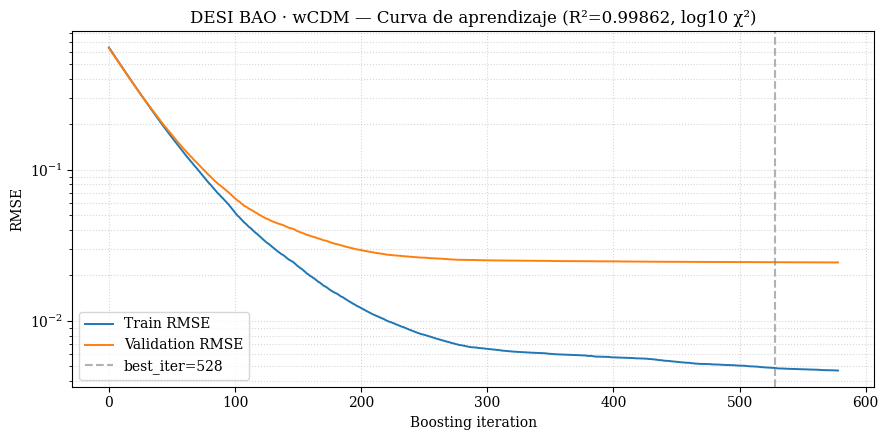

In [12]:
plot_learning_curve(
    info,
    title=f"DESI BAO · wCDM — Curva de aprendizaje (R²={info['r2']:.5f}, log10 χ²)",
    save_path=None,
    show=True,
)

--- $w$ vs $\Omega_m$  ({}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_1_Om_w.png


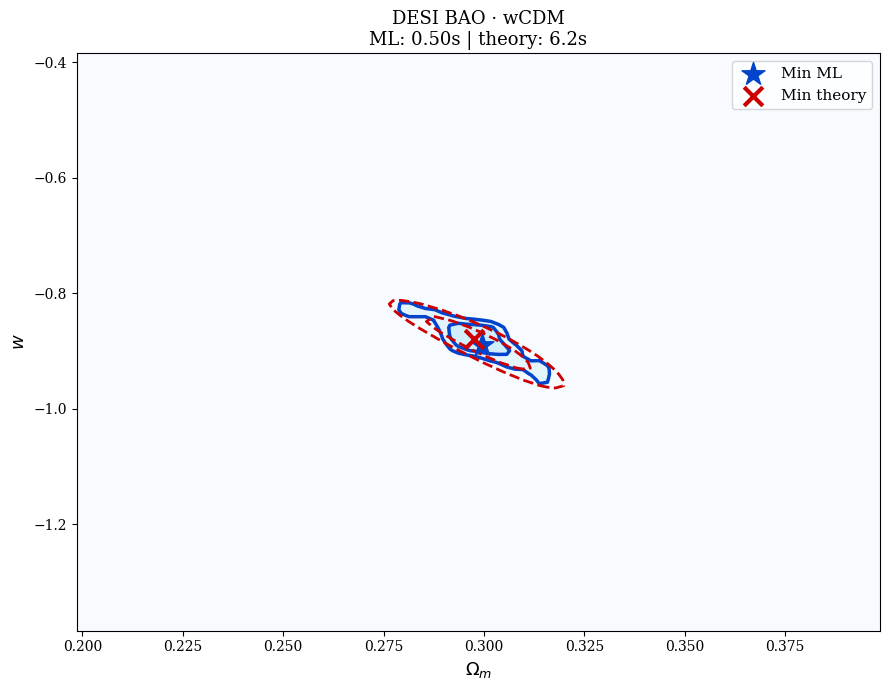

{'Z_ml': array([[6213.79   , 6116.8813 , 5950.67   , ...,  165.0224 ,  165.20732,
          167.4007 ],
        [6128.662  , 6024.045  , 5854.5796 , ...,  163.43274,  163.61153,
          165.76643],
        [6005.537  , 5894.41   , 5724.149  , ...,  160.02536,  160.3419 ,
          162.47281],
        ...,
        [1269.8085 , 1281.9977 , 1289.0146 , ..., 3209.7756 , 3251.3801 ,
         3273.2979 ],
        [1345.747  , 1357.8212 , 1363.8414 , ..., 3279.2598 , 3321.3083 ,
         3344.2568 ],
        [1438.7355 , 1450.7769 , 1456.6288 , ..., 3380.102  , 3423.3198 ,
         3447.2563 ]], shape=(100, 100), dtype=float32),
 'Z_th': array([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]], shape=(100, 100)),
 'time_ml': 0.4981656074523926,
 'time_th': 6.18063783645

In [13]:
common = dict(res=100, sigma=0.8, theory_threshold=30)

plot_contour_2d(
    model, features=FEATURES,
    x_param="Om", y_param="w",
    x_range=(REF['Om']-0.10, REF['Om']+0.10),
    y_range=(REF['w']-0.50, REF['w']+0.50),
    fixed={},
    theory_fn=chi2_fn,
    title=r"DESI BAO · wCDM",
    x_label=r"$\Omega_m$", y_label=r"$w$",
    save_path=None,
    show=True, **common,
    global_min_chi2=res_opt.fun,
)


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_1_shap_beeswarm.png


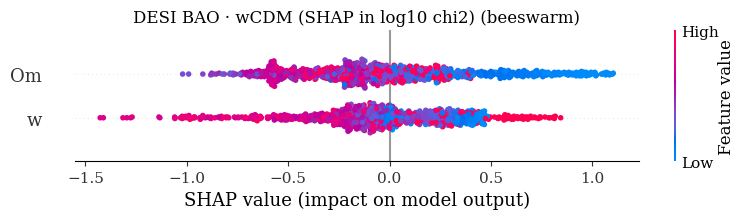

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_1_shap_bar.png


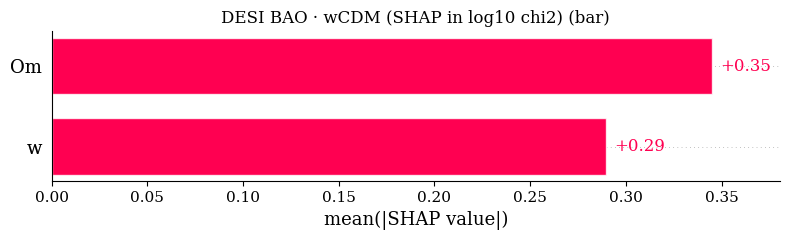

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_1_shap_waterfall.png


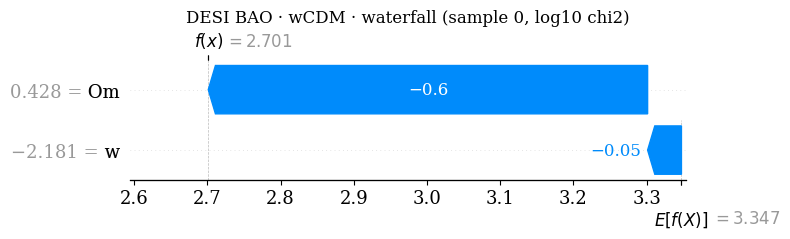

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_1_shap_Om.png


<Figure size 640x480 with 0 Axes>

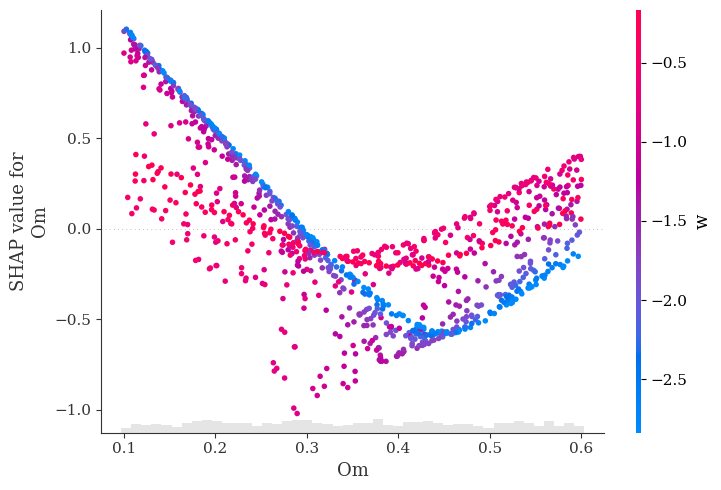

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_1_shap_w.png


<Figure size 640x480 with 0 Axes>

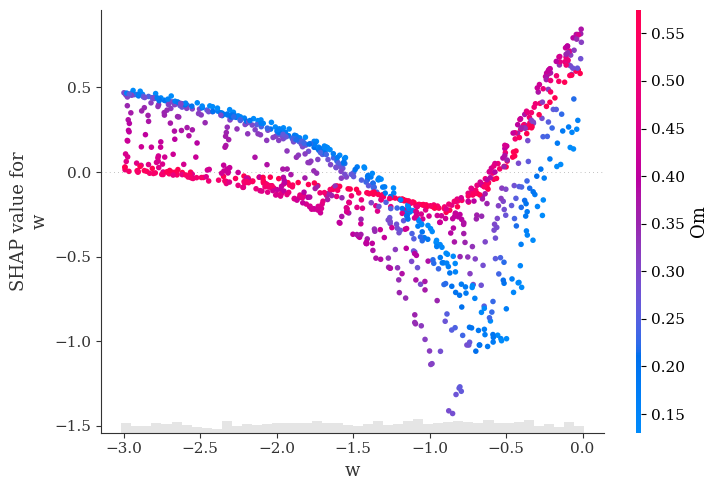

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_1_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_1_shap_w.png')]

In [14]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=None, prefix=SECTION,
    title="DESI BAO · wCDM (SHAP in log10 chi2)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=None,
    title="DESI BAO · wCDM · waterfall (sample 0, log10 chi2)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=None, prefix=SECTION,
    show=True,
)

## <a id="3-2"></a>3.2 wCDM with H0 free — 3D (Om, w, H0)

**Model:** `FlatwCDM` with wa=0 fixed. H0 free, rd fixed at Planck.
**Data:** DESI BAO DR2.
**Purpose:** study the H0–w degeneracy with rd fixed. Without external priors,
BAO alone cannot pin H0 when rd is fixed, so the H0 contours are wide.


In [15]:
SECTION = "3_2"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "w", "H0"]

def chi2_fn(Om, w, H0):
    return chi2_bao(bao_full, Om=Om, w0=w, wa=0.0, H0=H0, rd=PLANCK_RD)

# Auto-center: locate the best-fit with Minuit
import types
from iminuit import Minuit
print("Locating the global minimum with Minuit...")
_m = Minuit(chi2_fn, **dict(zip(FEATURES, [0.315, -1.0, 67.36])))
_m.limits = [(0.2, 0.45), (-1.6, -0.4), (55, 85)]
_m.migrad()
res_opt = types.SimpleNamespace(fun=_m.fval, x=[float(_m.values[k]) for k in FEATURES])
REF = dict(zip(FEATURES, res_opt.x))
print(f"Auto-detected best-fit:  Om={REF['Om']:.4f}  w={REF['w']:.4f}  H0={REF['H0']:.4f}")
print(f"chi2(best-fit) = {res_opt.fun:.2f}")


Locating the global minimum with Minuit...
Auto-detected best-fit:  Om=0.2977  w=-0.9119  H0=67.8159
chi2(best-fit) = 9.04


In [16]:
def builder():
    N = 10_000
    pares = [('Om','w'), ('Om','H0'), ('w','H0')]
    rangos = dict(Om=(0.05, 0.6), w=(-2.5, 0.0), H0=(50, 90))
    slices = [{**REF, a: rangos[a], b: rangos[b], '_n': N} for a, b in pares]
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        slices=slices, n_random=0,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min chi2 = {df['chi2'].min():.3f}")

Loading cached dataset: /home/aleja/PhysicsML/CosmoML/outputs/datasets/3_2_dataset.csv
min chi2 = 9.105


In [17]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=None,
    force_retrain=FORCE_RETRAIN,
)

  loading cached model: 3_2_model.ubj
  R2=0.99839 | best_iter=1095 | n_train=25,386 | n_val=4,480


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_2_learning_curve.png


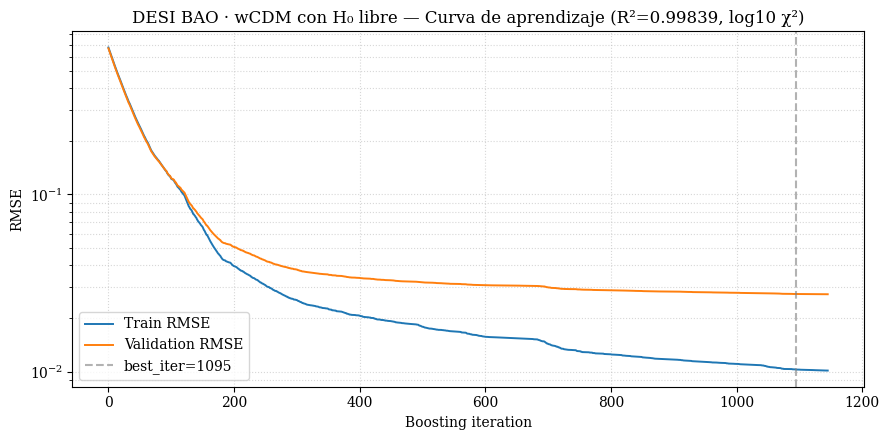

In [18]:
plot_learning_curve(
    info,
    title=f"DESI BAO · wCDM con H₀ libre — Curva de aprendizaje (R²={info['r2']:.5f}, log10 χ²)",
    save_path=None,
    show=True,
)

--- $w$ vs $\Omega_m$  ({'H0': 67.81587772788976}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_2_Om_w.png


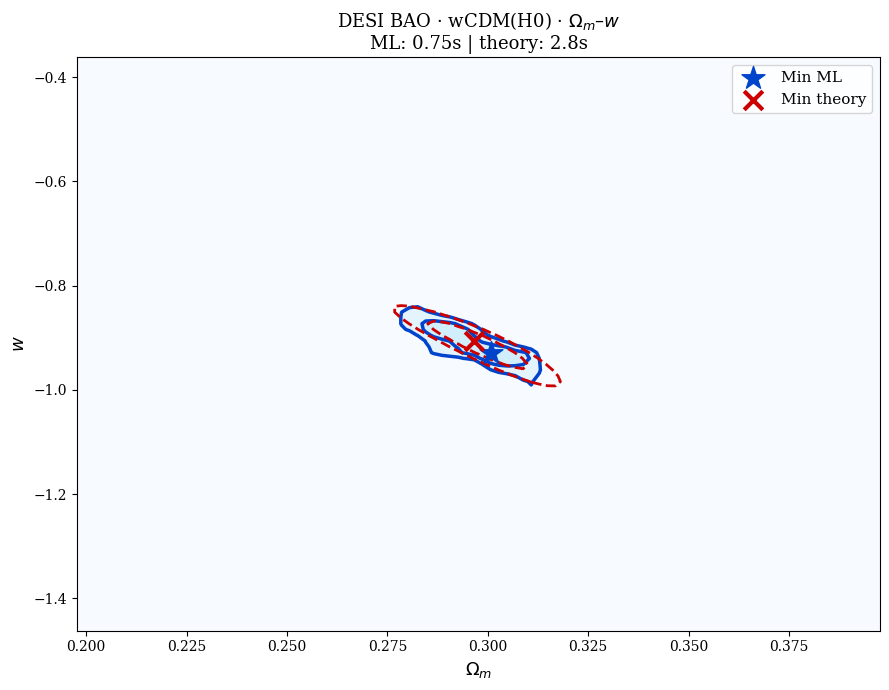

--- $H_0$ vs $\Omega_m$  ({'w': -0.9118867344323001}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_2_Om_H0.png


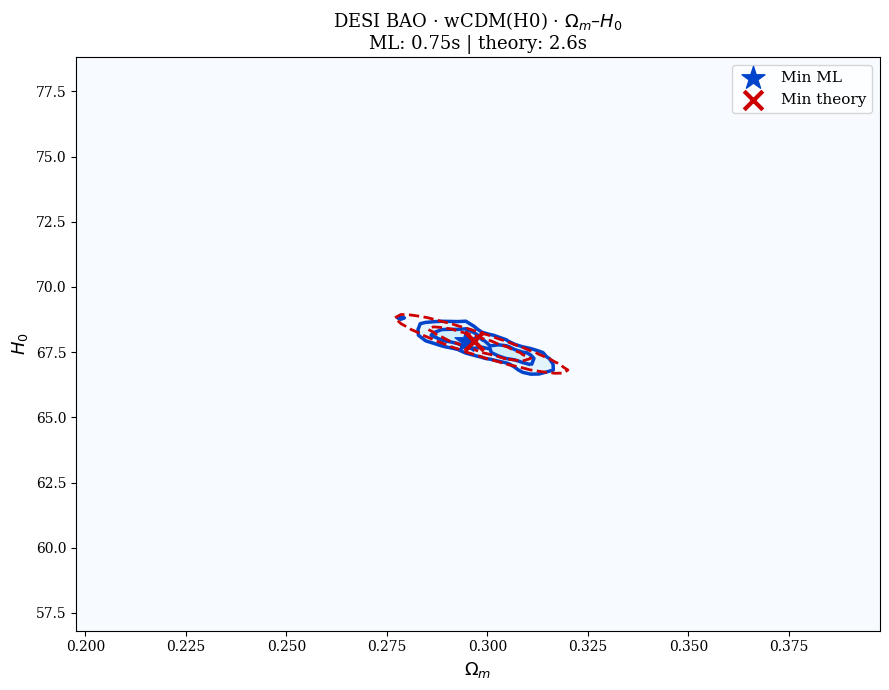

--- $H_0$ vs $w$  ({'Om': 0.29768770044063175}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_2_w_H0.png


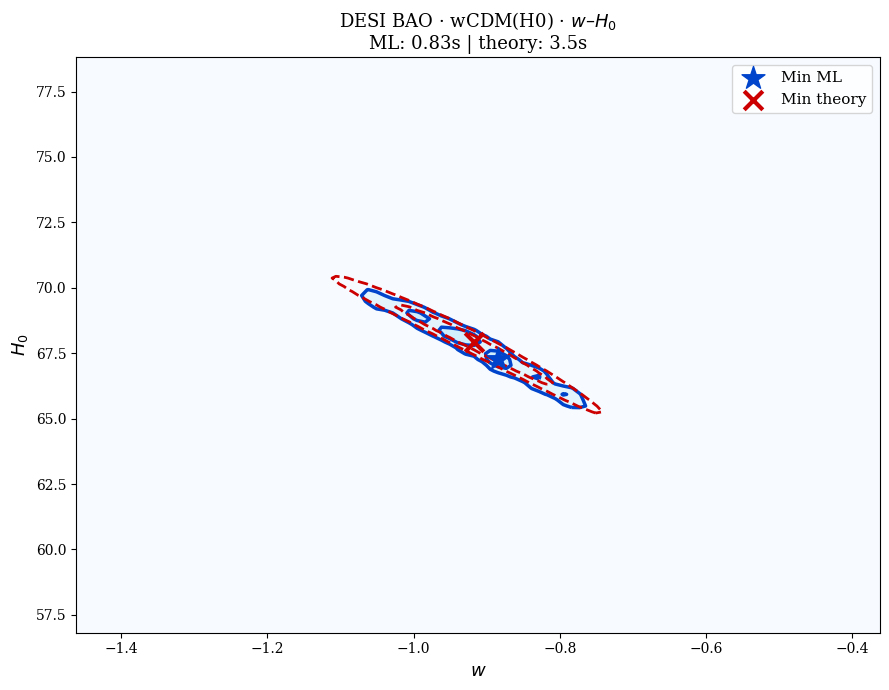

In [19]:
common = dict(res=100, sigma=0.8, theory_threshold=30)
RANGES = dict(
    Om=(REF['Om']-0.10, REF['Om']+0.10),
    w=(REF['w']-0.55, REF['w']+0.55),
    H0=(REF['H0']-11, REF['H0']+11),
)
LABELS = dict(Om=r"$\Omega_m$", w=r"$w$", H0=r"$H_0$")

for x, y in [('Om','w'), ('Om','H0'), ('w','H0')]:
    fixed = {k: REF[k] for k in FEATURES if k not in (x, y)}
    plot_contour_2d(
        model, features=FEATURES,
        x_param=x, y_param=y,
        x_range=RANGES[x], y_range=RANGES[y],
        fixed=fixed, theory_fn=chi2_fn,
        title=fr"DESI BAO · wCDM(H0) · {LABELS[x]}–{LABELS[y]}",
        x_label=LABELS[x], y_label=LABELS[y],
        save_path=None,
        show=True, **common,
        global_min_chi2=res_opt.fun,
    )


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_2_shap_beeswarm.png


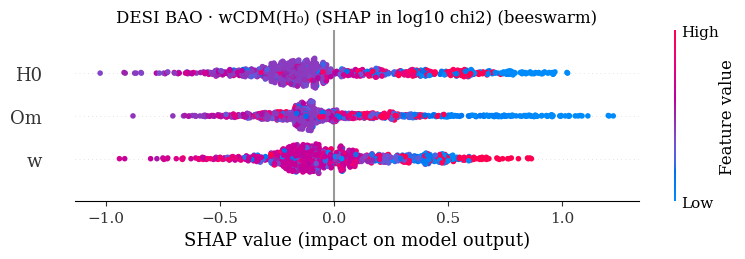

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_2_shap_bar.png


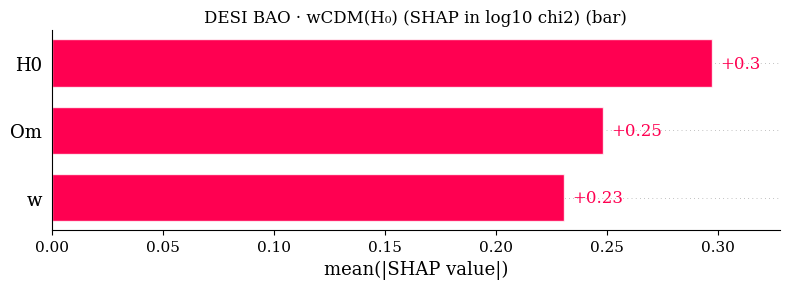

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_2_shap_waterfall.png


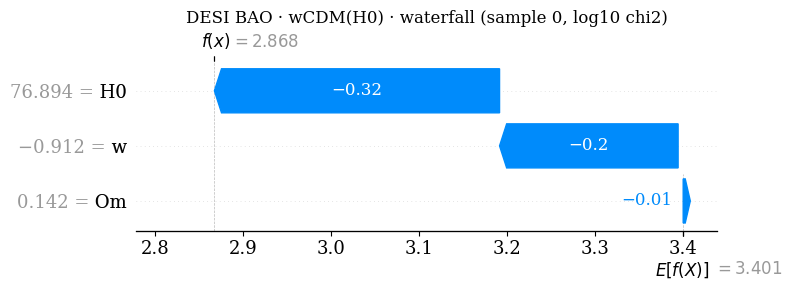

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_2_shap_Om.png


<Figure size 640x480 with 0 Axes>

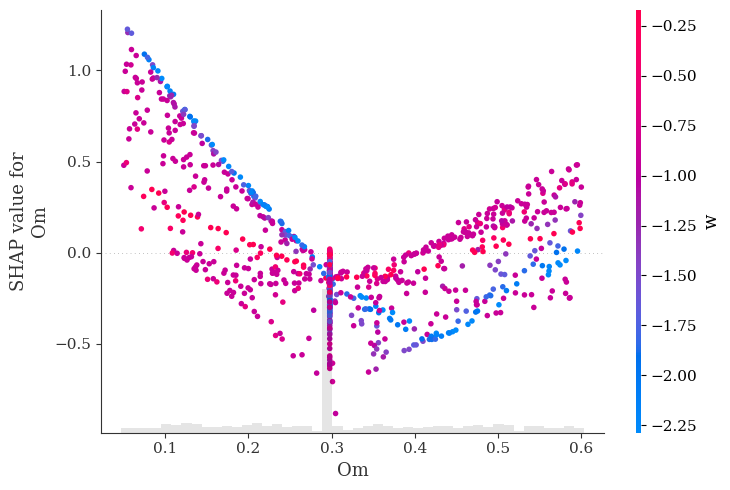

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_2_shap_w.png


<Figure size 640x480 with 0 Axes>

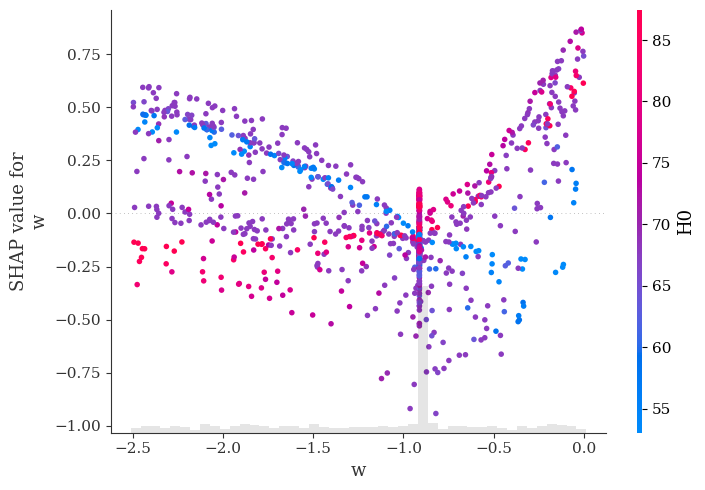

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_2_shap_H0.png


<Figure size 640x480 with 0 Axes>

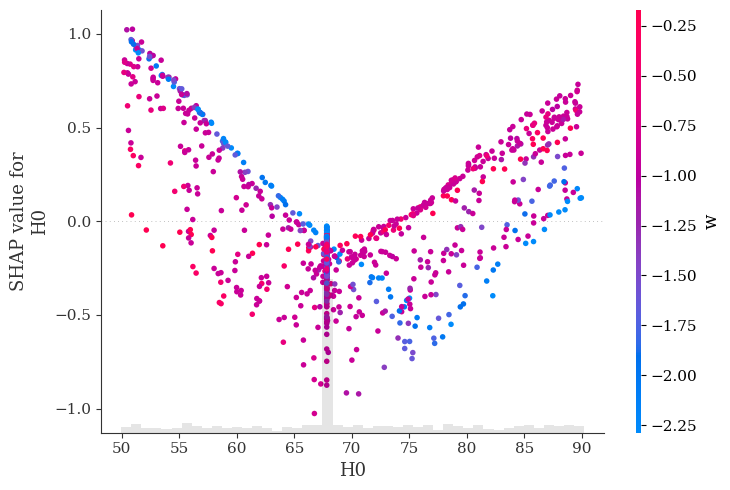

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_2_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_2_shap_w.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_2_shap_H0.png')]

In [20]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=None, prefix=SECTION,
    title="DESI BAO · wCDM(H₀) (SHAP in log10 chi2)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=None,
    title="DESI BAO · wCDM(H0) · waterfall (sample 0, log10 chi2)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=None, prefix=SECTION,
    show=True,
)

--- corner marginal: 512 chains × 5000 steps (burn-in 400, ndim=3) ---
  loading CPU booster copy...
  step   200/5000  |  5 it/s  |  ETA 909s  |  acc 0.19  |  diagonal
  step   400/5000  |  5 it/s  |  ETA 862s  |  acc 0.20  |  multivar
  step   600/5000  |  6 it/s  |  ETA ≤33s  |  acc 0.19  |  τ=39.4  ESS=2602/5000  |  multivar
  step   800/5000  |  6 it/s  |  ETA ≤44s  |  acc 0.18  |  τ=68.6  ESS=2985/5000  |  multivar
  step  1000/5000  |  6 it/s  |  ETA ≤5s  |  acc 0.17  |  τ=64.1  ESS=4793/5000  |  multivar
  step  1200/5000  |  6 it/s  |  ETA ≤0s  |  acc 0.17  |  τ=66.5  ESS=6162/5000  |  multivar
  done: 211.6s  |  6 it/s  |  acceptance 0.171  |  multivariate proposal
  flat chain: 410,112 samples (512 chains × 801 steps)  |  τ_max=66.5  |  ESS=6169
Removed no burn in
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_2_corner.png


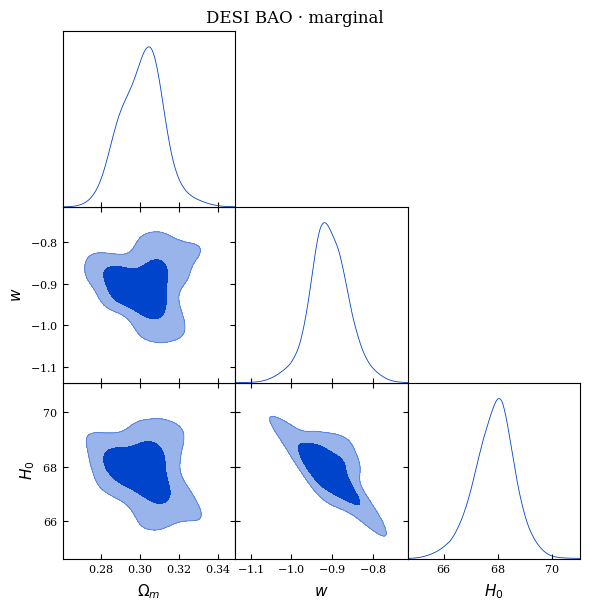

array([[ 0.28971836, -0.91762102, 67.55310822],
       [ 0.27741316, -0.89054304, 68.91281128],
       [ 0.27942908, -0.89518178, 68.37232971],
       ...,
       [ 0.31951421, -0.88543385, 66.58078003],
       [ 0.29585296, -0.9132548 , 69.39631653],
       [ 0.30892316, -0.96299714, 67.88047028]], shape=(410112, 3))

In [21]:
# --- Marginalised corner plot (MCMC posterior via XGBoost surrogate) ---
from cosmoml.ml import plot_corner_marginal
plot_corner_marginal(
    model, features=FEATURES, ranges=RANGES,
    labels=LABELS, ref=REF,
    markers={k: v for k, v in {'w0': -1.0, 'wa': 0.0}.items() if k in FEATURES},
    title="DESI BAO · marginal",
    save_path=None,
    show=True,
)

## <a id="3-3"></a>3.3 w0waCDM with full DESI — 3D

**Model:** `Flatw0waCDM` (CPL). H0 and rd fixed at Planck.
**Data:** DESI BAO DR2 (all redshifts, including the Lyman-alpha point at z=2.33).
**Purpose:** **main result of the paper.** With the full DESI dataset, LambdaCDM
(w0=-1, wa=0) is disfavored at more than 4 sigma — the 1-sigma and 2-sigma
contours are tight and exclude the cosmological constant model.


In [22]:
SECTION = "3_3"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "w0", "wa"]

def chi2_fn(Om, w0, wa):
    return chi2_bao(bao_full, Om=Om, w0=w0, wa=wa, H0=PLANCK_H0, rd=PLANCK_RD)

# Auto-center: locate the best-fit with Minuit
import types
from iminuit import Minuit
print("Locating the global minimum with Minuit...")
_m = Minuit(chi2_fn, **dict(zip(FEATURES, [0.315, -1.0, 0.0])))
_m.limits = [(0.2, 0.42), (-1.6, -0.5), (-2.0, 1.0)]
_m.migrad()
res_opt = types.SimpleNamespace(fun=_m.fval, x=[float(_m.values[k]) for k in FEATURES])
REF = dict(zip(FEATURES, res_opt.x))
print(f"Auto-detected best-fit:  Om={REF['Om']:.4f}  w0={REF['w0']:.4f}  wa={REF['wa']:.4f}")
print(f"chi2(best-fit) = {res_opt.fun:.2f}")


Locating the global minimum with Minuit...
Auto-detected best-fit:  Om=0.3135  w0=-0.8305  wa=-0.4873
chi2(best-fit) = 8.25


In [23]:
def builder():
    N = 12_000
    pares = [('Om', 'w0'), ('Om', 'wa'), ('w0', 'wa')]
    # Ranges centred on REF to ensure sufficient density near the chi2 minimum
    rangos = dict(
        Om=(REF['Om']-0.10, REF['Om']+0.10),
        w0=(REF['w0']-0.55, REF['w0']+0.55),
        wa=(REF['wa']-2.20, REF['wa']+2.20),
    )
    slices = [{**REF, a: rangos[a], b: rangos[b], '_n': N} for a, b in pares]
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        slices=slices,
        random_box=dict(Om=(0.1, 0.6), w0=(-3.0, 1.0), wa=(-4.0, 4.0)),
        n_random=25_000,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min chi2 = {df['chi2'].min():.3f}")

Loading cached dataset: /home/aleja/PhysicsML/CosmoML/outputs/datasets/3_3_dataset.csv
min chi2 = 8.275


In [24]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=None,
    force_retrain=FORCE_RETRAIN,
)

  loading cached model: 3_3_model.ubj
  R2=0.99835 | best_iter=1275 | n_train=51,839 | n_val=9,149


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_3_learning_curve.png


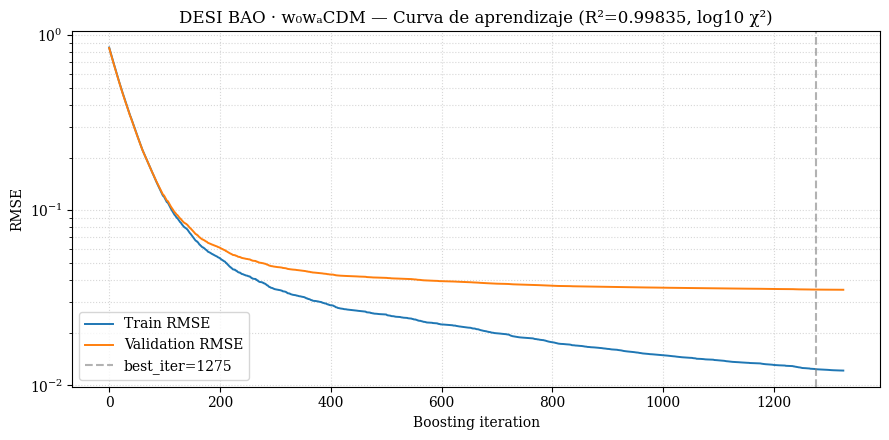

In [25]:
plot_learning_curve(
    info,
    title=f"DESI BAO · w₀wₐCDM — Curva de aprendizaje (R²={info['r2']:.5f}, log10 χ²)",
    save_path=None,
    show=True,
)

--- $w_a$ vs $w_0$  ({'Om': 0.3135155736766218}) ---


  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_3_w0_wa.png


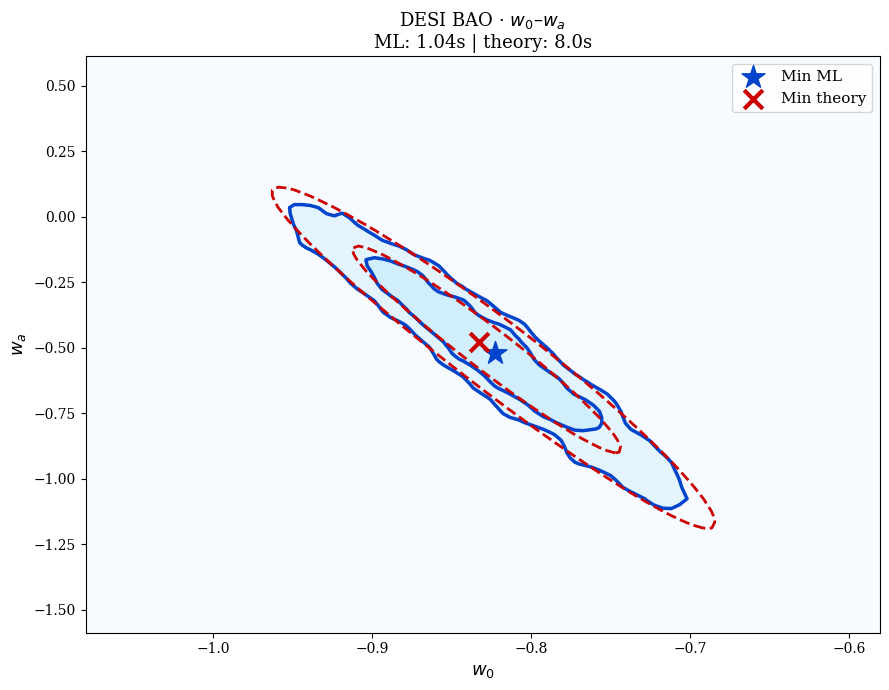

--- $w_0$ vs $\Omega_m$  ({'wa': -0.48728461011870816}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_3_Om_w0.png


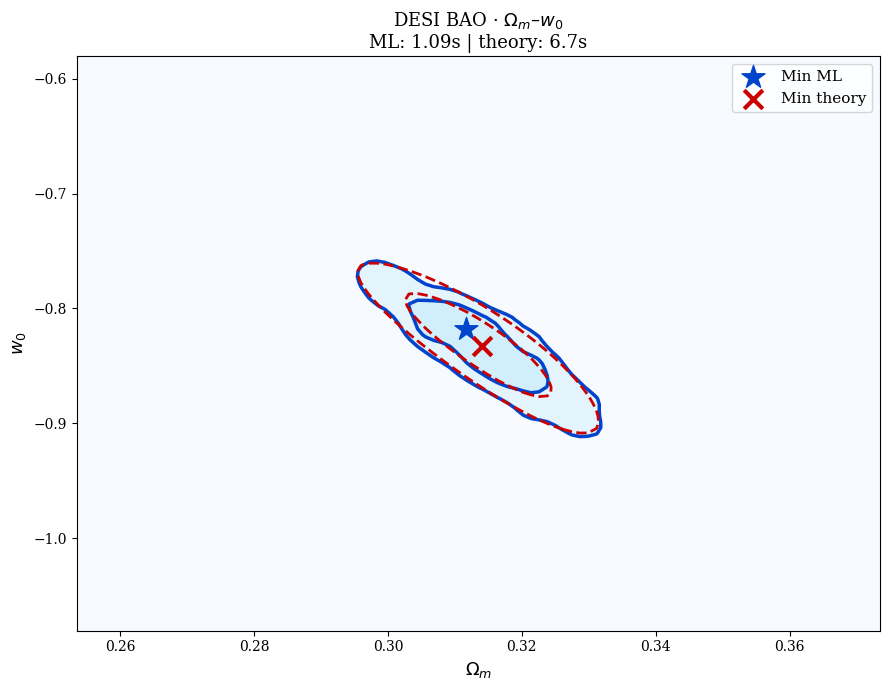

--- $w_a$ vs $\Omega_m$  ({'w0': -0.8304591239928218}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_3_Om_wa.png


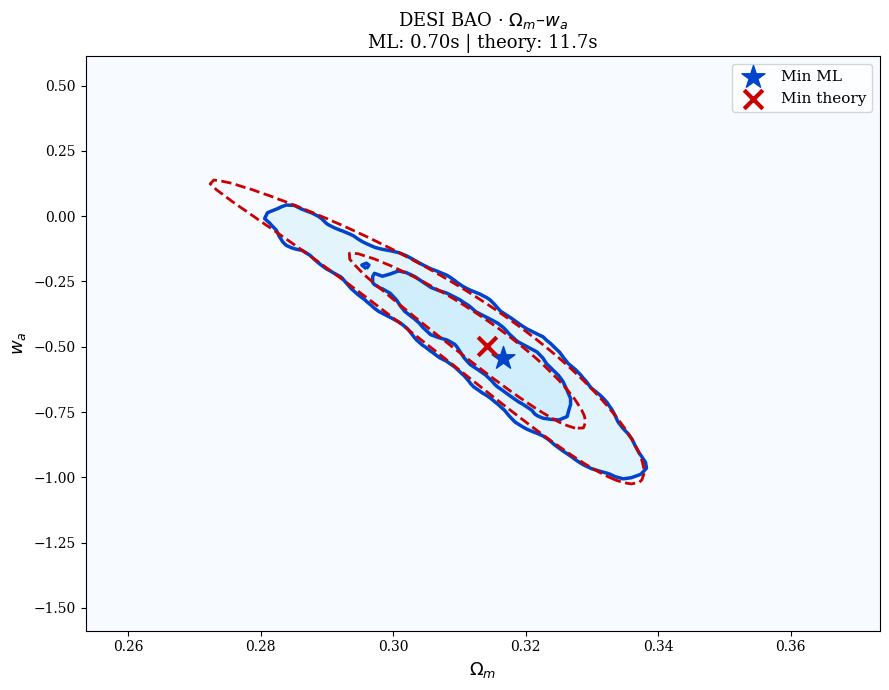

In [26]:
common = dict(res=100, sigma=1.0, theory_threshold=30)
RANGES = dict(
    Om=(REF["Om"]-0.06, REF["Om"]+0.06),
    w0=(REF["w0"]-0.25, REF["w0"]+0.25),
    wa=(REF["wa"]-1.1,  REF["wa"]+1.1),
)
LABELS = dict(Om=r"$\Omega_m$", w0=r"$w_0$", wa=r"$w_a$")

for x, y in [("w0","wa"), ("Om","w0"), ("Om","wa")]:
    fixed = {k: REF[k] for k in FEATURES if k not in (x, y)}
    plot_contour_2d(
        model, features=FEATURES,
        x_param=x, y_param=y,
        x_range=RANGES[x], y_range=RANGES[y],
        fixed=fixed, theory_fn=chi2_fn,
        title=fr"DESI BAO · {LABELS[x]}–{LABELS[y]}",
        x_label=LABELS[x], y_label=LABELS[y],
        save_path=None,
        show=True, **common,
        global_min_chi2=res_opt.fun,
    )

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_3_shap_beeswarm.png


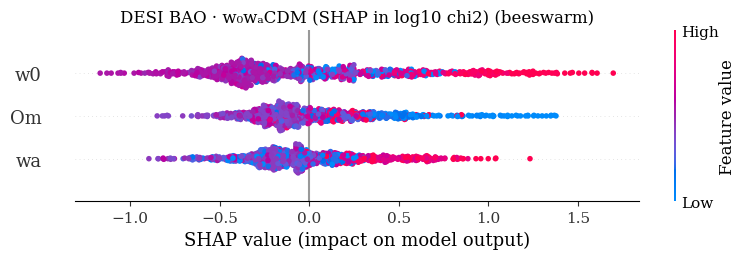

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_3_shap_bar.png


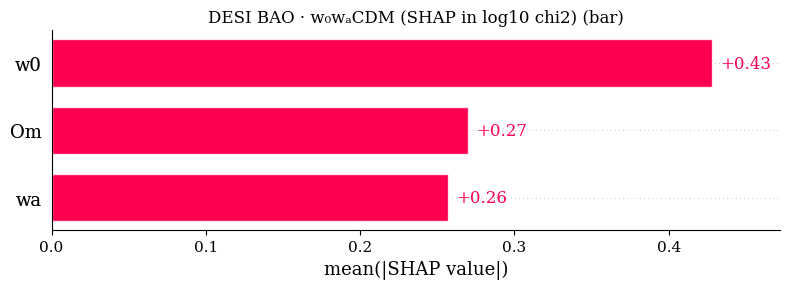

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_3_shap_waterfall.png


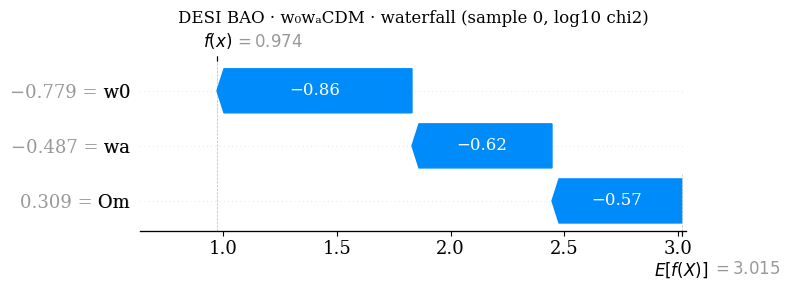

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_3_shap_Om.png


<Figure size 640x480 with 0 Axes>

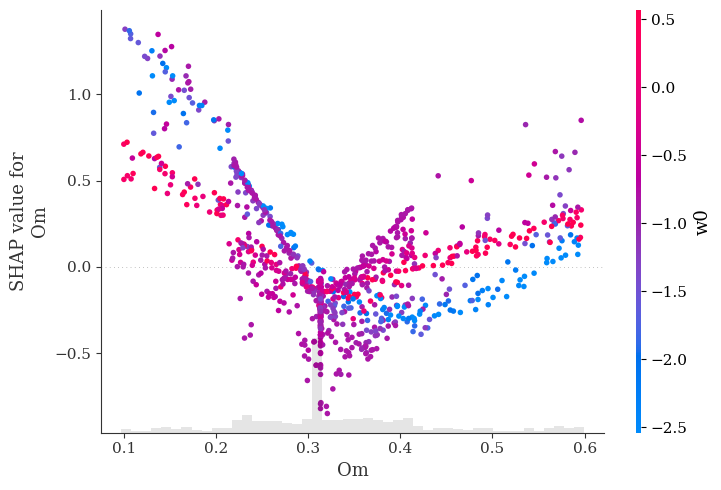

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_3_shap_w0.png


<Figure size 640x480 with 0 Axes>

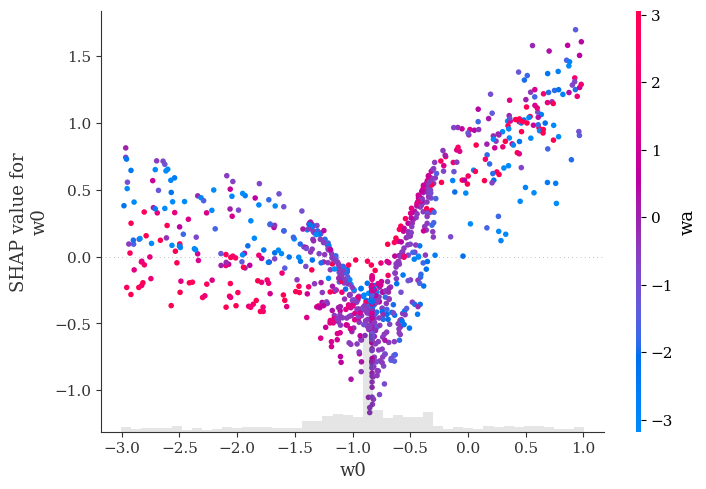

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_3_shap_wa.png


<Figure size 640x480 with 0 Axes>

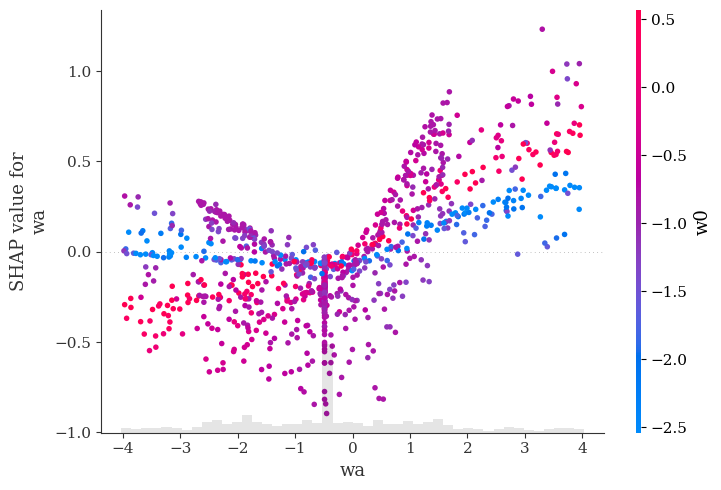

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_3_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_3_shap_w0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_3_shap_wa.png')]

In [27]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=None, prefix=SECTION,
    title="DESI BAO · w₀wₐCDM (SHAP in log10 chi2)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=None,
    title="DESI BAO · w₀wₐCDM · waterfall (sample 0, log10 chi2)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=None, prefix=SECTION,
    show=True,
)

--- corner marginal: 512 chains × 5000 steps (burn-in 400, ndim=3, n_trees=500) ---
  loading CPU booster copy...
  step   200/5000  |  6 it/s  |  ETA 774s  |  acc 0.38  |  diagonal
  step   400/5000  |  6 it/s  |  ETA 738s  |  acc 0.38  |  multivar
  step   600/5000  |  8 it/s  |  ETA ≤36s  |  acc 0.33  |  τ=51.1  ESS=2003/5000  |  multivar
  step   800/5000  |  11 it/s  |  ETA ≤0s  |  acc 0.30  |  τ=38.5  ESS=5314/5000  |  multivar
  done: 74.4s  |  11 it/s  |  acceptance 0.300  |  multivariate proposal
  flat chain: 205,312 samples (512 chains × 401 steps)  |  τ_max=38.5  |  ESS=5328
Removed no burn in
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_3_corner.png


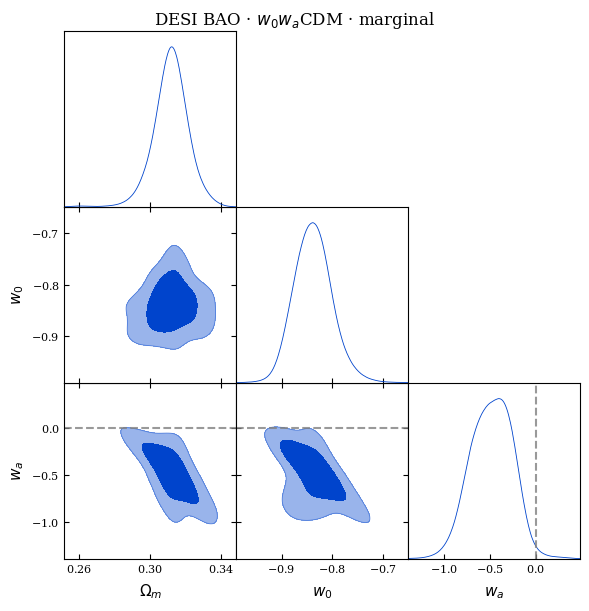

array([[ 0.2978358 , -0.8923713 , -0.3262057 ],
       [ 0.3037532 , -0.83458668, -0.26206055],
       [ 0.31173134, -0.79346442, -0.59830993],
       ...,
       [ 0.31397495, -0.81677014, -0.60837525],
       [ 0.32102585, -0.85644507, -0.60181826],
       [ 0.31457227, -0.84355277, -0.3855553 ]], shape=(205312, 3))

In [28]:
# --- Marginalised corner plot (MCMC posterior via XGBoost surrogate) ---
from cosmoml.ml import plot_corner_marginal

plot_corner_marginal(
    model, features=FEATURES, ranges=RANGES,
    labels=LABELS, ref=REF,
    markers={k: v for k, v in {'w0': -1.0, 'wa': 0.0}.items() if k in FEATURES},
    title=fr"DESI BAO · $w_0w_a$CDM · marginal",
    save_path=None,
    show=True,
    n_trees=500,
)


## <a id="3-4"></a>3.4 w0waCDM (z < 2, no Lyman-alpha) — 3D

**Model:** same as 3.3.
**Data:** DESI BAO DR2 with a **z < 2** cut (drops the Lyman-alpha point at z=2.33).
**Purpose:** the Lyman-alpha measurement is the strongest driver of the tension
with LambdaCDM. Removing it widens the contours noticeably.


In [29]:
SECTION = "3_4"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "w0", "wa"]

def chi2_fn(Om, w0, wa):
    return chi2_bao(bao_z2, Om=Om, w0=w0, wa=wa, H0=PLANCK_H0, rd=PLANCK_RD)

# Auto-center: locate the best-fit with Minuit
import types
from iminuit import Minuit
print("Locating the global minimum with Minuit...")
_m = Minuit(chi2_fn, **dict(zip(FEATURES, [0.315, -1.0, 0.0])))
_m.limits = [(0.2, 0.42), (-1.6, -0.5), (-2.0, 1.0)]
_m.migrad()
res_opt = types.SimpleNamespace(fun=_m.fval, x=[float(_m.values[k]) for k in FEATURES])
REF = dict(zip(FEATURES, res_opt.x))
print(f"Auto-detected best-fit:  Om={REF['Om']:.4f}  w0={REF['w0']:.4f}  wa={REF['wa']:.4f}")
print(f"chi2(best-fit) = {res_opt.fun:.2f}")


Locating the global minimum with Minuit...
Auto-detected best-fit:  Om=0.2097  w0=-0.7894  wa=0.4348
chi2(best-fit) = 6.97


In [30]:
def builder():
    N = 12_000
    pares = [('Om', 'w0'), ('Om', 'wa'), ('w0', 'wa')]
    # Ranges centred on REF to ensure sufficient density near the chi2 minimum
    rangos = dict(
        Om=(REF['Om']-0.10, REF['Om']+0.10),
        w0=(REF['w0']-0.55, REF['w0']+0.55),
        wa=(REF['wa']-2.20, REF['wa']+2.20),
    )
    slices = [{**REF, a: rangos[a], b: rangos[b], '_n': N} for a, b in pares]
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        slices=slices,
        random_box=dict(Om=(0.1, 0.6), w0=(-3.0, 1.0), wa=(-4.0, 4.0)),
        n_random=25_000,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min chi2 = {df['chi2'].min():.3f}")

Loading cached dataset: /home/aleja/PhysicsML/CosmoML/outputs/datasets/3_4_dataset.csv
min chi2 = 6.972


In [31]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=None,
    force_retrain=FORCE_RETRAIN,
)

  loading cached model: 3_4_model.ubj
  R2=0.99694 | best_iter=1061 | n_train=51,850 | n_val=9,150


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_4_learning_curve.png


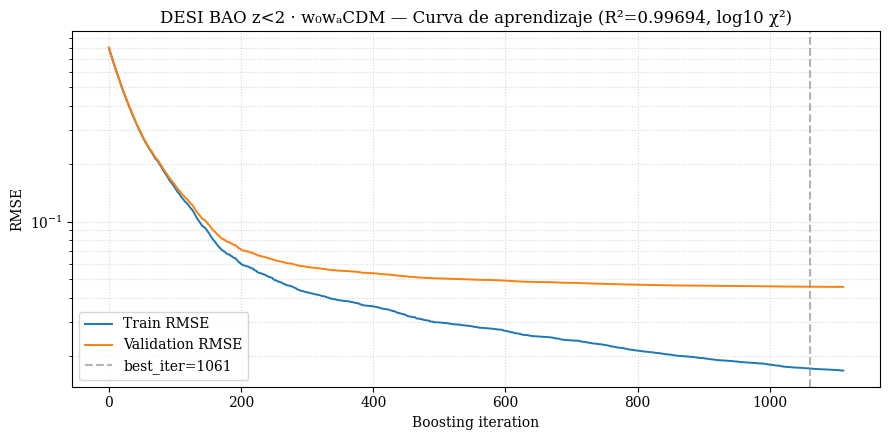

In [32]:
plot_learning_curve(
    info,
    title=f"DESI BAO z<2 · w₀wₐCDM — Curva de aprendizaje (R²={info['r2']:.5f}, log10 χ²)",
    save_path=None,
    show=True,
)

--- $w_a$ vs $w_0$  ({'Om': 0.20973932679461613}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_4_w0_wa.png


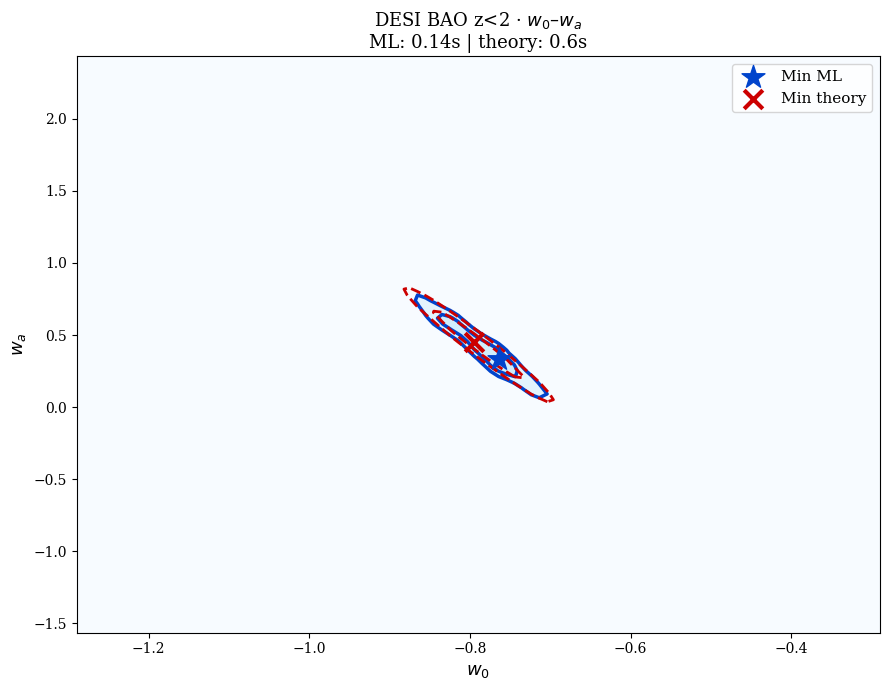

--- $w_0$ vs $\Omega_m$  ({'wa': 0.4347575560192783}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_4_Om_w0.png


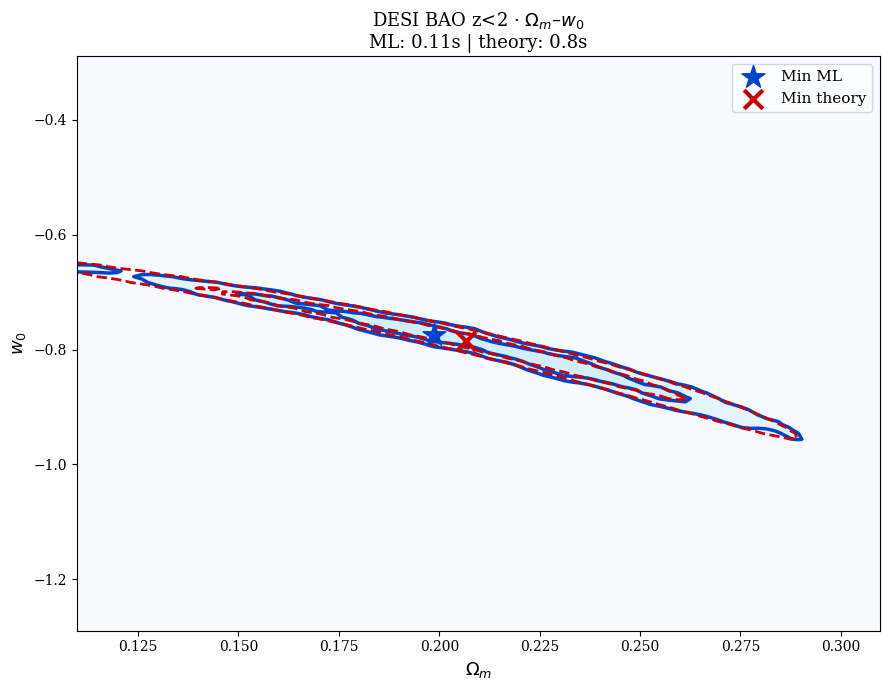

--- $w_a$ vs $\Omega_m$  ({'w0': -0.7894094527271597}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_4_Om_wa.png


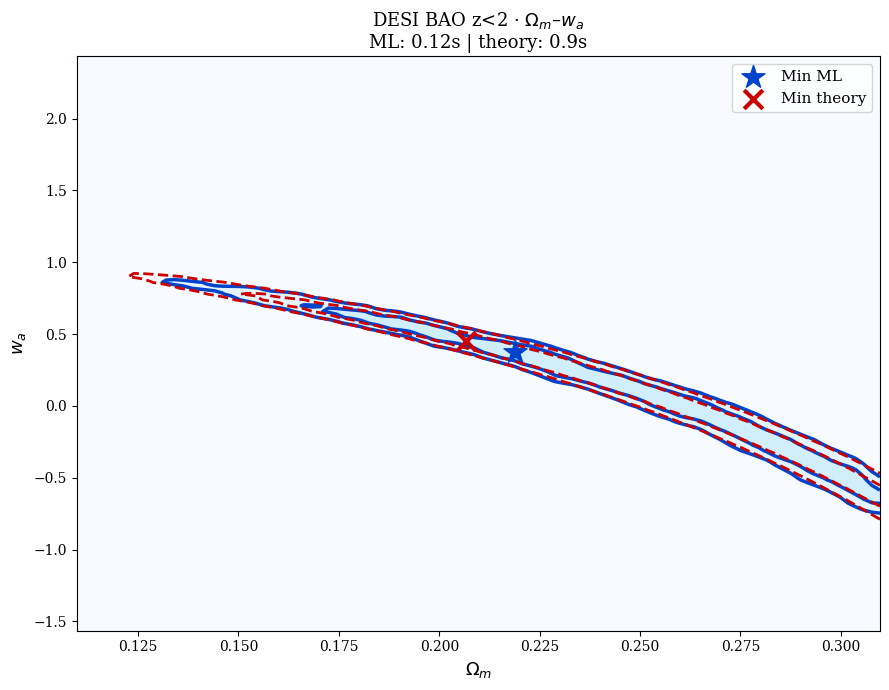

In [33]:
common = dict(res=100, sigma=1.0, theory_threshold=30)
RANGES = dict(
    Om=(REF["Om"]-0.10, REF["Om"]+0.10),
    w0=(REF["w0"]-0.50, REF["w0"]+0.50),
    wa=(REF["wa"]-2.0,  REF["wa"]+2.0),
)
LABELS = dict(Om=r"$\Omega_m$", w0=r"$w_0$", wa=r"$w_a$")

for x, y in [("w0","wa"), ("Om","w0"), ("Om","wa")]:
    fixed = {k: REF[k] for k in FEATURES if k not in (x, y)}
    plot_contour_2d(
        model, features=FEATURES,
        x_param=x, y_param=y,
        x_range=RANGES[x], y_range=RANGES[y],
        fixed=fixed, theory_fn=chi2_fn,
        title=fr"DESI BAO z<2 · {LABELS[x]}–{LABELS[y]}",
        x_label=LABELS[x], y_label=LABELS[y],
        save_path=None,
        show=True, **common,
        global_min_chi2=res_opt.fun,
    )

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_4_shap_beeswarm.png


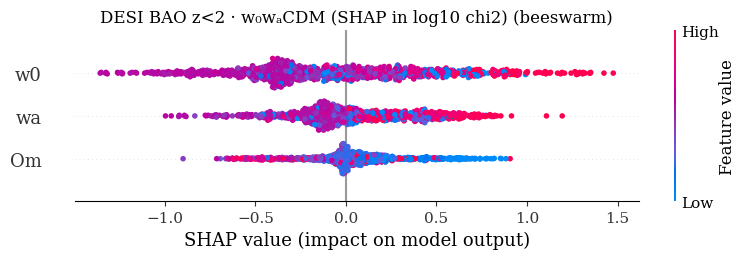

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_4_shap_bar.png


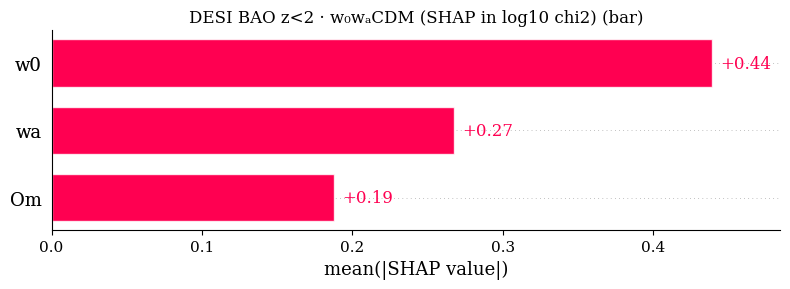

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_4_shap_waterfall.png


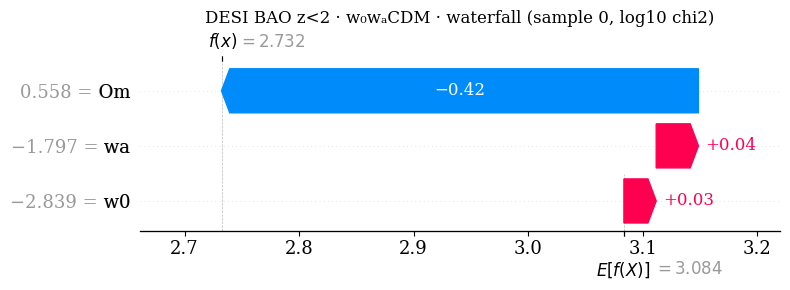

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_4_shap_Om.png


<Figure size 640x480 with 0 Axes>

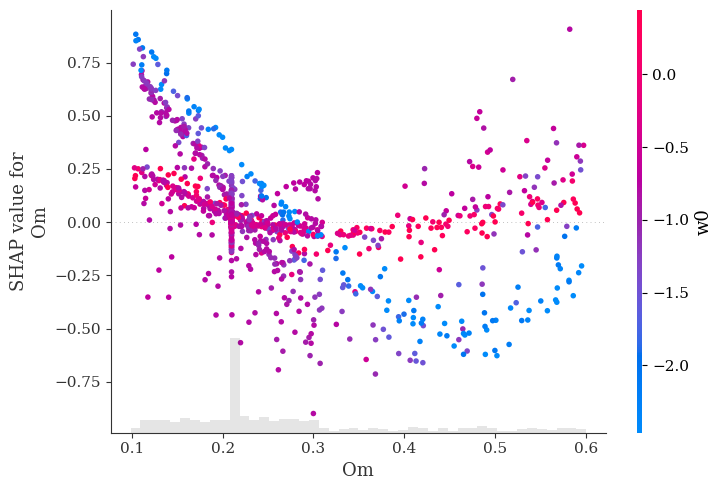

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_4_shap_w0.png


<Figure size 640x480 with 0 Axes>

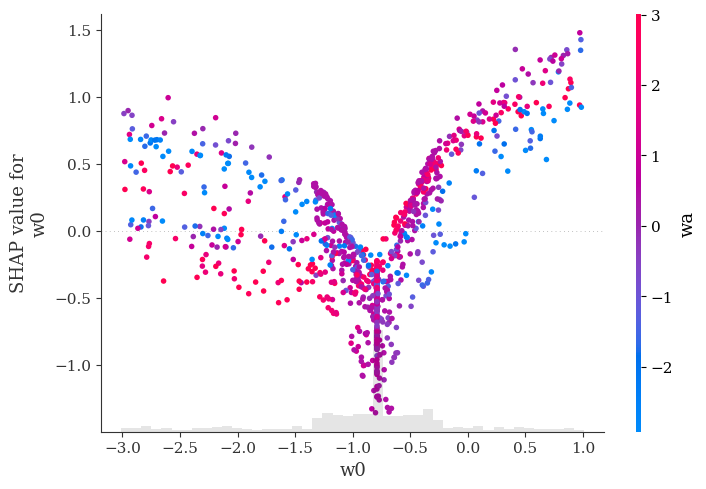

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_4_shap_wa.png


<Figure size 640x480 with 0 Axes>

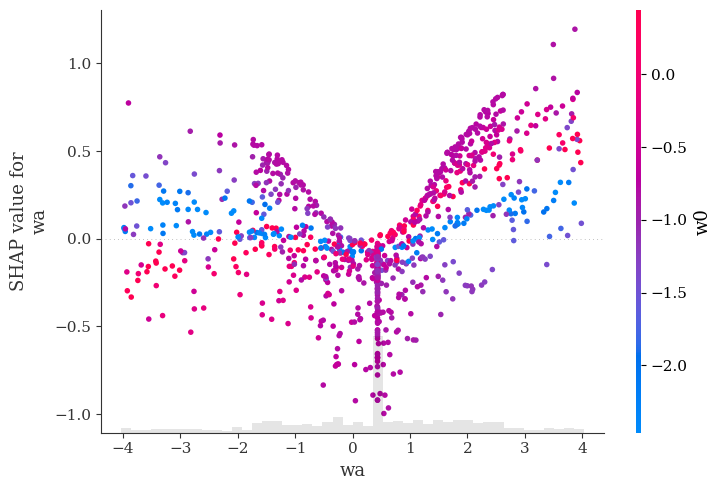

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_4_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_4_shap_w0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_4_shap_wa.png')]

In [34]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=None, prefix=SECTION,
    title="DESI BAO z<2 · w₀wₐCDM (SHAP in log10 chi2)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=None,
    title="DESI BAO z<2 · w₀wₐCDM · waterfall (sample 0, log10 chi2)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=None, prefix=SECTION,
    show=True,
)

--- corner marginal: 512 chains × 5000 steps (burn-in 400, ndim=3) ---
  loading CPU booster copy...
  step   200/5000  |  24 it/s  |  ETA 199s  |  acc 0.19  |  diagonal
  step   400/5000  |  29 it/s  |  ETA 157s  |  acc 0.20  |  multivar
  step   600/5000  |  35 it/s  |  ETA ≤9s  |  acc 0.18  |  τ=54.5  ESS=1880/5000  |  multivar
  step   800/5000  |  39 it/s  |  ETA ≤11s  |  acc 0.17  |  τ=85.8  ESS=2386/5000  |  multivar
  step  1000/5000  |  41 it/s  |  ETA ≤20s  |  acc 0.16  |  τ=145.1  ESS=2117/5000  |  multivar
  step  1200/5000  |  43 it/s  |  ETA ≤13s  |  acc 0.16  |  τ=138.5  ESS=2958/5000  |  multivar
  step  1400/5000  |  43 it/s  |  ETA ≤10s  |  acc 0.16  |  τ=147.6  ESS=3468/5000  |  multivar
  step  1600/5000  |  36 it/s  |  ETA ≤12s  |  acc 0.15  |  τ=165.2  ESS=3719/5000  |  multivar
  step  1800/5000  |  33 it/s  |  ETA ≤33s  |  acc 0.15  |  τ=254.8  ESS=2814/5000  |  multivar
  step  2000/5000  |  31 it/s  |  ETA ≤57s  |  acc 0.15  |  τ=342.9  ESS=2389/5000  |  multi

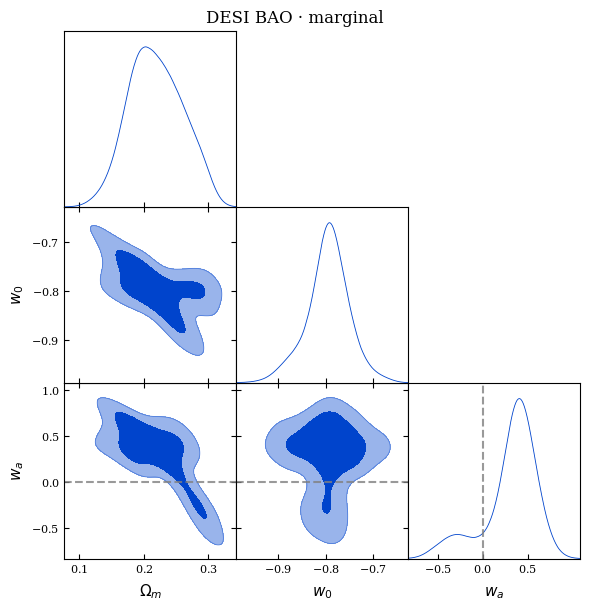

array([[ 0.12432255, -0.67142147,  0.45065549],
       [ 0.28813839, -0.78534502, -0.21921588],
       [ 0.18571183, -0.75003588,  0.26457804],
       ...,
       [ 0.20020382, -0.78621167,  0.48511612],
       [ 0.27285904, -0.78914183, -0.2054349 ],
       [ 0.28418094, -0.82013655, -0.2171987 ]], shape=(1331712, 3))

In [35]:
# --- Marginalised corner plot (MCMC posterior via XGBoost surrogate) ---
from cosmoml.ml import plot_corner_marginal
plot_corner_marginal(
    model, features=FEATURES, ranges=RANGES,
    labels=LABELS, ref=REF,
    markers={k: v for k, v in {'w0': -1.0, 'wa': 0.0}.items() if k in FEATURES},
    title="DESI BAO · marginal",
    save_path=None,
    show=True,
)

## <a id="3-5"></a>3.5 w0waCDM + rd=Planck (H0 free) — 4D

**Model:** `Flatw0waCDM` 4D (Om, w0, wa, H0). rd fixed at Planck (147.09 Mpc).
**Data:** DESI BAO DR2.
**Purpose:** explore how H0 degenerates with the other parameters when rd is
set by early-universe physics. Without external priors, BAO cannot fix H0 by
itself when rd is fixed, so H0 contours are wide.


In [36]:
SECTION = "3_5"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "w0", "wa", "H0"]

def chi2_fn(Om, w0, wa, H0):
    return chi2_bao(bao_full, Om=Om, w0=w0, wa=wa, H0=H0, rd=PLANCK_RD)

# Auto-center: locate the best-fit with Minuit
import types
from iminuit import Minuit
print("Locating the global minimum with Minuit...")
_m = Minuit(chi2_fn, **dict(zip(FEATURES, [0.315, -1.0, 0.0, 67.36])))
_m.limits = [(0.2, 0.42), (-1.6, -0.5), (-2.0, 1.0), (55, 85)]
_m.migrad()
res_opt = types.SimpleNamespace(fun=_m.fval, x=[float(_m.values[k]) for k in FEATURES])
REF = dict(zip(FEATURES, res_opt.x))
print(f"Auto-detected best-fit:  Om={REF['Om']:.4f}  w0={REF['w0']:.4f}  wa={REF['wa']:.4f}  H0={REF['H0']:.4f}")
print(f"chi2(best-fit) = {res_opt.fun:.2f}")


Locating the global minimum with Minuit...
Auto-detected best-fit:  Om=0.3526  w0=-0.5000  wa=-1.6149  H0=64.4179
chi2(best-fit) = 6.21


In [37]:
def builder():
    N = 7_000
    pares = [('Om','w0'), ('Om','wa'), ('Om','H0'),
             ('w0','wa'), ('w0','H0'), ('wa','H0')]
    rangos = dict(Om=(0.1, 0.6), w0=(-2.5, 0.5), wa=(-4.0, 3.0), H0=(55, 85))
    slices = [{**REF, a: rangos[a], b: rangos[b], '_n': N} for a, b in pares]
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        slices=slices, n_random=0,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min chi2 = {df['chi2'].min():.3f}")

Loading cached dataset: /home/aleja/PhysicsML/CosmoML/outputs/datasets/3_5_dataset.csv
min chi2 = 6.278


In [38]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=None,
    force_retrain=FORCE_RETRAIN,
)

  loading cached model: 3_5_model.ubj
  R2=0.99765 | best_iter=1028 | n_train=35,693 | n_val=6,299


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_learning_curve.png


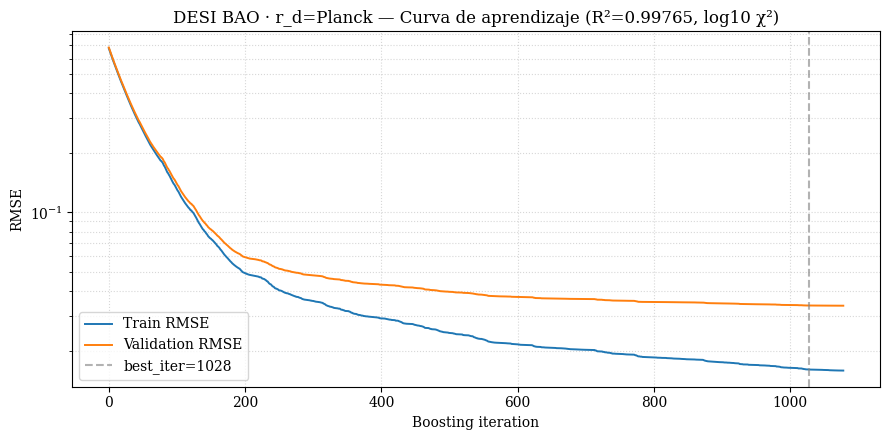

In [39]:
plot_learning_curve(
    info,
    title=f"DESI BAO · r_d=Planck — Curva de aprendizaje (R²={info['r2']:.5f}, log10 χ²)",
    save_path=None,
    show=True,
)

--- $w_0$ vs $\Omega_m$  ({'wa': -1.61492876725888, 'H0': 64.41791951072922}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_Om_w0.png


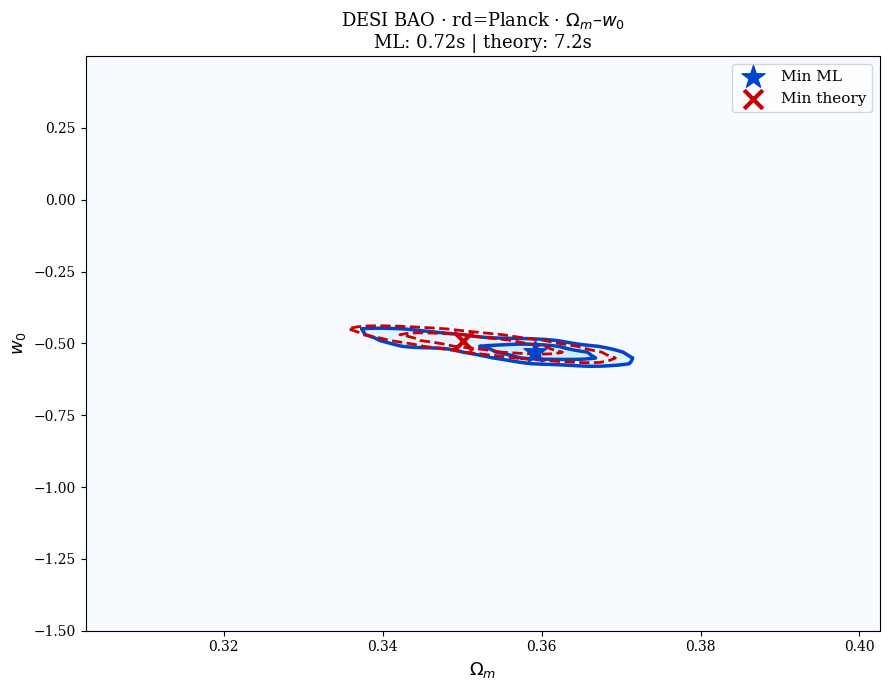

--- $w_a$ vs $\Omega_m$  ({'w0': -0.5000031459728641, 'H0': 64.41791951072922}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_Om_wa.png


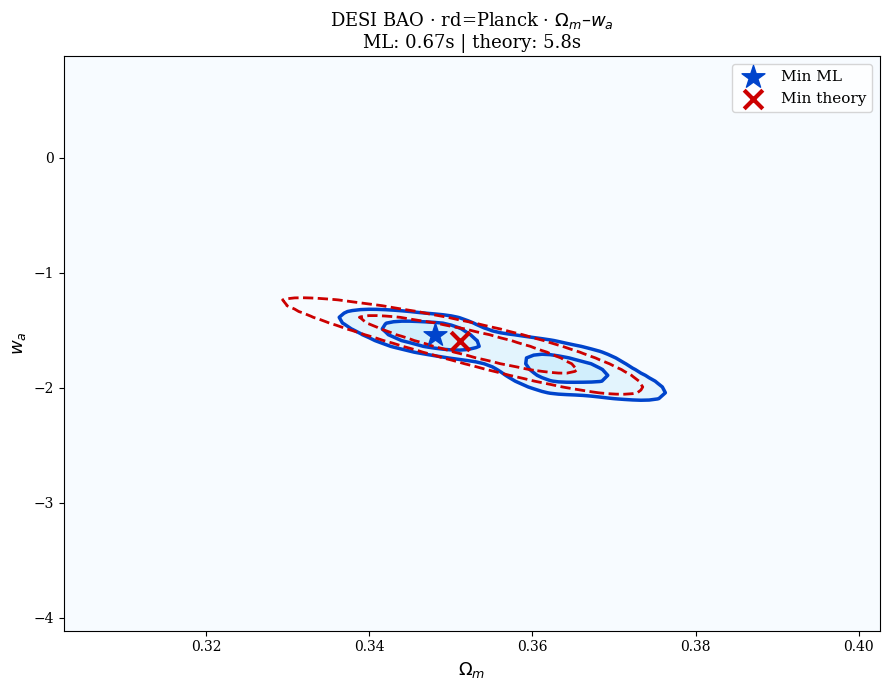

--- $H_0$ vs $\Omega_m$  ({'w0': -0.5000031459728641, 'wa': -1.61492876725888}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_Om_H0.png


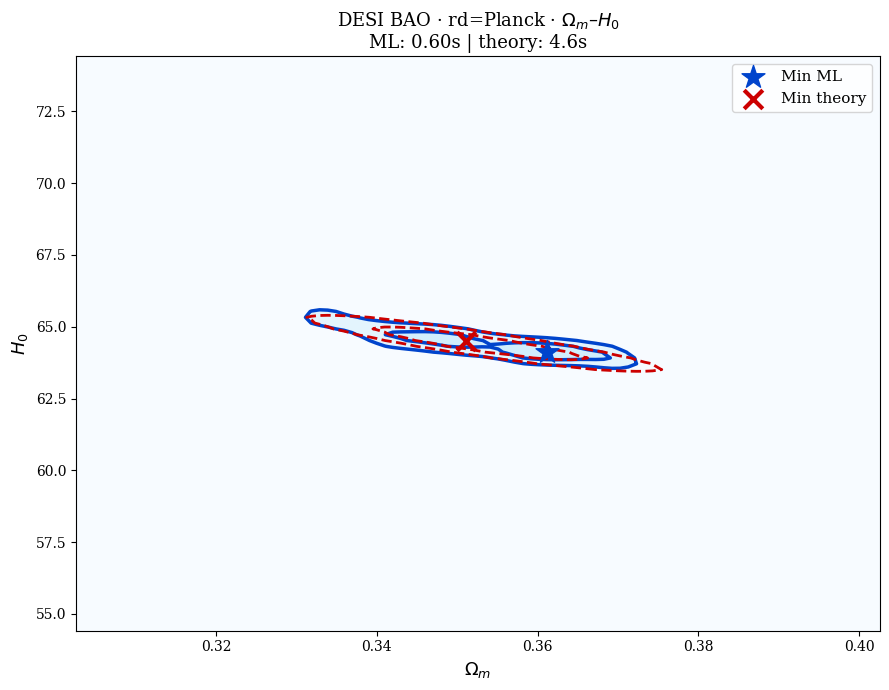

--- $w_a$ vs $w_0$  ({'Om': 0.35258697317758747, 'H0': 64.41791951072922}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_w0_wa.png


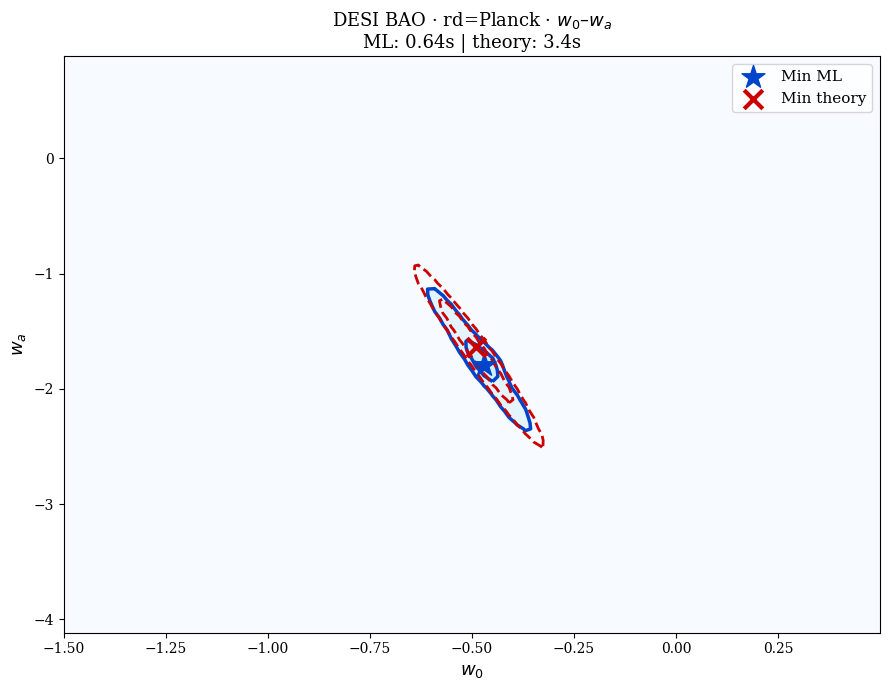

--- $H_0$ vs $w_0$  ({'Om': 0.35258697317758747, 'wa': -1.61492876725888}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_w0_H0.png


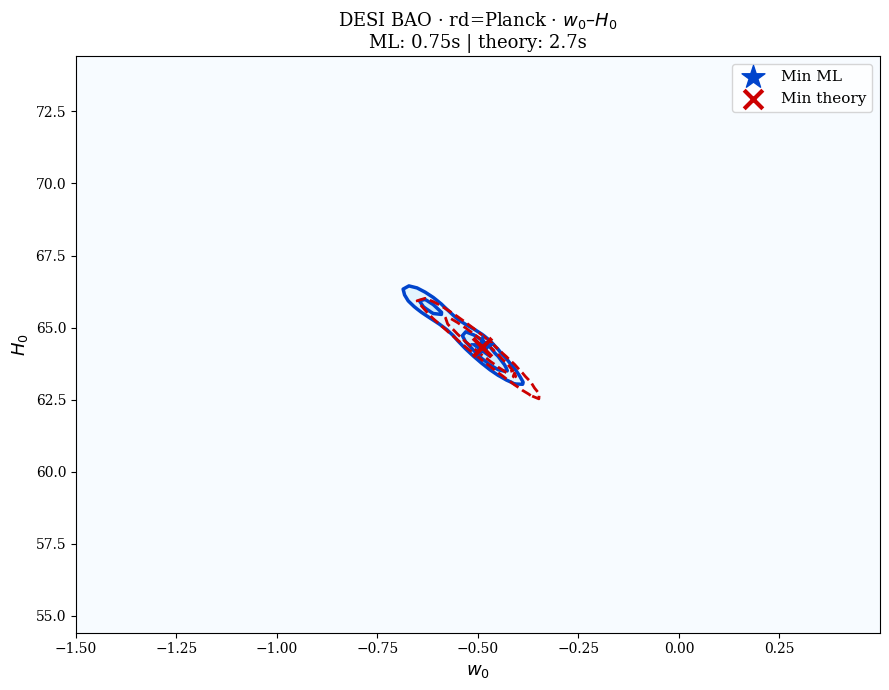

--- $H_0$ vs $w_a$  ({'Om': 0.35258697317758747, 'w0': -0.5000031459728641}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_wa_H0.png


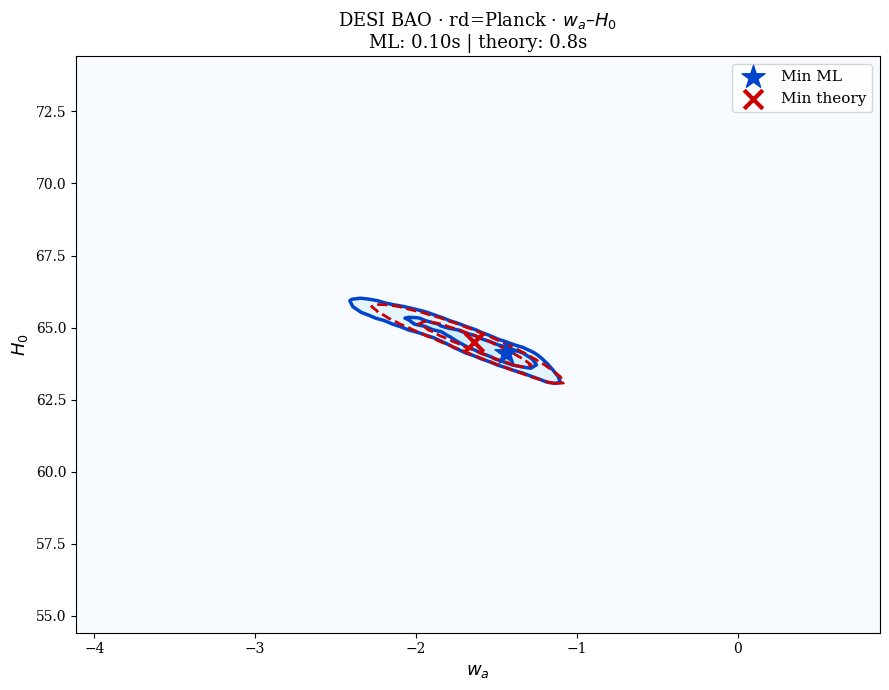

In [40]:
common = dict(res=100, sigma=2.0, theory_threshold=50)
RANGES = dict(
    Om=(REF['Om'] - 0.05, REF['Om'] + 0.05),
    w0=(REF['w0'] - 1.0,  REF['w0'] + 1.0),
    wa=(REF['wa'] - 2.5,  REF['wa'] + 2.5),
    H0=(REF['H0'] - 10,   REF['H0'] + 10),
)
LABELS = dict(Om=r"$\Omega_m$", w0=r"$w_0$", wa=r"$w_a$", H0=r"$H_0$")

for x, y in [('Om','w0'), ('Om','wa'), ('Om','H0'),
             ('w0','wa'), ('w0','H0'), ('wa','H0')]:
    fixed = {k: REF[k] for k in FEATURES if k not in (x, y)}
    plot_contour_2d(
        model, features=FEATURES,
        x_param=x, y_param=y,
        x_range=RANGES[x], y_range=RANGES[y],
        fixed=fixed, theory_fn=chi2_fn,
        title=fr"DESI BAO · rd=Planck · {LABELS[x]}–{LABELS[y]}",
        x_label=LABELS[x], y_label=LABELS[y],
        save_path=None,
        show=True, **common,
        global_min_chi2=res_opt.fun,
    )


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_shap_beeswarm.png


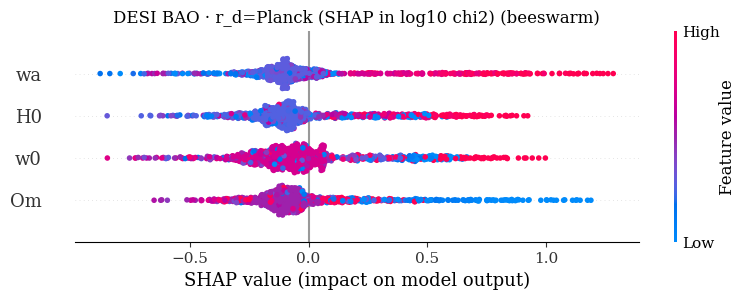

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_shap_bar.png


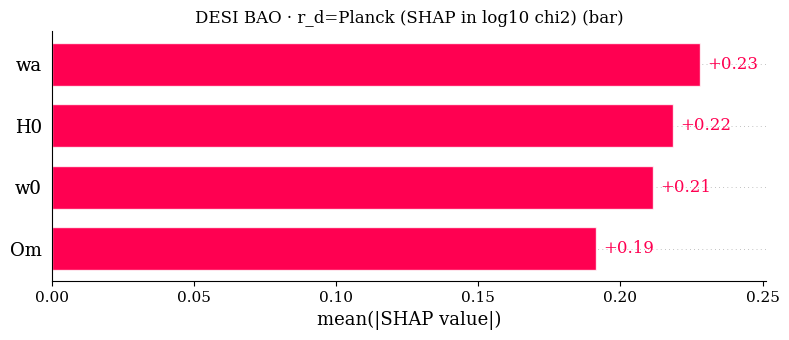

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_shap_waterfall.png


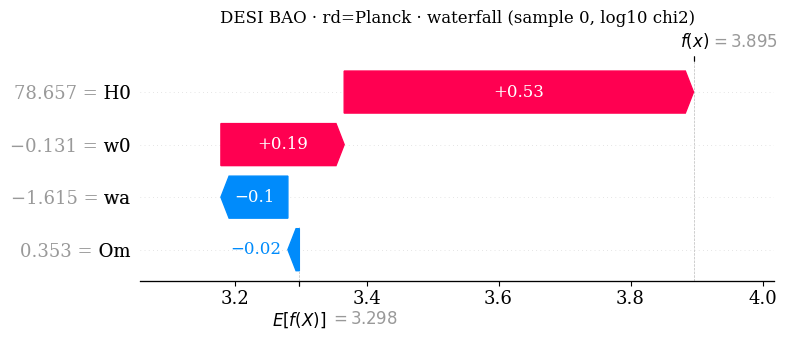

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_shap_Om.png


<Figure size 640x480 with 0 Axes>

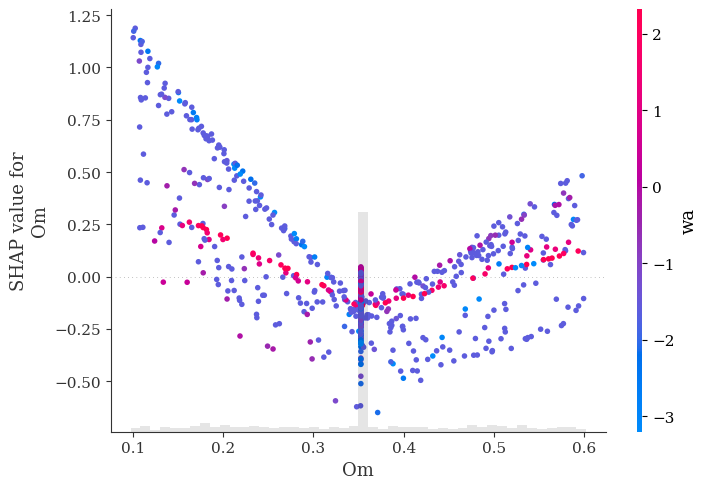

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_shap_w0.png


<Figure size 640x480 with 0 Axes>

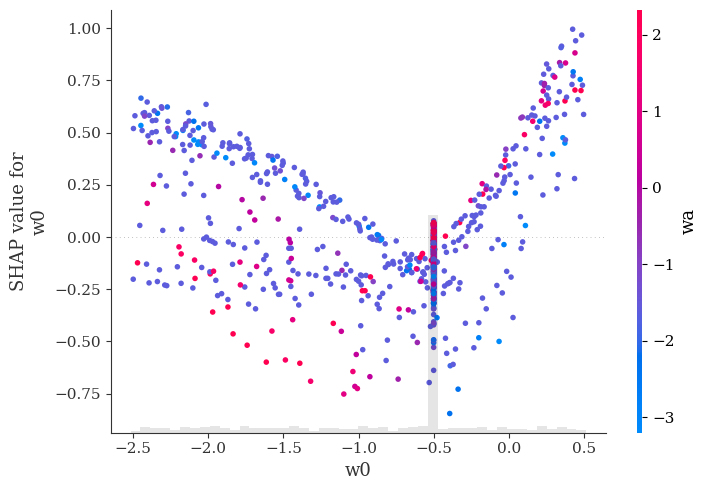

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_shap_wa.png


<Figure size 640x480 with 0 Axes>

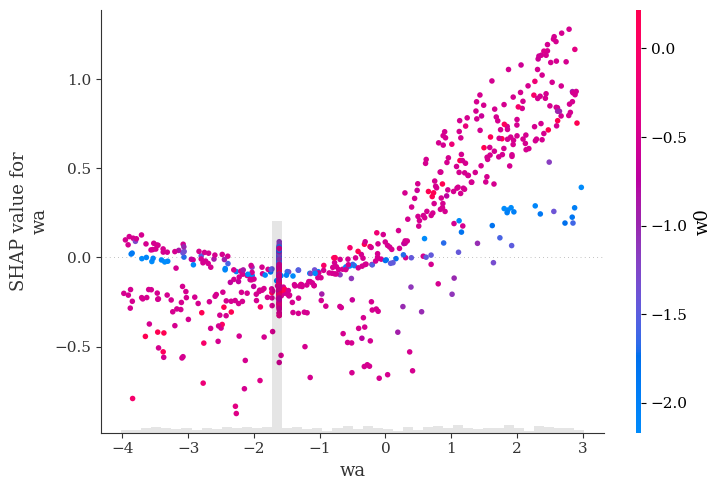

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_shap_H0.png


<Figure size 640x480 with 0 Axes>

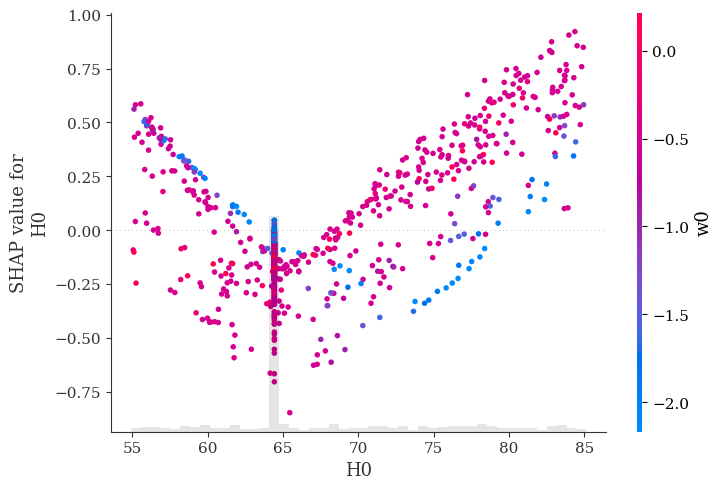

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_shap_w0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_shap_wa.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_shap_H0.png')]

In [41]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=None, prefix=SECTION,
    title="DESI BAO · r_d=Planck (SHAP in log10 chi2)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=None,
    title="DESI BAO · rd=Planck · waterfall (sample 0, log10 chi2)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=None, prefix=SECTION,
    show=True,
)

--- corner marginal: 512 chains × 5000 steps (burn-in 400, ndim=4) ---
  loading CPU booster copy...
  step   200/5000  |  28 it/s  |  ETA 169s  |  acc 0.17  |  diagonal
  step   400/5000  |  35 it/s  |  ETA 131s  |  acc 0.17  |  multivar
  step   600/5000  |  33 it/s  |  ETA ≤9s  |  acc 0.16  |  τ=50.2  ESS=2039/5000  |  multivar
  step   800/5000  |  37 it/s  |  ETA ≤13s  |  acc 0.15  |  τ=89.9  ESS=2278/5000  |  multivar
  step  1000/5000  |  40 it/s  |  ETA ≤18s  |  acc 0.15  |  τ=134.7  ESS=2281/5000  |  multivar
  step  1200/5000  |  43 it/s  |  ETA ≤9s  |  acc 0.15  |  τ=119.9  ESS=3415/5000  |  multivar
  step  1400/5000  |  45 it/s  |  ETA ≤3s  |  acc 0.14  |  τ=114.3  ESS=4479/5000  |  multivar
  step  1600/5000  |  48 it/s  |  ETA ≤0s  |  acc 0.14  |  τ=114.9  ESS=5345/5000  |  multivar
  done: 33.7s  |  47 it/s  |  acceptance 0.143  |  multivariate proposal
  flat chain: 614,912 samples (512 chains × 1201 steps)  |  τ_max=114.9  |  ESS=5349
Removed no burn in
  saved: /home

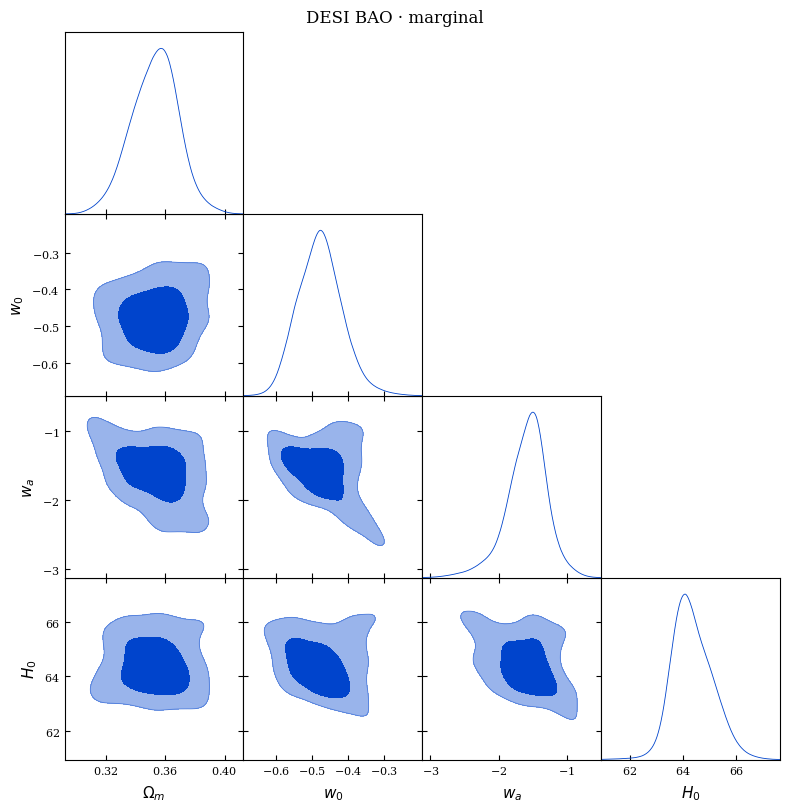

array([[ 0.35244685, -0.42561117, -1.48451269, 63.90855789],
       [ 0.34824166, -0.4624207 , -1.65085876, 65.26537323],
       [ 0.34698749, -0.45566154, -1.55388439, 64.02407837],
       ...,
       [ 0.32825148, -0.59738111, -1.3693136 , 65.64613342],
       [ 0.35323501, -0.47697476, -1.52614725, 63.48179245],
       [ 0.32666051, -0.58408964, -1.46005166, 65.50932312]],
      shape=(614912, 4))

In [42]:
# --- Marginalised corner plot (MCMC posterior via XGBoost surrogate) ---
from cosmoml.ml import plot_corner_marginal
plot_corner_marginal(
    model, features=FEATURES, ranges=RANGES,
    labels=LABELS, ref=REF,
    markers={k: v for k, v in {'w0': -1.0, 'wa': 0.0}.items() if k in FEATURES},
    title="DESI BAO · marginal",
    save_path=None,
    show=True,
)

## <a id="3-6"></a>3.6 w0waCDM with H0*rd (BAO-only) — 4D

**Model:** `Flatw0waCDM` 4D (Om, w0, wa, H0*rd).
**Data:** DESI BAO DR2.
**Purpose:** the BAO chi2 depends **only on the product H0*rd**, not on each
separately. The BAO distance ratios all factor as DM/rd = (c / (H0*rd)) * I(z),
and similarly for DH/rd and DV/rd. So H0*rd is the natural BAO observable.

In `chi2_bao` this maps to `H0=H0_rd, rd=1.0`.


In [43]:
SECTION = "3_6"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "w0", "wa", "H0_rd"]
H0_rd_PLANCK = PLANCK_H0 * PLANCK_RD
print(f"H0*rd Planck = {H0_rd_PLANCK:.1f}")

def chi2_fn(Om, w0, wa, H0_rd):
    return chi2_bao(bao_full, Om=Om, w0=w0, wa=wa, H0=H0_rd, rd=1.0)

# Auto-center: locate the best-fit with Minuit
import types
from iminuit import Minuit
print("Locating the global minimum with Minuit...")
_m = Minuit(chi2_fn, **dict(zip(FEATURES, [0.315, -1.0, 0.0, 9907.0])))
_m.limits = [(0.2, 0.42), (-1.6, -0.5), (-2.0, 1.0), (8500, 11500)]
_m.migrad()
res_opt = types.SimpleNamespace(fun=_m.fval, x=[float(_m.values[k]) for k in FEATURES])
REF = dict(zip(FEATURES, res_opt.x))
print(f"Auto-detected best-fit:  Om={REF['Om']:.4f}  w0={REF['w0']:.4f}  wa={REF['wa']:.4f}  H0_rd={REF['H0_rd']:.4f}")
print(f"chi2(best-fit) = {res_opt.fun:.2f}")


H0*rd Planck = 9908.0
Locating the global minimum with Minuit...
Auto-detected best-fit:  Om=0.3525  w0=-0.5000  wa=-1.6141  H0_rd=9475.4910
chi2(best-fit) = 6.21


In [44]:
def builder():
    N = 5_000
    pares = [('Om','w0'), ('Om','wa'), ('Om','H0_rd'),
             ('w0','wa'), ('w0','H0_rd'), ('wa','H0_rd')]
    rangos = dict(Om=(0.1, 0.6), w0=(-2.5, 0.5), wa=(-4.0, 3.0), H0_rd=(8500, 11500))
    slices = [{**REF, a: rangos[a], b: rangos[b], '_n': N} for a, b in pares]
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        slices=slices, n_random=10000,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min chi2 = {df['chi2'].min():.3f}")

Loading cached dataset: /home/aleja/PhysicsML/CosmoML/outputs/datasets/3_6_dataset.csv
min chi2 = 6.255


In [45]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=None,
    force_retrain=FORCE_RETRAIN,
)

  loading cached model: 3_6_model.ubj
  R2=0.99759 | best_iter=1395 | n_train=25,494 | n_val=4,500


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_learning_curve.png


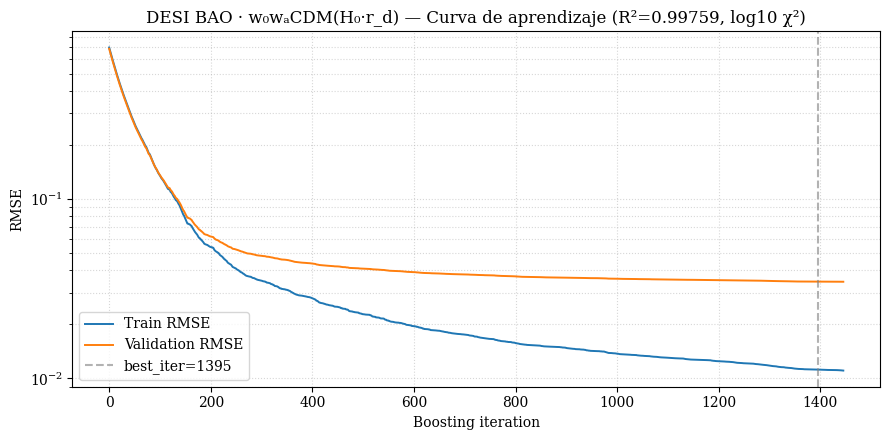

In [46]:
plot_learning_curve(
    info,
    title=f"DESI BAO · w₀wₐCDM(H₀·r_d) — Curva de aprendizaje (R²={info['r2']:.5f}, log10 χ²)",
    save_path=None,
    show=True,
)

--- $w_0$ vs $\Omega_m$  ({'wa': -1.614135173430772, 'H0_rd': 9475.491048733724}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_Om_w0.png


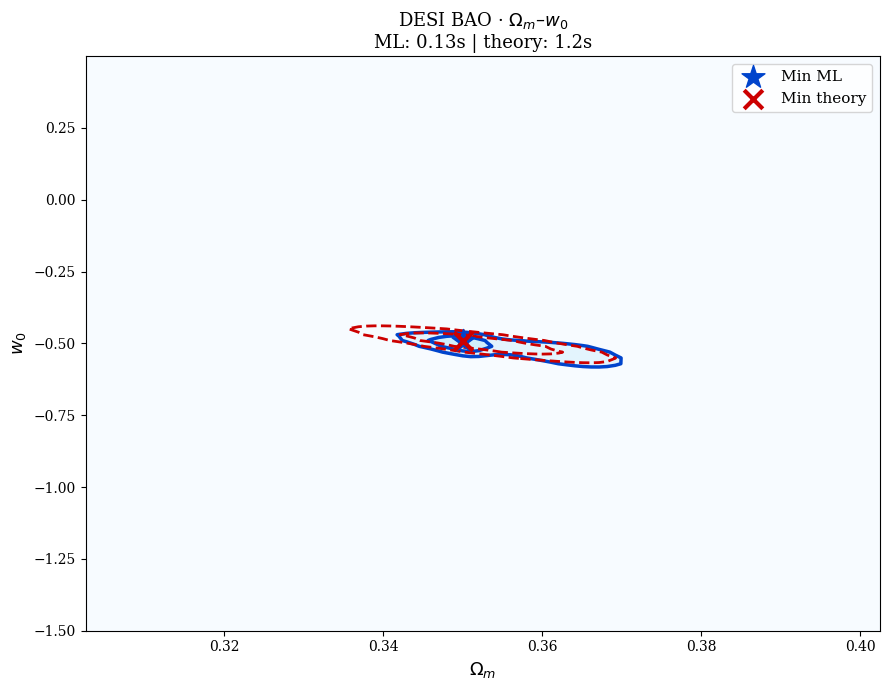

--- $w_a$ vs $\Omega_m$  ({'w0': -0.5000299029519061, 'H0_rd': 9475.491048733724}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_Om_wa.png


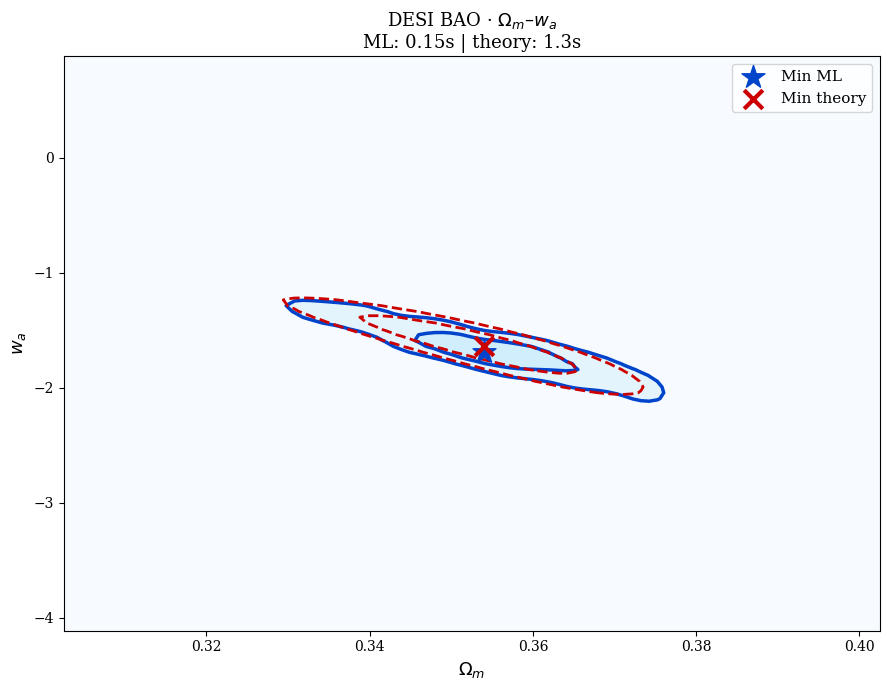

--- $H_0 \cdot r_d$ vs $\Omega_m$  ({'w0': -0.5000299029519061, 'wa': -1.614135173430772}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_Om_H0_rd.png


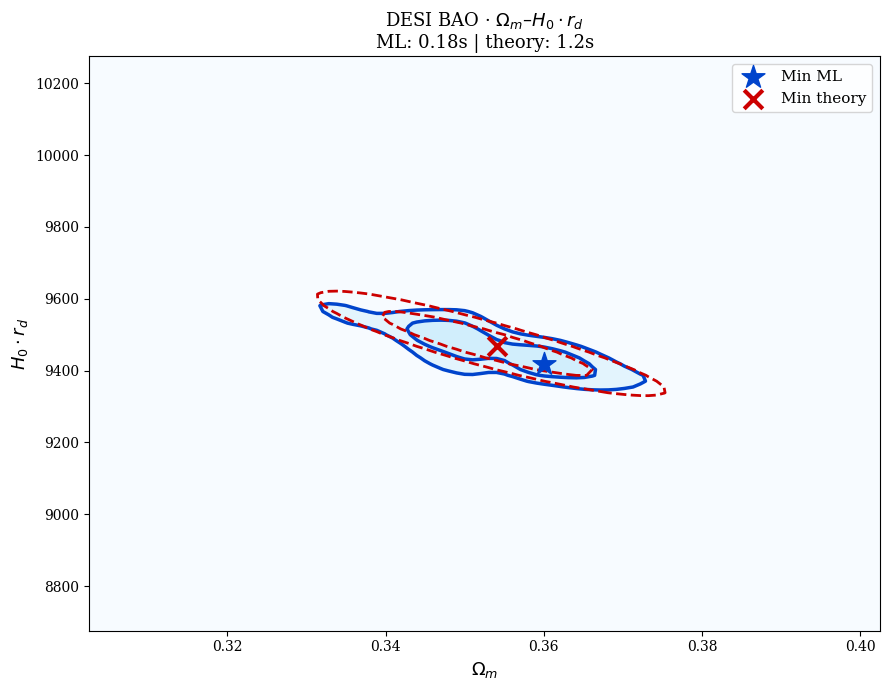

--- $w_a$ vs $w_0$  ({'Om': 0.35251850406437224, 'H0_rd': 9475.491048733724}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_w0_wa.png


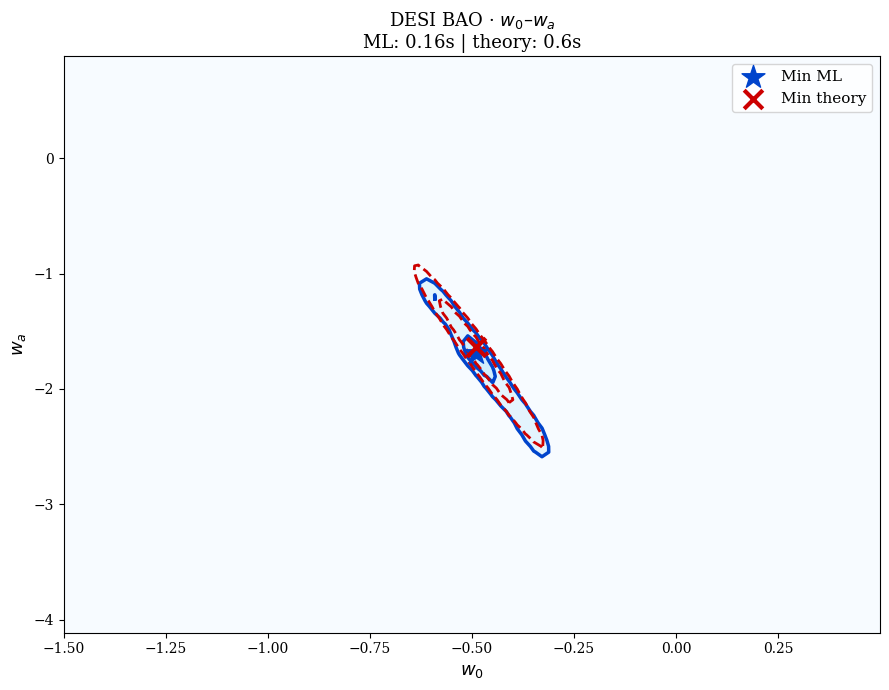

--- $H_0 \cdot r_d$ vs $w_0$  ({'Om': 0.35251850406437224, 'wa': -1.614135173430772}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_w0_H0_rd.png


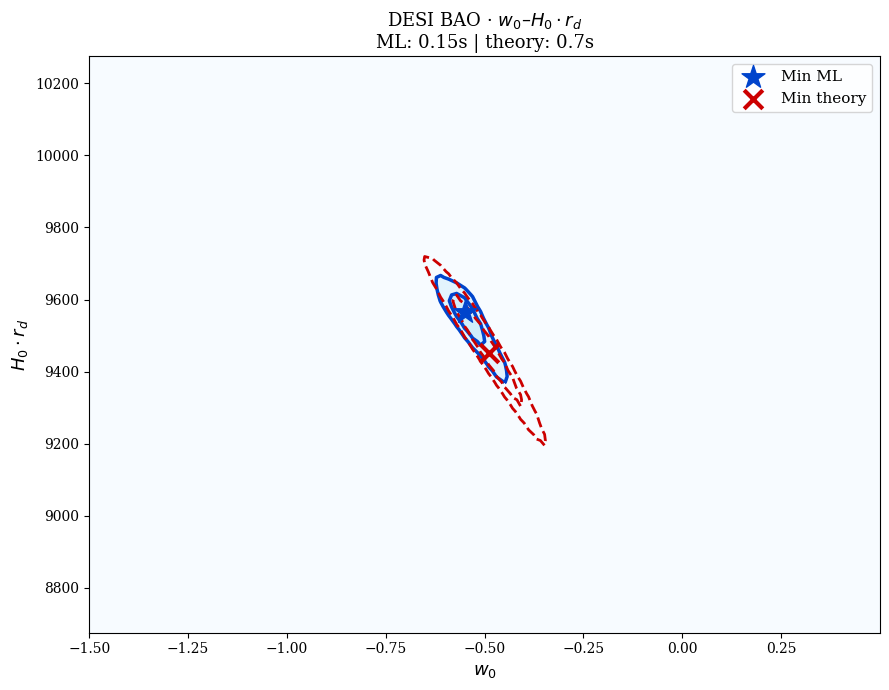

--- $H_0 \cdot r_d$ vs $w_a$  ({'Om': 0.35251850406437224, 'w0': -0.5000299029519061}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_wa_H0_rd.png


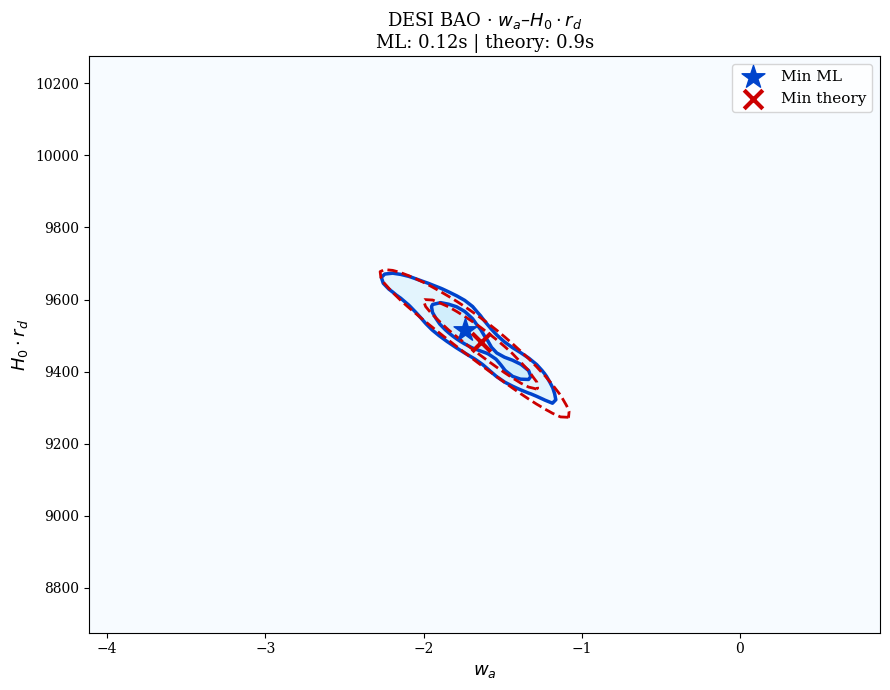

In [47]:
common = dict(res=100, sigma=2.0, theory_threshold=50)
RANGES = dict(
    Om=(REF['Om']    - 0.05,    REF['Om']    + 0.05),
    w0=(REF['w0']    - 1.0,     REF['w0']    + 1.0),
    wa=(REF['wa']    - 2.5,     REF['wa']    + 2.5),
    H0_rd=(REF['H0_rd'] - 800,  REF['H0_rd'] + 800),
)
LABELS = dict(Om=r"$\Omega_m$", w0=r"$w_0$", wa=r"$w_a$", H0_rd=r"$H_0 \cdot r_d$")

for x, y in [('Om','w0'), ('Om','wa'), ('Om','H0_rd'),
             ('w0','wa'), ('w0','H0_rd'), ('wa','H0_rd')]:
    fixed = {k: REF[k] for k in FEATURES if k not in (x, y)}
    plot_contour_2d(
        model, features=FEATURES,
        x_param=x, y_param=y,
        x_range=RANGES[x], y_range=RANGES[y],
        fixed=fixed, theory_fn=chi2_fn,
        title=fr"DESI BAO · {LABELS[x]}–{LABELS[y]}",
        x_label=LABELS[x], y_label=LABELS[y],
        save_path=None,
        show=True, **common,
        global_min_chi2=res_opt.fun,
    )


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_shap_beeswarm.png


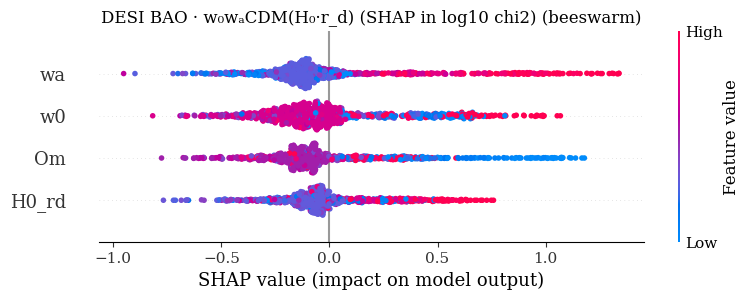

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_shap_bar.png


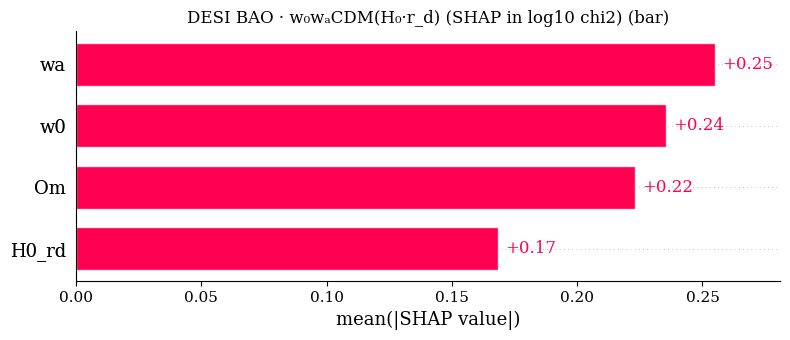

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_shap_waterfall.png


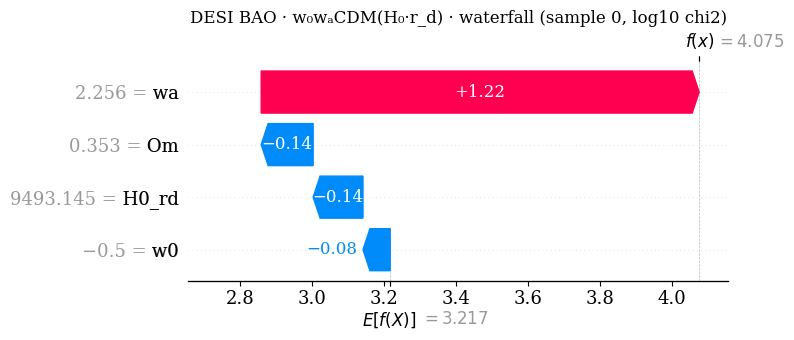

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_shap_Om.png


<Figure size 640x480 with 0 Axes>

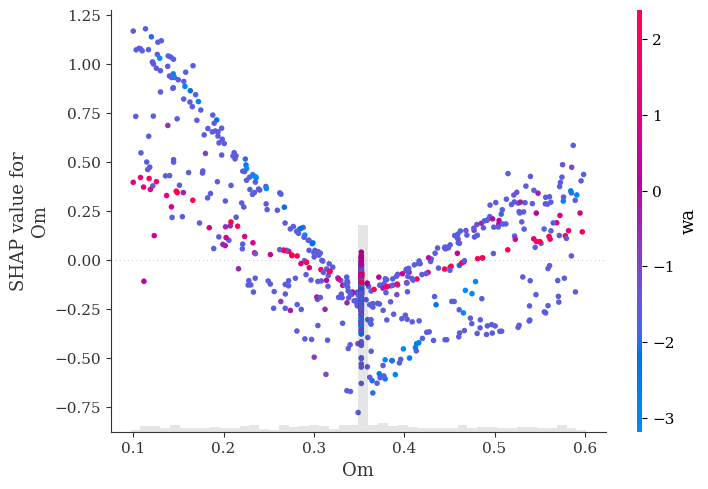

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_shap_w0.png


<Figure size 640x480 with 0 Axes>

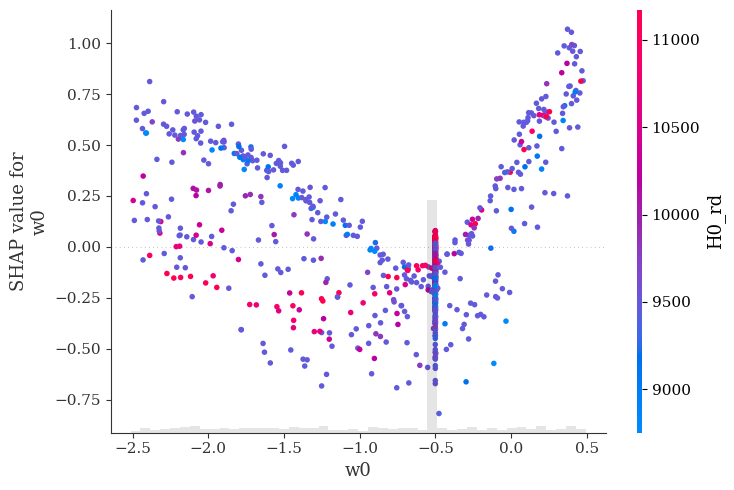

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_shap_wa.png


<Figure size 640x480 with 0 Axes>

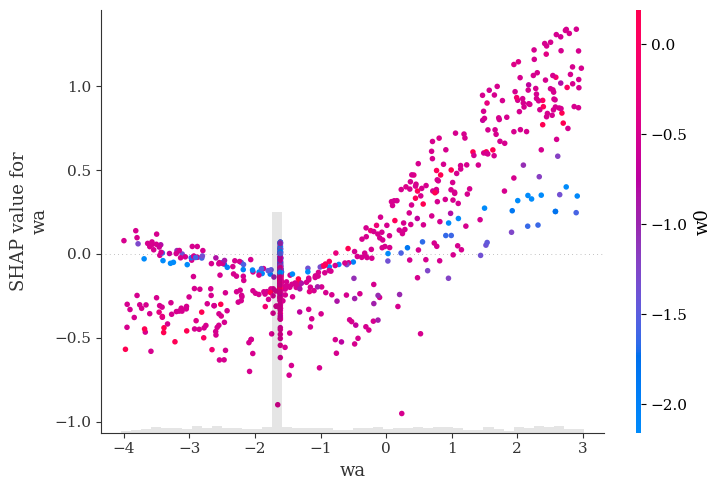

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_shap_H0_rd.png


<Figure size 640x480 with 0 Axes>

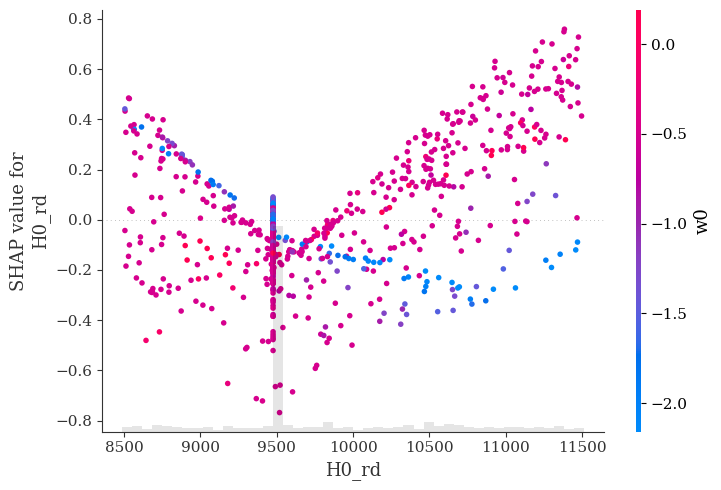

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_shap_w0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_shap_wa.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_shap_H0_rd.png')]

In [48]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=None, prefix=SECTION,
    title="DESI BAO · w₀wₐCDM(H₀·r_d) (SHAP in log10 chi2)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=None,
    title="DESI BAO · w₀wₐCDM(H₀·r_d) · waterfall (sample 0, log10 chi2)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=None, prefix=SECTION,
    show=True,
)

--- corner marginal: 512 chains × 5000 steps (burn-in 400, ndim=4) ---
  loading CPU booster copy...
  step   200/5000  |  60 it/s  |  ETA 80s  |  acc 0.18  |  diagonal
  step   400/5000  |  62 it/s  |  ETA 75s  |  acc 0.20  |  multivar
  step   600/5000  |  65 it/s  |  ETA ≤6s  |  acc 0.17  |  τ=57.2  ESS=1789/5000  |  multivar
  step   800/5000  |  67 it/s  |  ETA ≤10s  |  acc 0.16  |  τ=108.9  ESS=1881/5000  |  multivar
  step  1000/5000  |  68 it/s  |  ETA ≤9s  |  acc 0.15  |  τ=125.4  ESS=2449/5000  |  multivar
  step  1200/5000  |  69 it/s  |  ETA ≤10s  |  acc 0.14  |  τ=152.0  ESS=2695/5000  |  multivar
  step  1400/5000  |  69 it/s  |  ETA ≤7s  |  acc 0.14  |  τ=148.8  ESS=3440/5000  |  multivar
  step  1600/5000  |  69 it/s  |  ETA ≤8s  |  acc 0.13  |  τ=178.7  ESS=3439/5000  |  multivar
  step  1800/5000  |  67 it/s  |  ETA ≤6s  |  acc 0.13  |  τ=182.8  ESS=3921/5000  |  multivar
  step  2000/5000  |  67 it/s  |  ETA ≤10s  |  acc 0.13  |  τ=233.5  ESS=3509/5000  |  multivar
 

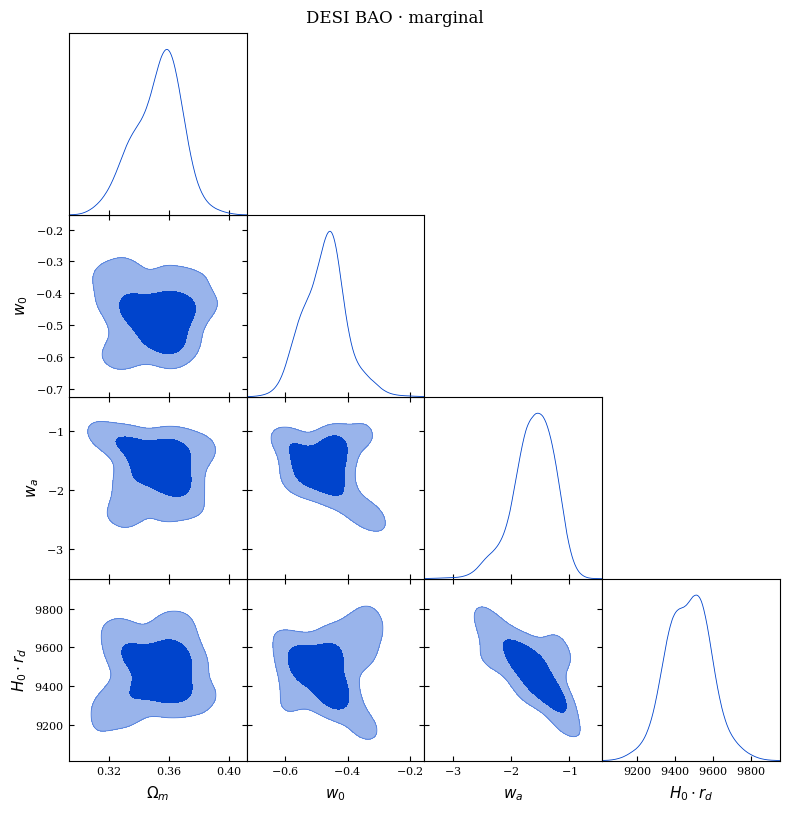

array([[ 3.51187259e-01, -5.14269292e-01, -1.46597934e+00,
         9.41669141e+03],
       [ 3.56811404e-01, -4.60838169e-01, -1.87253332e+00,
         9.48885352e+03],
       [ 3.65622073e-01, -5.10325253e-01, -1.78016913e+00,
         9.47337793e+03],
       ...,
       [ 3.52700055e-01, -4.76092935e-01, -1.85189223e+00,
         9.48397363e+03],
       [ 3.48911971e-01, -4.42690521e-01, -1.40380204e+00,
         9.43735449e+03],
       [ 3.29903394e-01, -4.04394001e-01, -1.31746197e+00,
         9.39157227e+03]], shape=(1126912, 4))

In [49]:
# --- Marginalised corner plot (MCMC posterior via XGBoost surrogate) ---
from cosmoml.ml import plot_corner_marginal
plot_corner_marginal(
    model, features=FEATURES, ranges=RANGES,
    labels=LABELS, ref=REF,
    markers={k: v for k, v in {'w0': -1.0, 'wa': 0.0}.items() if k in FEATURES},
    title="DESI BAO · marginal",
    save_path=None,
    show=True,
)

## <a id="3-7"></a>3.7 H0–rd degeneracy (SHAP) — 5D without priors

**Model:** `Flatw0waCDM` 5D (Om, w0, wa, H0, rd).
**Data:** DESI BAO DR2; 40k random points, no slices, no priors.
**Purpose:** show visually with SHAP that BAO **does not constrain H0 and rd
separately**, only the product H0*rd (the analytical demonstration is in 3.6).
Expected SHAP reading:
- Importance of Om, w0, wa: **high** (the data constrains them).
- Importance of H0 and rd alone: **low**, with strong anti-correlation in the
  dependence plots (the degeneracy fingerprint).

No contours — the goal here is the SHAP reading of the degeneracy.


In [70]:
SECTION = "3_7"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "w0", "wa", "H0", "rd"]

def chi2_fn(Om, w0, wa, H0, rd):
    return chi2_bao(bao_full, Om=Om, w0=w0, wa=wa, H0=H0, rd=rd)

# Auto-center: locate the best-fit with Minuit
import types
from iminuit import Minuit
print("Locating the global minimum with Minuit...")
_m = Minuit(chi2_fn, **dict(zip(FEATURES, [0.3153, -1.0, 0.0, 67.36, 147.09])))
_m.limits = [(0.2, 0.42), (-1.6, -0.5), (-2.0, 1.0), (55, 85), (130, 165)]
_m.migrad()
res_opt = types.SimpleNamespace(fun=_m.fval, x=[float(_m.values[k]) for k in FEATURES])
REF = dict(zip(FEATURES, res_opt.x))
print(f"Auto-detected best-fit:  Om={REF['Om']:.4f}  w0={REF['w0']:.4f}  wa={REF['wa']:.4f}  H0={REF['H0']:.4f}  rd={REF['rd']:.4f}")
print(f"chi2(best-fit) = {res_opt.fun:.2f}")


Locating the global minimum with Minuit...
Auto-detected best-fit:  Om=0.3526  w0=-0.5000  wa=-1.6164  H0=65.8578  rd=143.8848
chi2(best-fit) = 6.21


In [71]:
def builder():
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        random_box=dict(
            Om=(0.20, 0.40), w0=(-1.5, -0.5), wa=(-1.5, 1.0),
            H0=(60, 75), rd=(140, 155),
        ),
        n_random=40_000,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min chi2 = {df['chi2'].min():.3f}")

Loading cached dataset: /home/aleja/PhysicsML/CosmoML/outputs/datasets/3_7_dataset.csv
min chi2 = 7.757


  loading cached model: 3_7_model.ubj
  R2=0.93748 | best_iter=740 | n_train=34,000 | n_val=6,000
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_7_learning_curve.png


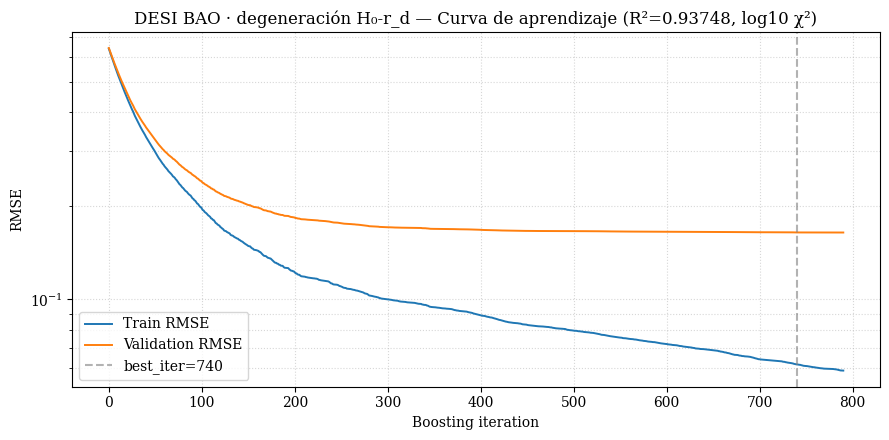

In [72]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=None,
    force_retrain=FORCE_RETRAIN,
)
plot_learning_curve(
    info,
    title=f"DESI BAO · degeneración H₀-r_d — Curva de aprendizaje (R²={info['r2']:.5f}, log10 χ²)",
    save_path=None,
    show=True,
)

### Reading the degeneracy

The **bar** plot ranks features by mean |SHAP|. Expect w0, wa and Om above H0
and rd taken separately.

The **dependence** plots of H0 and rd should show high color dispersion
(strong interaction with the other parameter) — the H0*rd degeneracy signature.


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_7_shap_beeswarm.png


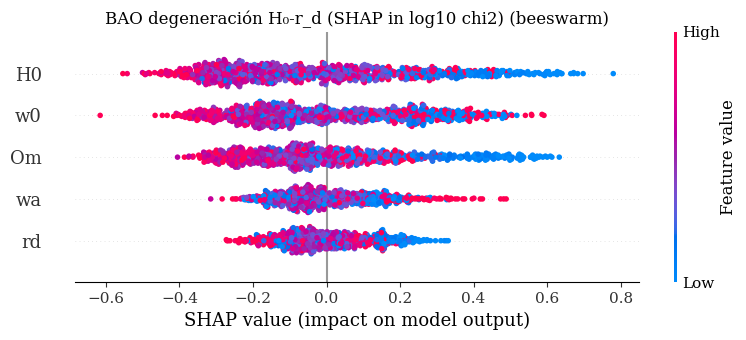

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_7_shap_bar.png


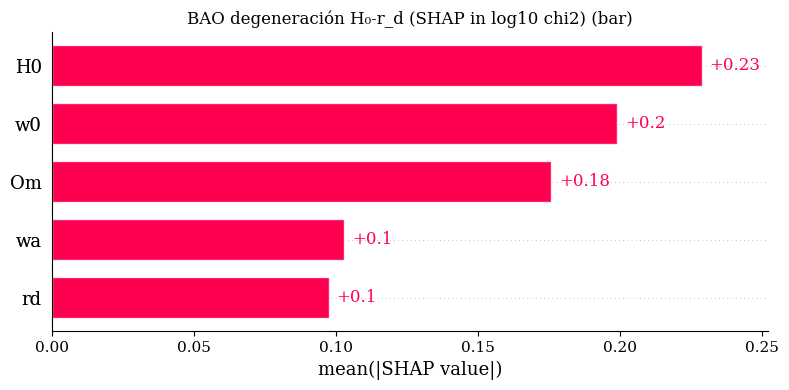

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_7_shap_waterfall.png


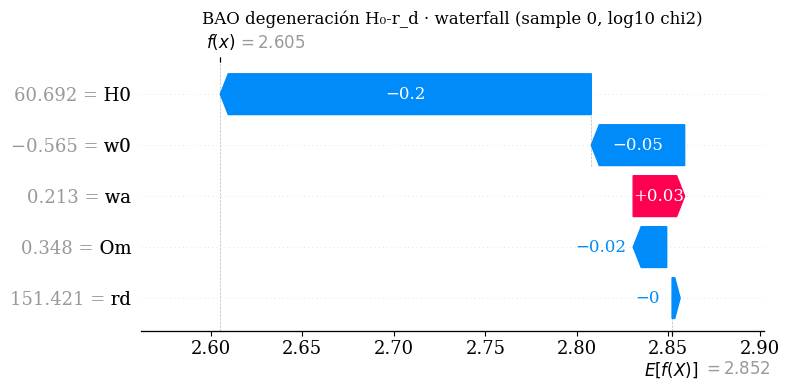

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_7_shap_Om.png


<Figure size 640x480 with 0 Axes>

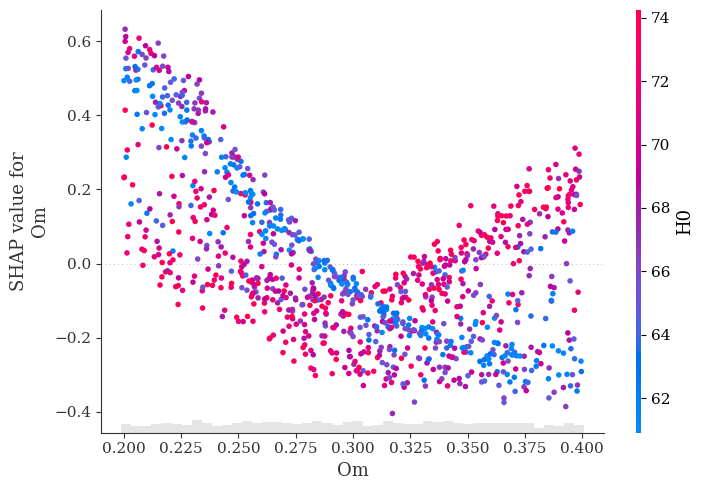

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_7_shap_w0.png


<Figure size 640x480 with 0 Axes>

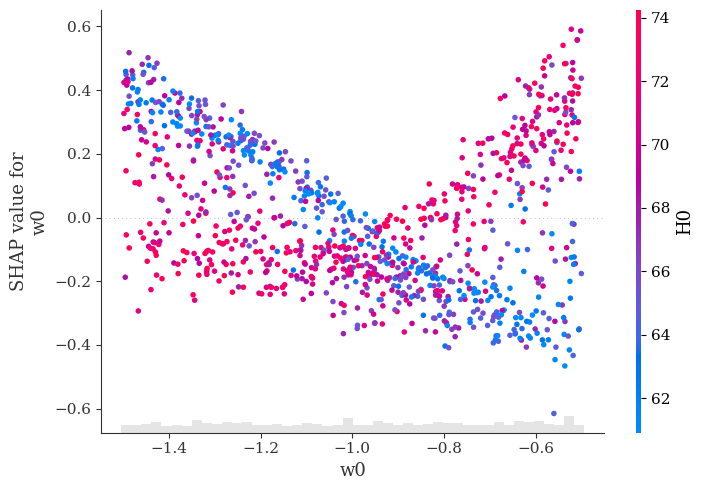

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_7_shap_wa.png


<Figure size 640x480 with 0 Axes>

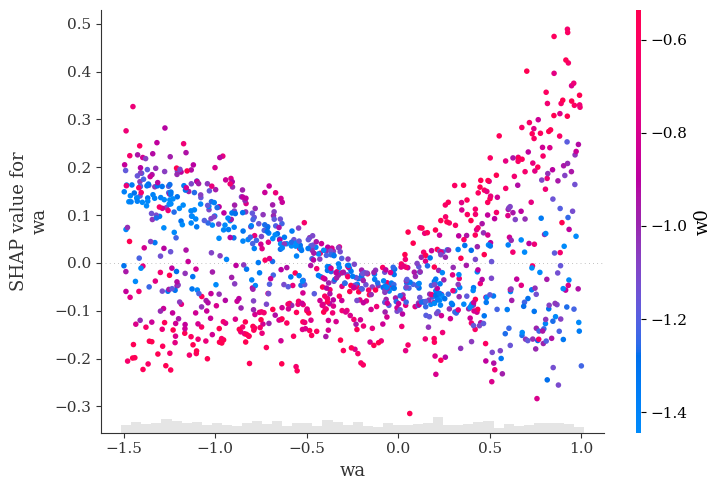

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_7_shap_H0.png


<Figure size 640x480 with 0 Axes>

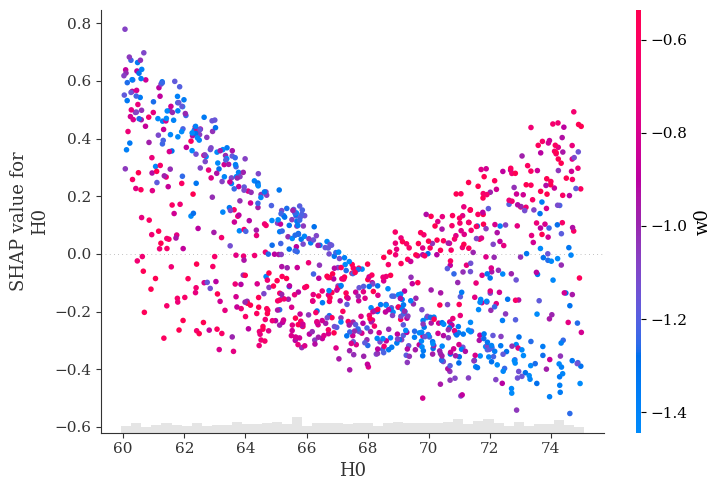

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_7_shap_rd.png


<Figure size 640x480 with 0 Axes>

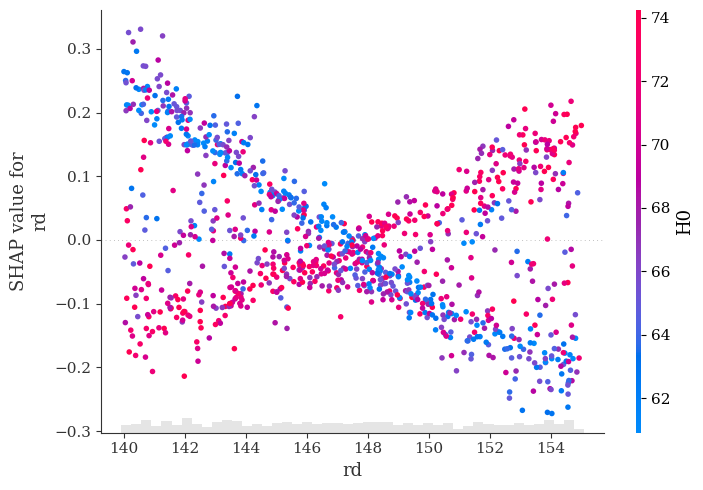

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_7_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_7_shap_w0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_7_shap_wa.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_7_shap_H0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_7_shap_rd.png')]

In [73]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=None, prefix=SECTION,
    title="BAO degeneración H₀-r_d (SHAP in log10 chi2)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=None,
    title="BAO degeneración H₀-r_d · waterfall (sample 0, log10 chi2)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=None, prefix=SECTION,
    show=True,
)

## <a id="3-8"></a>3.8 w0waCDM + Planck priors on Om/H0/rd — 5D

**Model:** `Flatw0waCDM` 5D (Om, w0, wa, H0, rd).
**Data:** DESI BAO DR2 + Gaussian Planck 2018 priors on (Om, H0, rd). w0 and wa free.
**Purpose:** combine BAO with the early-universe (Planck) without assuming
anything about dark energy. Priors anchor Om/H0/rd at Planck values and let
us see how BAO constrains (w0, wa) conditionally.

Priors: Om = 0.3153 +/- 0.0073, H0 = 67.36 +/- 0.54, rd = 147.09 +/- 0.26
(all three combined in `cosmoml.priors.planck_prior_chi2`).


In [55]:
SECTION = "3_8"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "w0", "wa", "H0", "rd"]

def chi2_fn(Om, w0, wa, H0, rd):
    return (chi2_bao(bao_full, Om=Om, w0=w0, wa=wa, H0=H0, rd=rd)
            + planck_prior_chi2(Om=Om, H0=H0, rd=rd))

# Auto-center: locate the best-fit with Minuit
import types
from iminuit import Minuit
print("Locating the global minimum with Minuit...")
_m = Minuit(chi2_fn, **dict(zip(FEATURES, [0.3153, -1.0, 0.0, 67.36, 147.09])))
_m.limits = [(0.25, 0.4), (-1.6, -0.5), (-2.0, 1.0), (60, 75), (140, 155)]
_m.migrad()
res_opt = types.SimpleNamespace(fun=_m.fval, x=[float(_m.values[k]) for k in FEATURES])
REF = dict(zip(FEATURES, res_opt.x))
print(f"Auto-detected best-fit:  Om={REF['Om']:.4f}  w0={REF['w0']:.4f}  wa={REF['wa']:.4f}  H0={REF['H0']:.4f}  rd={REF['rd']:.4f}")
print(f"chi2(best-fit) = {res_opt.fun:.2f}")


Locating the global minimum with Minuit...
Auto-detected best-fit:  Om=0.3153  w0=-0.8160  wa=-0.5389  H0=67.2310  rd=147.0764
chi2(best-fit) = 8.18


In [56]:
def builder():
    N = 12_000
    pares = [("Om","w0"), ("Om","wa"), ("Om","H0"), ("Om","rd"),
             ("w0","wa"), ("w0","H0"), ("w0","rd"),
             ("wa","H0"), ("wa","rd"), ("H0","rd")]
    rangos = dict(
        Om=(REF["Om"]-0.08, REF["Om"]+0.08),
        w0=(REF["w0"]-1.5,  REF["w0"]+1.5),
        wa=(REF["wa"]-3.5,  REF["wa"]+3.5),
        H0=(REF["H0"]-6.0,  REF["H0"]+6.0),
        rd=(REF["rd"]-6.0,  REF["rd"]+6.0),
    )
    slices = [{**REF, a: rangos[a], b: rangos[b], "_n": N} for a, b in pares]
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        slices=slices,
        random_box=dict(Om=(0.25,0.40), w0=(-2.0,0.2), wa=(-4.0,3.0),
                        H0=(60,75), rd=(140,155)),
        n_random=20_000,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min chi2 = {df['chi2'].min():.3f}")

Loading cached dataset: /home/aleja/PhysicsML/CosmoML/outputs/datasets/3_8_dataset.csv
min chi2 = 8.201


In [57]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=None,
    force_retrain=FORCE_RETRAIN,
)

  loading cached model: 3_8_model.ubj
  R2=0.99676 | best_iter=1199 | n_train=119,000 | n_val=21,000


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_learning_curve.png


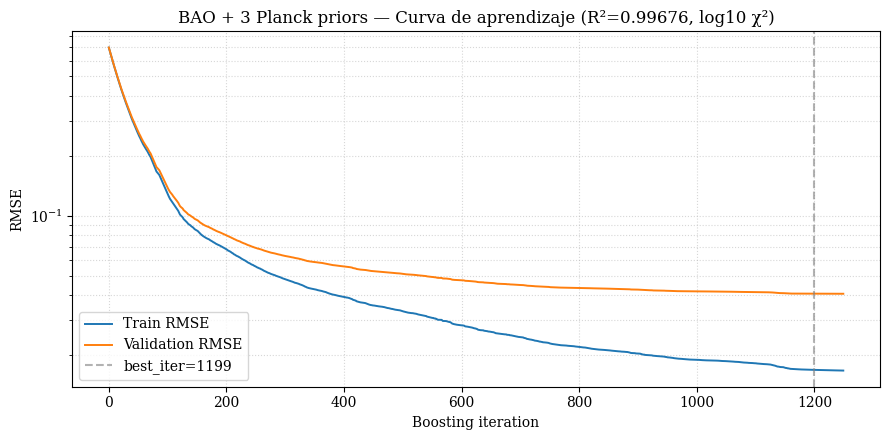

In [58]:
plot_learning_curve(
    info,
    title=f"BAO + 3 Planck priors — Curva de aprendizaje (R²={info['r2']:.5f}, log10 χ²)",
    save_path=None,
    show=True,
)

--- $w_0$ vs $\Omega_m$  ({'wa': -0.5388901734372668, 'H0': 67.23099687739101, 'rd': 147.0764444854717}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_Om_w0.png


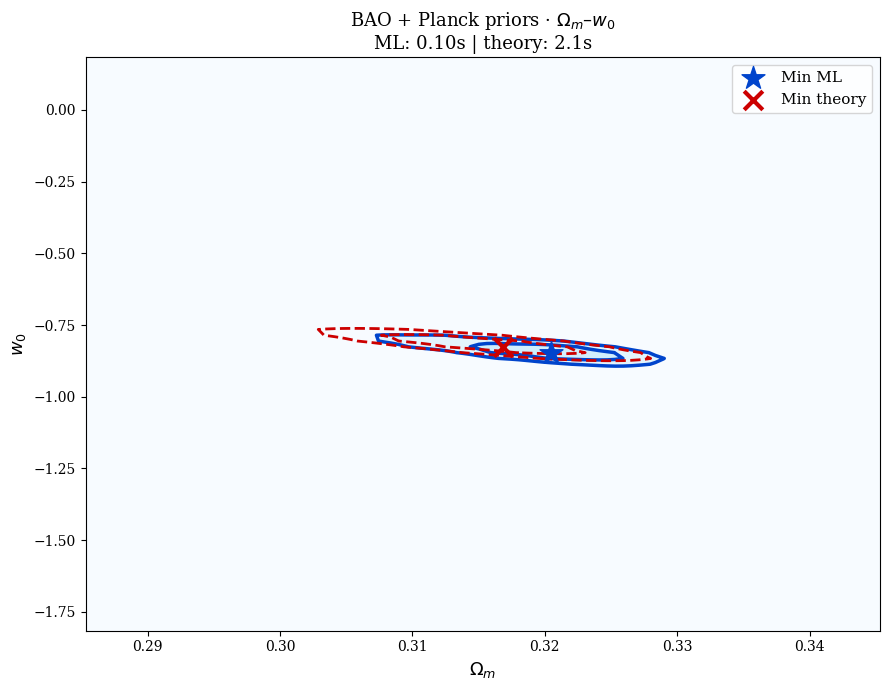

--- $w_a$ vs $\Omega_m$  ({'w0': -0.8159615964547282, 'H0': 67.23099687739101, 'rd': 147.0764444854717}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_Om_wa.png


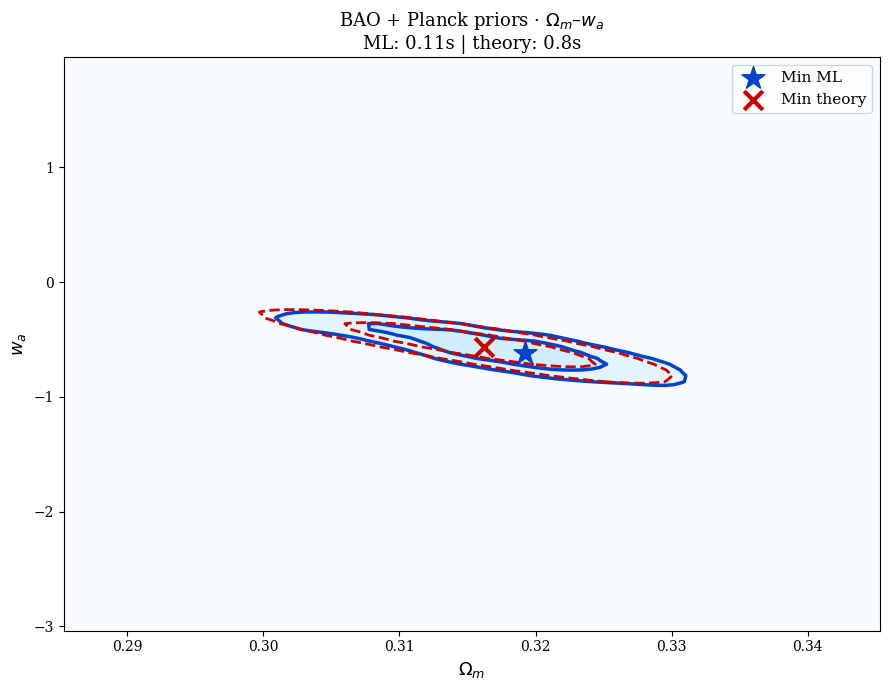

--- $H_0$ vs $\Omega_m$  ({'w0': -0.8159615964547282, 'wa': -0.5388901734372668, 'rd': 147.0764444854717}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_Om_H0.png


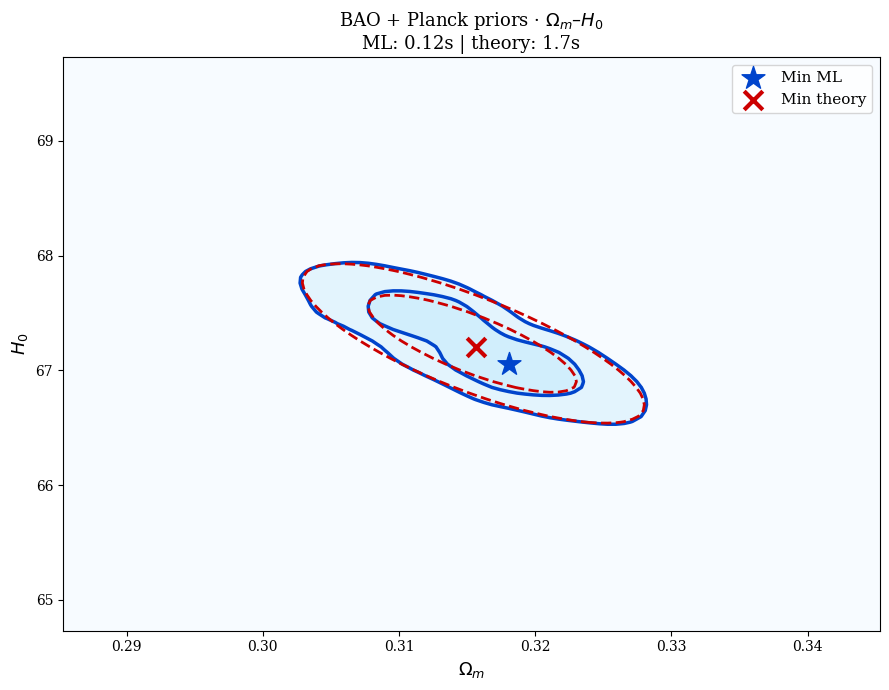

--- $r_d$ vs $\Omega_m$  ({'w0': -0.8159615964547282, 'wa': -0.5388901734372668, 'H0': 67.23099687739101}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_Om_rd.png


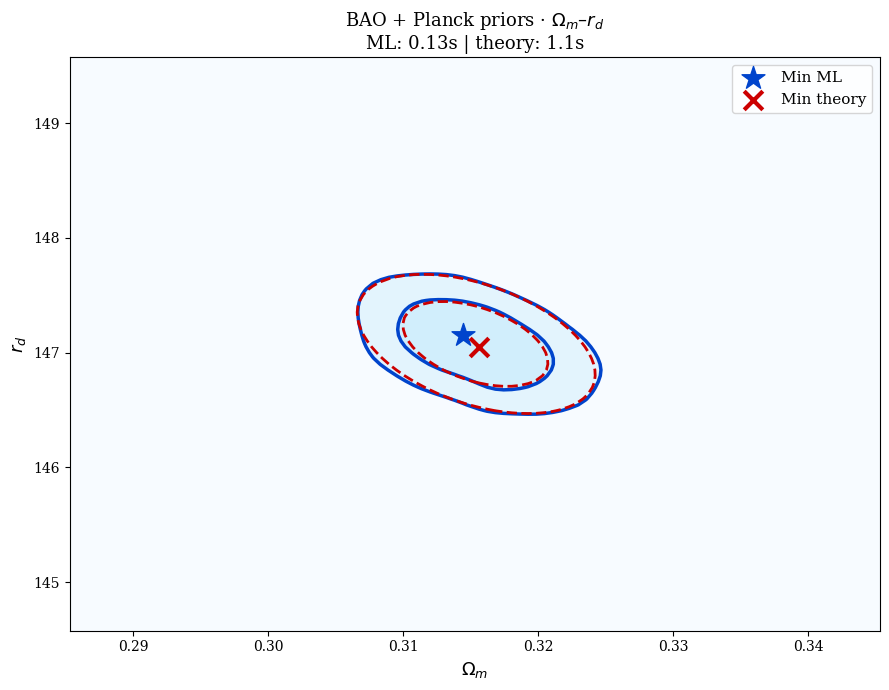

--- $w_a$ vs $w_0$  ({'Om': 0.3153223617569817, 'H0': 67.23099687739101, 'rd': 147.0764444854717}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_w0_wa.png


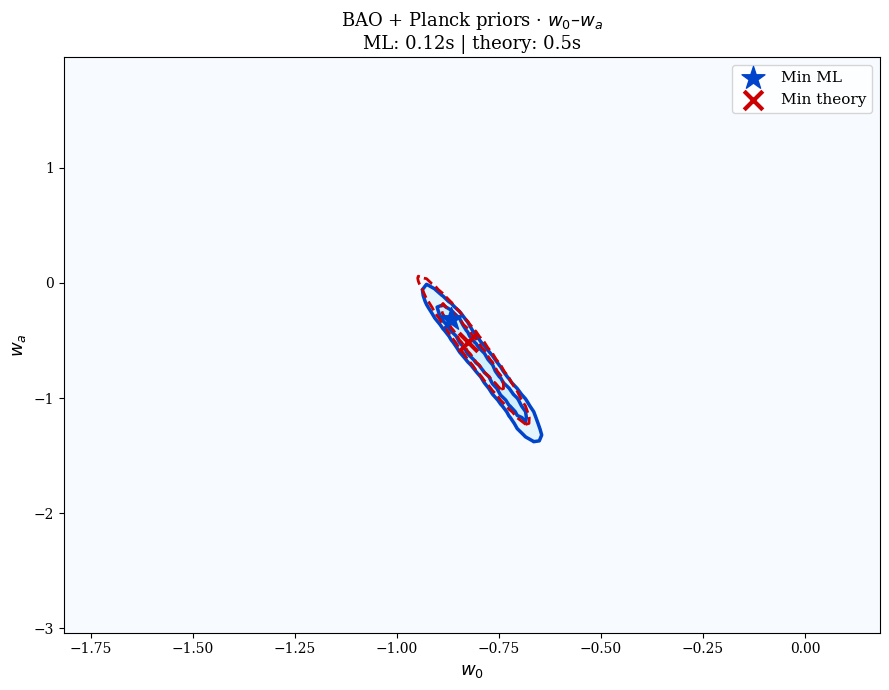

--- $H_0$ vs $w_0$  ({'Om': 0.3153223617569817, 'wa': -0.5388901734372668, 'rd': 147.0764444854717}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_w0_H0.png


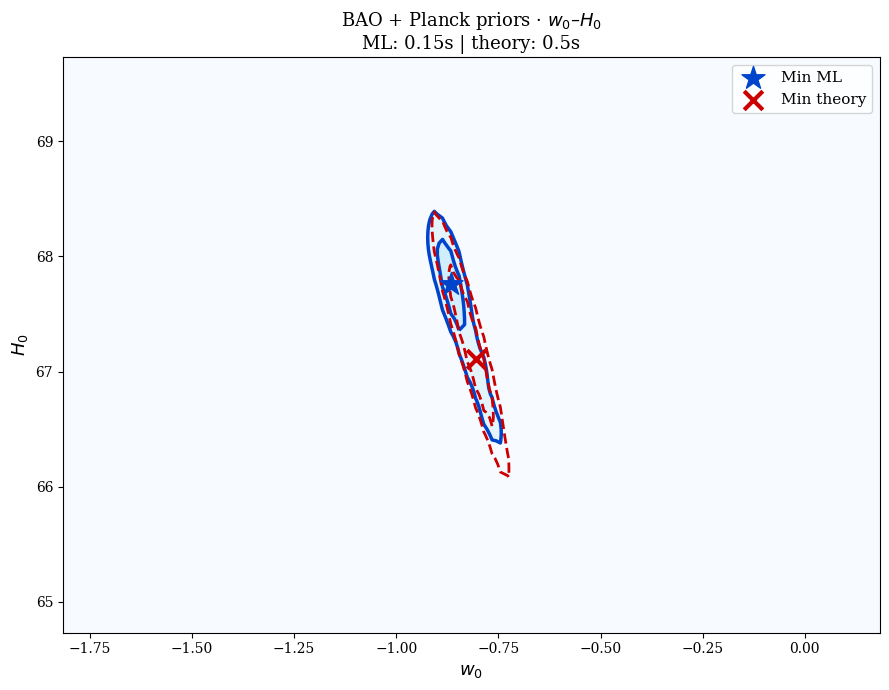

--- $r_d$ vs $w_0$  ({'Om': 0.3153223617569817, 'wa': -0.5388901734372668, 'H0': 67.23099687739101}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_w0_rd.png


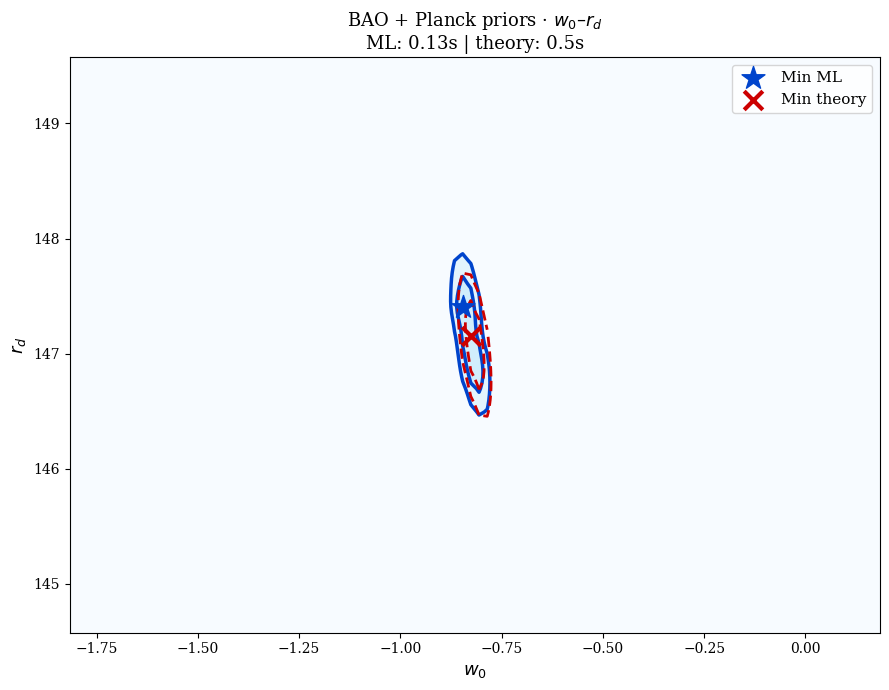

--- $H_0$ vs $w_a$  ({'Om': 0.3153223617569817, 'w0': -0.8159615964547282, 'rd': 147.0764444854717}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_wa_H0.png


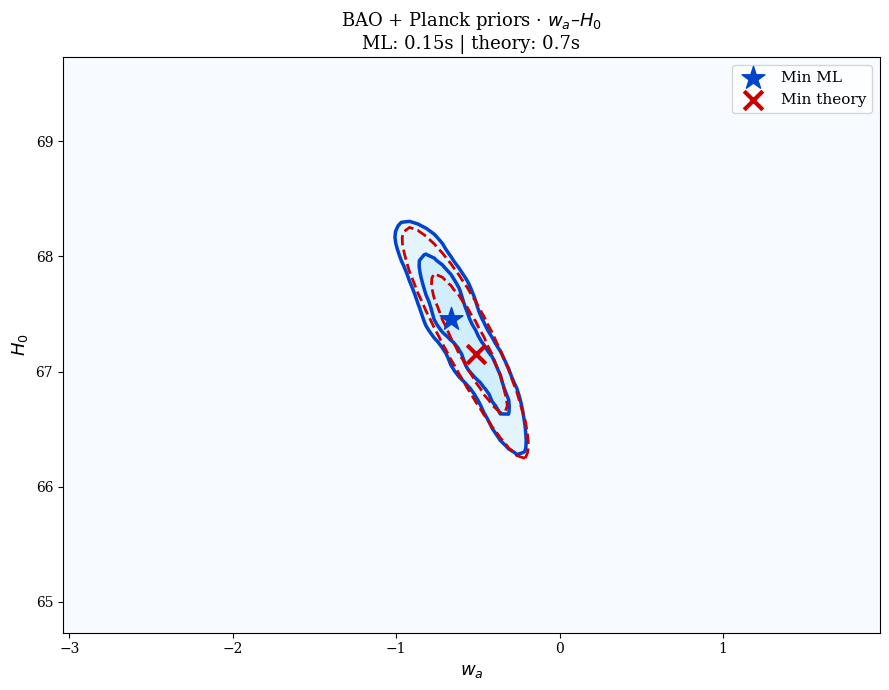

--- $r_d$ vs $w_a$  ({'Om': 0.3153223617569817, 'w0': -0.8159615964547282, 'H0': 67.23099687739101}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_wa_rd.png


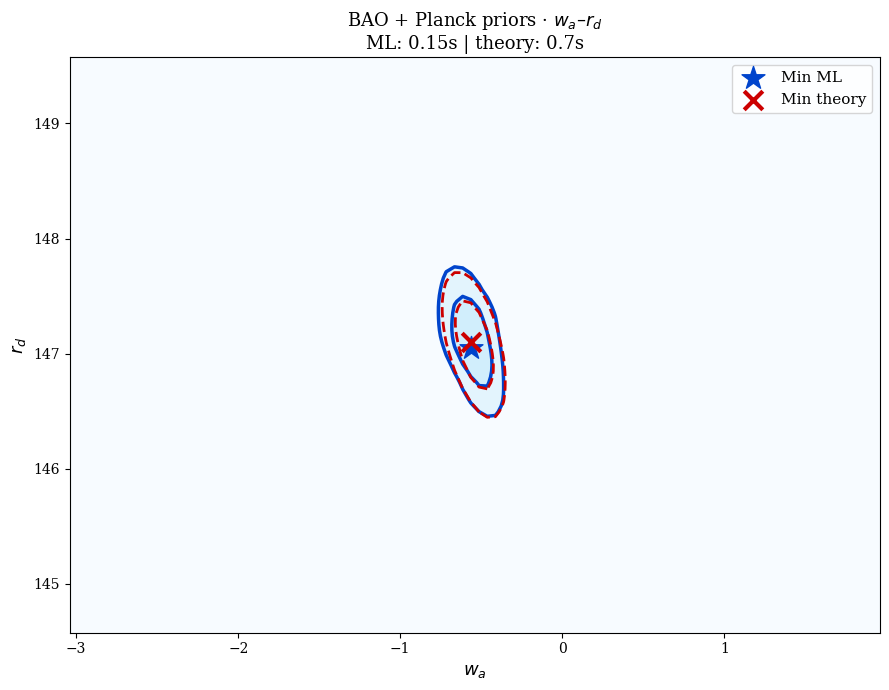

--- $r_d$ vs $H_0$  ({'Om': 0.3153223617569817, 'w0': -0.8159615964547282, 'wa': -0.5388901734372668}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_H0_rd.png


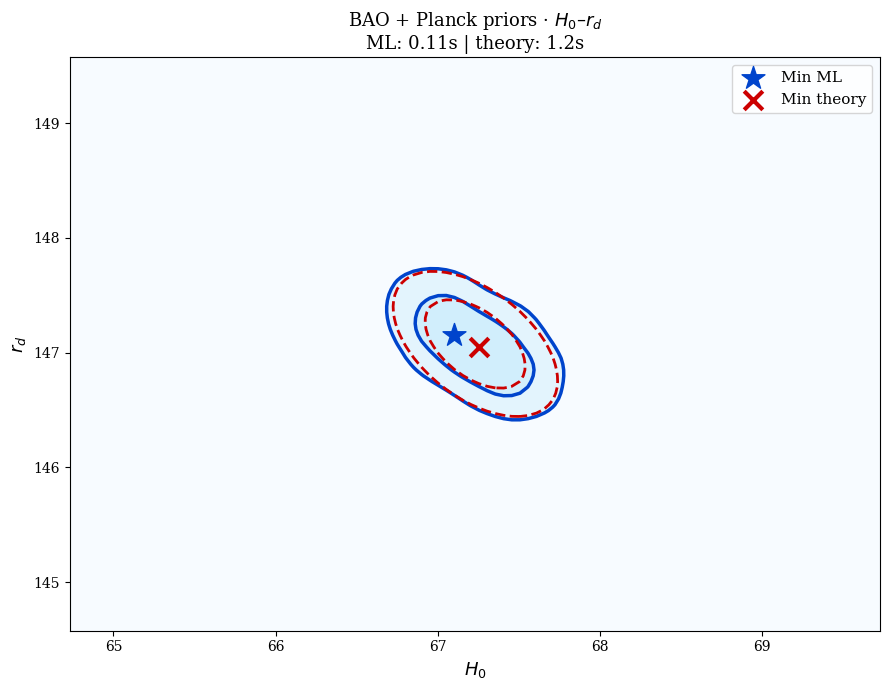

In [59]:
common = dict(res=100, sigma=2.0, theory_threshold=20)
RANGES = dict(
    Om=(REF['Om'] - 0.03, REF['Om'] + 0.03),
    w0=(REF['w0'] - 1.0,  REF['w0'] + 1.0),
    wa=(REF['wa'] - 2.5,  REF['wa'] + 2.5),
    H0=(REF['H0'] - 2.5,  REF['H0'] + 2.5),
    rd=(REF['rd'] - 2.5,  REF['rd'] + 2.5),
)
LABELS = dict(Om=r"$\Omega_m$", w0=r"$w_0$", wa=r"$w_a$", H0=r"$H_0$", rd=r"$r_d$")

for x, y in [('Om','w0'), ('Om','wa'), ('Om','H0'), ('Om','rd'),
             ('w0','wa'), ('w0','H0'), ('w0','rd'),
             ('wa','H0'), ('wa','rd'), ('H0','rd')]:
    fixed = {k: REF[k] for k in FEATURES if k not in (x, y)}
    plot_contour_2d(
        model, features=FEATURES,
        x_param=x, y_param=y,
        x_range=RANGES[x], y_range=RANGES[y],
        fixed=fixed, theory_fn=chi2_fn,
        title=fr"BAO + Planck priors · {LABELS[x]}–{LABELS[y]}",
        x_label=LABELS[x], y_label=LABELS[y],
        save_path=None,
        show=True, **common,
        global_min_chi2=res_opt.fun,
    )


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_shap_beeswarm.png


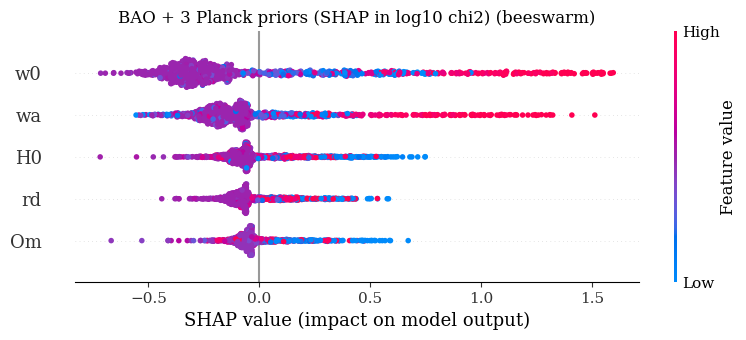

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_shap_bar.png


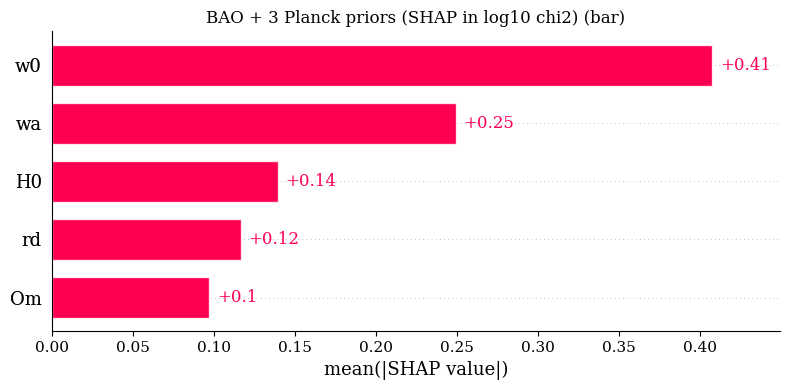

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_shap_waterfall.png


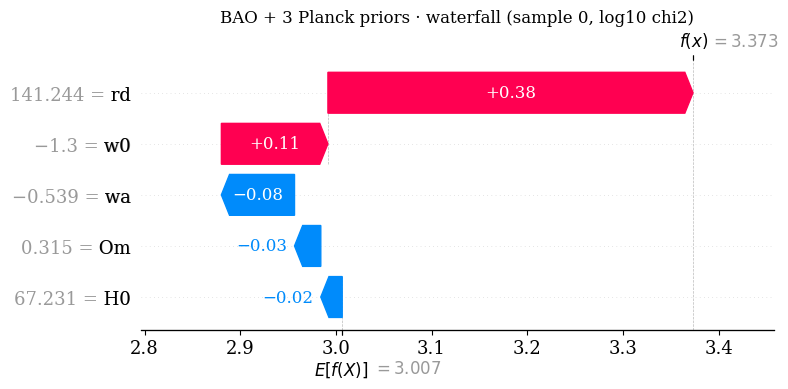

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_shap_Om.png


<Figure size 640x480 with 0 Axes>

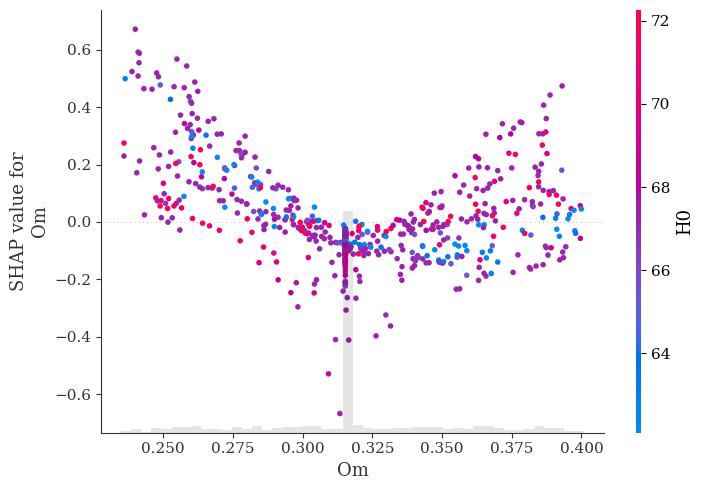

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_shap_w0.png


<Figure size 640x480 with 0 Axes>

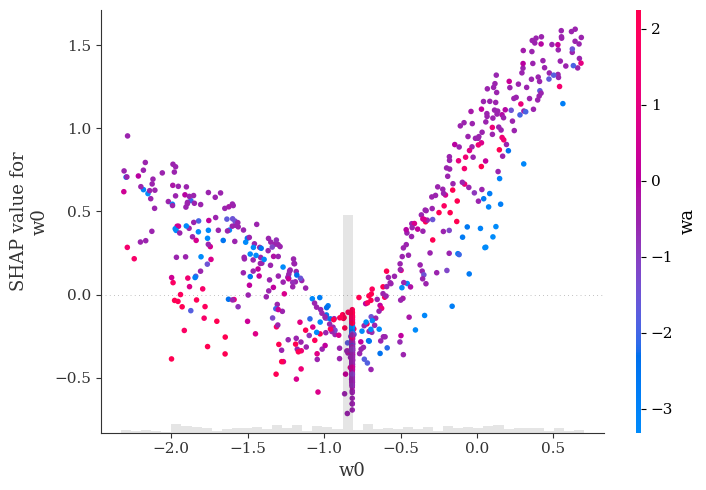

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_shap_wa.png


<Figure size 640x480 with 0 Axes>

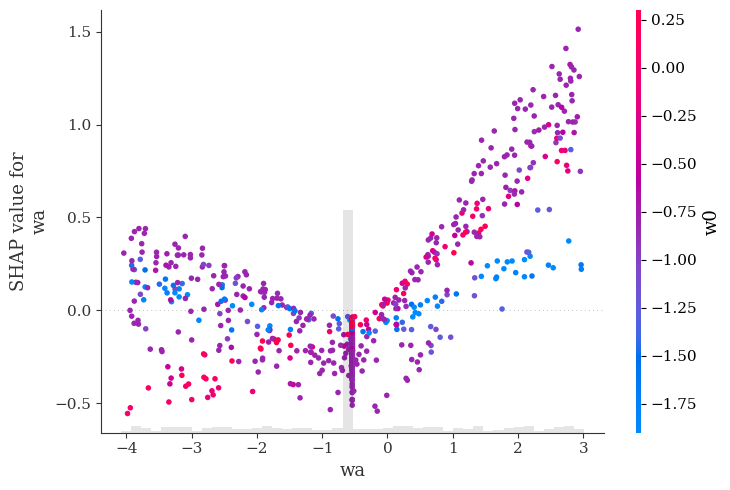

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_shap_H0.png


<Figure size 640x480 with 0 Axes>

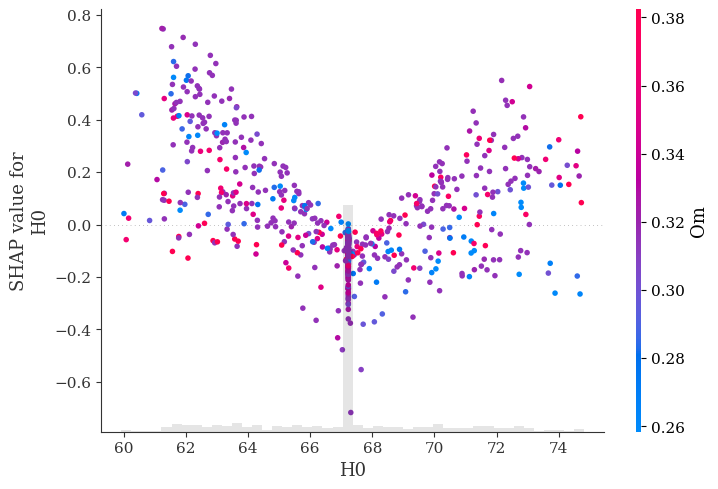

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_shap_rd.png


<Figure size 640x480 with 0 Axes>

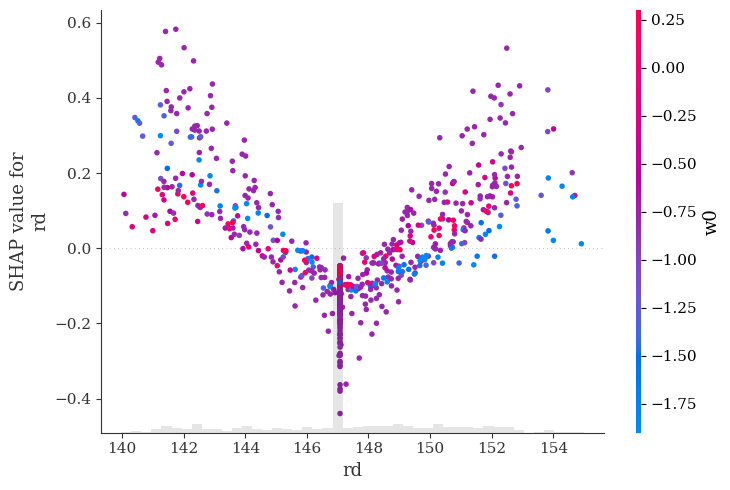

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_shap_w0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_shap_wa.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_shap_H0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_shap_rd.png')]

In [60]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=None, prefix=SECTION,
    title="BAO + 3 Planck priors (SHAP in log10 chi2)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=None,
    title="BAO + 3 Planck priors · waterfall (sample 0, log10 chi2)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=None, prefix=SECTION,
    show=True,
)

--- corner marginal: 512 chains × 5000 steps (burn-in 400, ndim=5) ---
  loading CPU booster copy...
  step   200/5000  |  71 it/s  |  ETA 67s  |  acc 0.16  |  diagonal
  step   400/5000  |  71 it/s  |  ETA 65s  |  acc 0.15  |  multivar
  step   600/5000  |  53 it/s  |  ETA ≤4s  |  acc 0.18  |  τ=43.6  ESS=2351/5000  |  multivar
  step   800/5000  |  56 it/s  |  ETA ≤6s  |  acc 0.19  |  τ=74.4  ESS=2751/5000  |  multivar
  step  1000/5000  |  59 it/s  |  ETA ≤5s  |  acc 0.19  |  τ=88.9  ESS=3454/5000  |  multivar
  step  1200/5000  |  59 it/s  |  ETA ≤0s  |  acc 0.20  |  τ=76.1  ESS=5380/5000  |  multivar
  done: 20.5s  |  59 it/s  |  acceptance 0.199  |  multivariate proposal
  flat chain: 410,112 samples (512 chains × 801 steps)  |  τ_max=76.1  |  ESS=5387
Removed no burn in
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_corner.png


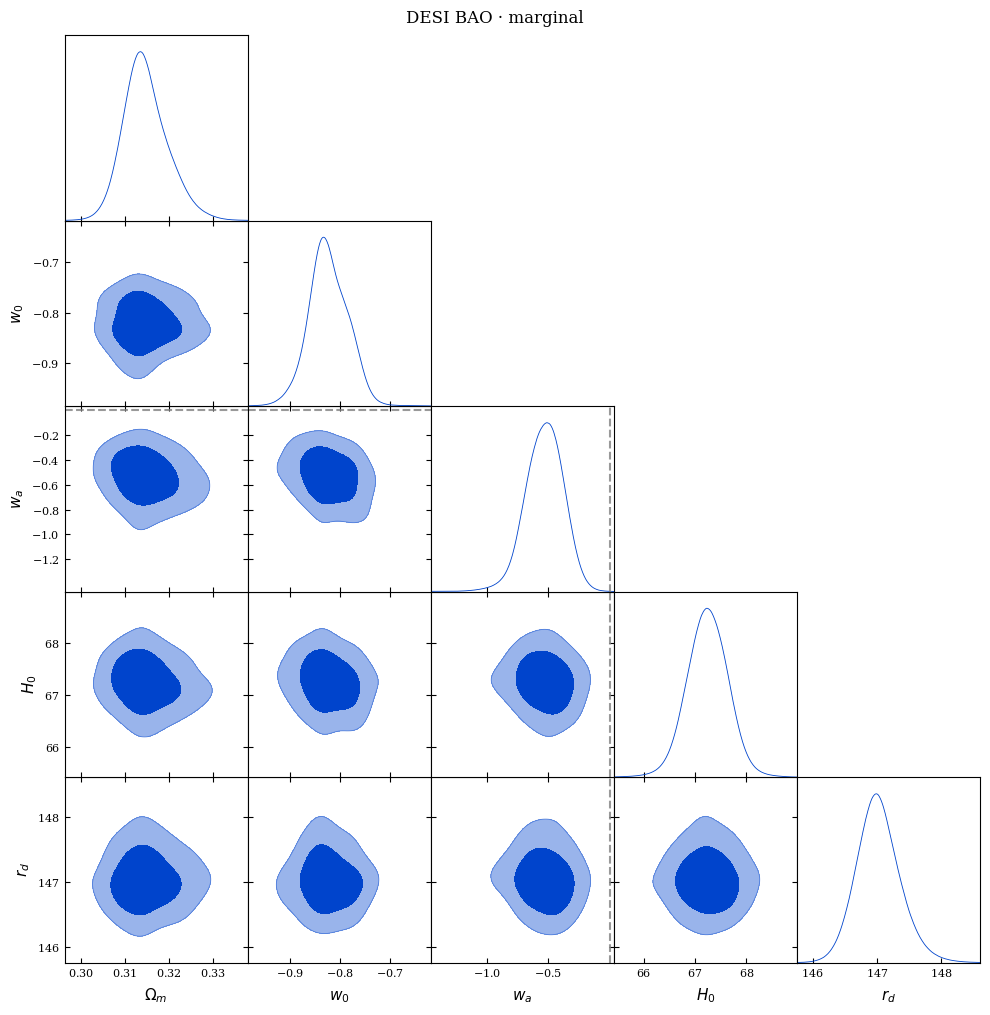

array([[ 3.09807509e-01, -7.99186826e-01, -6.19689703e-01,
         6.75550842e+01,  1.47294846e+02],
       [ 3.09804142e-01, -7.73656487e-01, -3.03372741e-01,
         6.76381760e+01,  1.47096252e+02],
       [ 3.14511418e-01, -8.33249629e-01, -5.62440693e-01,
         6.79896011e+01,  1.47029221e+02],
       ...,
       [ 3.12757850e-01, -9.21295166e-01, -9.67924148e-02,
         6.73623734e+01,  1.46971344e+02],
       [ 3.11020702e-01, -8.40531766e-01, -4.07698393e-01,
         6.74736176e+01,  1.47361389e+02],
       [ 3.11659604e-01, -8.49658906e-01, -4.26347345e-01,
         6.70699310e+01,  1.47015488e+02]], shape=(410112, 5))

In [61]:
# --- Marginalised corner plot (MCMC posterior via XGBoost surrogate) ---
from cosmoml.ml import plot_corner_marginal
plot_corner_marginal(
    model, features=FEATURES, ranges=RANGES,
    labels=LABELS, ref=REF,
    markers={k: v for k, v in {'w0': -1.0, 'wa': 0.0}.items() if k in FEATURES},
    title="DESI BAO · marginal",
    save_path=None,
    show=True,
)

## <a id="3-9"></a>3.9 w0waCDM + 5 Planck priors (all) — 5D

**Model:** same 5D as 3.8.
**Data:** DESI BAO DR2 + 5 Gaussian priors: Planck on Om, H0, rd, **plus**
Planck+SNe+BAO 2018 on w0, wa (w0 = -0.961 +/- 0.077, wa = -0.28 +/- 0.29).
**Purpose:** the **most constrained scenario.** With priors on all parameters,
the contours tighten as much as possible — useful for seeing how far the
combination can be pushed.

REF is re-anchored to the numerical best-fit (priors shift the center away
from the bare Planck values).


In [62]:
SECTION = "3_9"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "w0", "wa", "H0", "rd"]

W0_PRIOR = (-0.961, 0.077)
WA_PRIOR = (-0.28, 0.29)

def chi2_fn(Om, w0, wa, H0, rd):
    return (chi2_bao(bao_full, Om=Om, w0=w0, wa=wa, H0=H0, rd=rd)
            + planck_prior_chi2(Om=Om, H0=H0, rd=rd)
            + gaussian_prior(w0, *W0_PRIOR)
            + gaussian_prior(wa, *WA_PRIOR))

# Auto-center: locate the best-fit with Minuit
import types
from iminuit import Minuit
print("Locating the global minimum with Minuit...")
_m = Minuit(chi2_fn, **dict(zip(FEATURES, [0.3153, -0.961, -0.28, 67.36, 147.09])))
_m.limits = [(0.28, 0.35), (-1.2, -0.7), (-1.0, 0.5), (65, 70), (145, 150)]
_m.migrad()
res_opt = types.SimpleNamespace(fun=_m.fval, x=[float(_m.values[k]) for k in FEATURES])
REF = dict(zip(FEATURES, res_opt.x))
print(f"Auto-detected best-fit:  Om={REF['Om']:.4f}  w0={REF['w0']:.4f}  wa={REF['wa']:.4f}  H0={REF['H0']:.4f}  rd={REF['rd']:.4f}")
print(f"chi2(best-fit) = {res_opt.fun:.2f}")


Locating the global minimum with Minuit...
Auto-detected best-fit:  Om=0.3131  w0=-0.8823  wa=-0.2888  H0=67.4759  rd=147.1026
chi2(best-fit) = 10.13


In [63]:
def builder():
    N = 6_000
    pares = [('Om','w0'), ('Om','wa'), ('Om','H0'), ('Om','rd'),
             ('w0','wa'), ('w0','H0'), ('w0','rd'),
             ('wa','H0'), ('wa','rd'), ('H0','rd')]
    sigmas = dict(Om=0.0073, w0=0.077, wa=0.29, H0=0.54, rd=0.26)
    rangos = {k: (REF[k]-3.5*sigmas[k], REF[k]+3.5*sigmas[k]) for k in FEATURES}
    slices = [{**REF, a: rangos[a], b: rangos[b], '_n': N} for a, b in pares]
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        slices=slices, n_random=0,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min chi2 = {df['chi2'].min():.3f}")


Loading cached dataset: /home/aleja/PhysicsML/CosmoML/outputs/datasets/3_9_dataset.csv
min chi2 = 10.128


In [64]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=None,
    force_retrain=FORCE_RETRAIN,
)

  loading cached model: 3_9_model.ubj
  R2=0.99899 | best_iter=1185 | n_train=51,000 | n_val=9,000


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_learning_curve.png


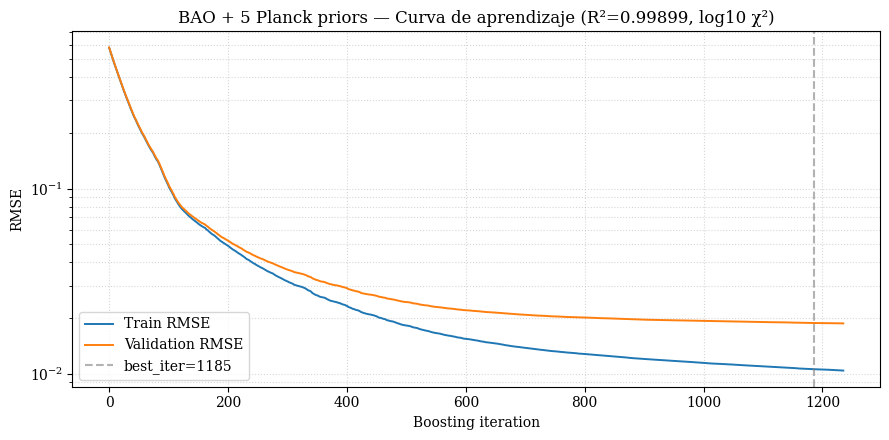

In [65]:
plot_learning_curve(
    info,
    title=f"BAO + 5 Planck priors — Curva de aprendizaje (R²={info['r2']:.5f}, log10 χ²)",
    save_path=None,
    show=True,
)

--- $w_0$ vs $\Omega_m$  ({'wa': -0.28878429977073555, 'H0': 67.47593535694638, 'rd': 147.10260157597767}) ---
  computing theory (parallel)...


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_Om_w0.png


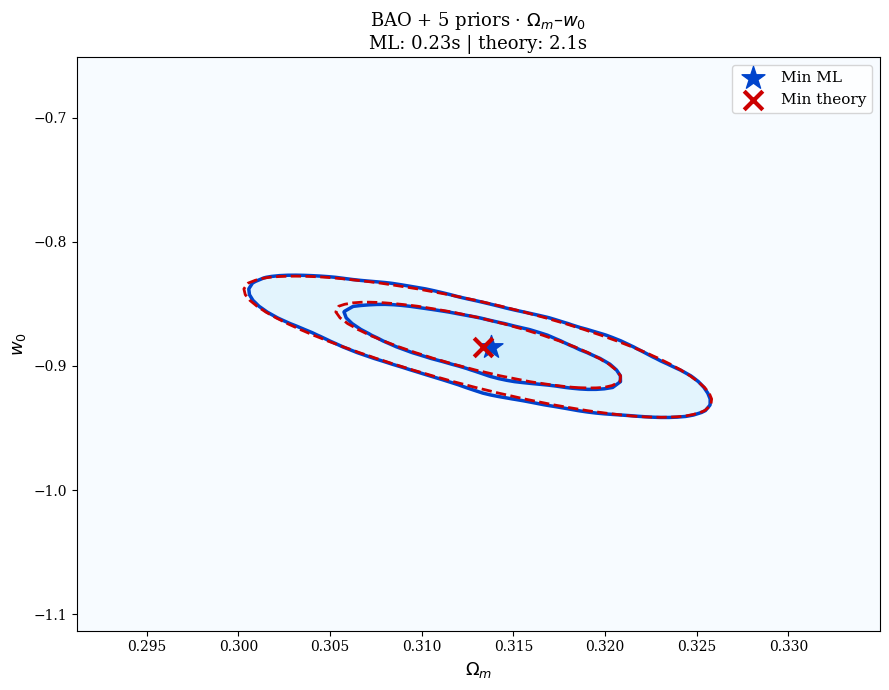

--- $w_a$ vs $\Omega_m$  ({'w0': -0.8823175279480643, 'H0': 67.47593535694638, 'rd': 147.10260157597767}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_Om_wa.png


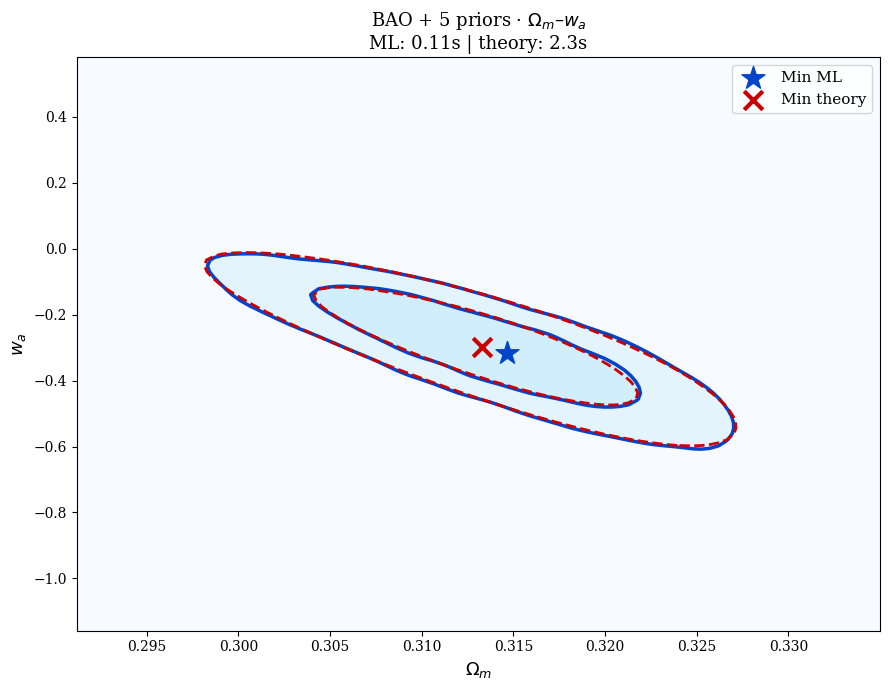

--- $H_0$ vs $\Omega_m$  ({'w0': -0.8823175279480643, 'wa': -0.28878429977073555, 'rd': 147.10260157597767}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_Om_H0.png


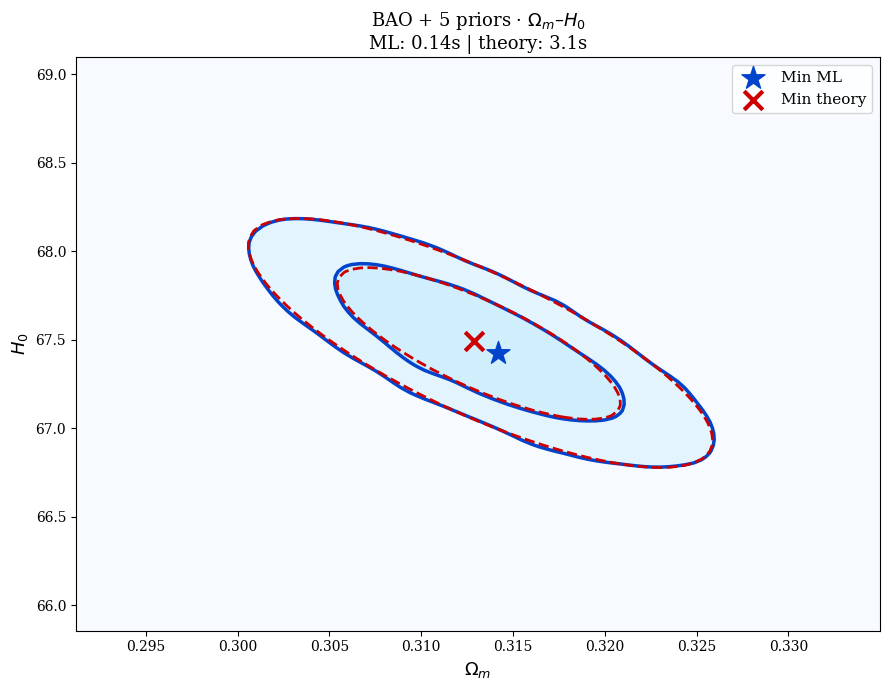

--- $r_d$ vs $\Omega_m$  ({'w0': -0.8823175279480643, 'wa': -0.28878429977073555, 'H0': 67.47593535694638}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_Om_rd.png


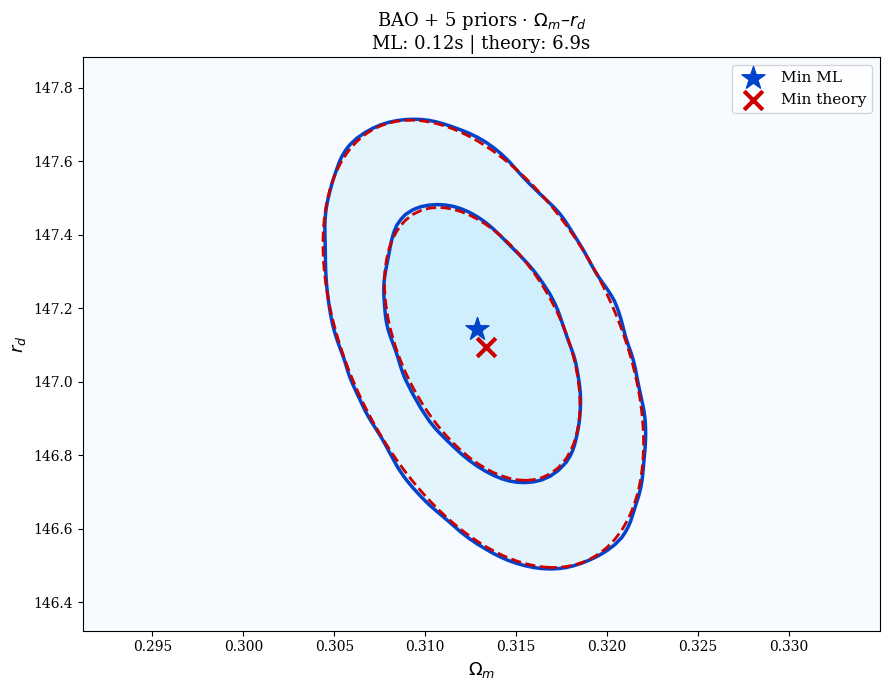

--- $w_a$ vs $w_0$  ({'Om': 0.3130922383444303, 'H0': 67.47593535694638, 'rd': 147.10260157597767}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_w0_wa.png


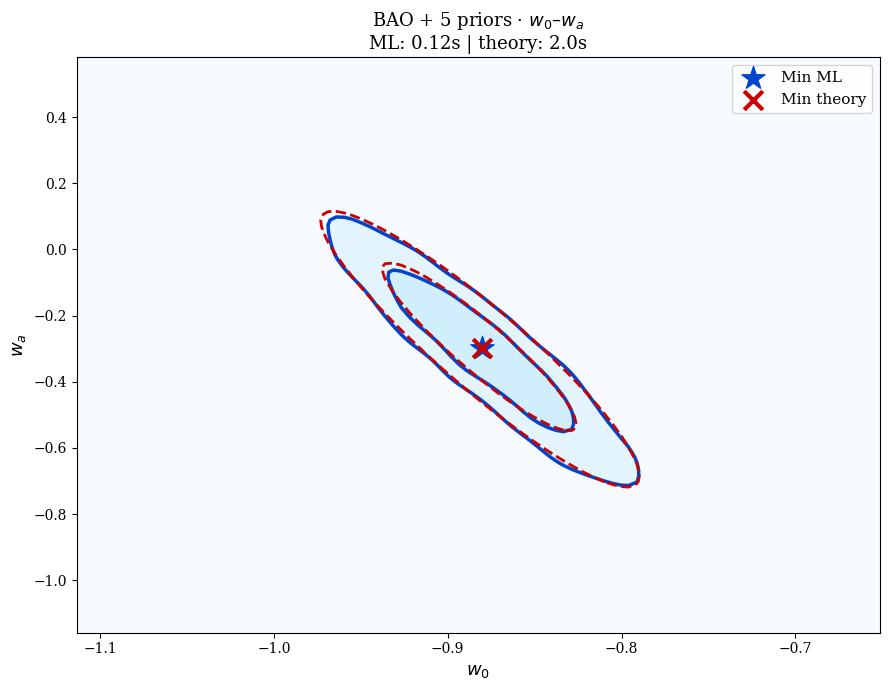

--- $H_0$ vs $w_0$  ({'Om': 0.3130922383444303, 'wa': -0.28878429977073555, 'rd': 147.10260157597767}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_w0_H0.png


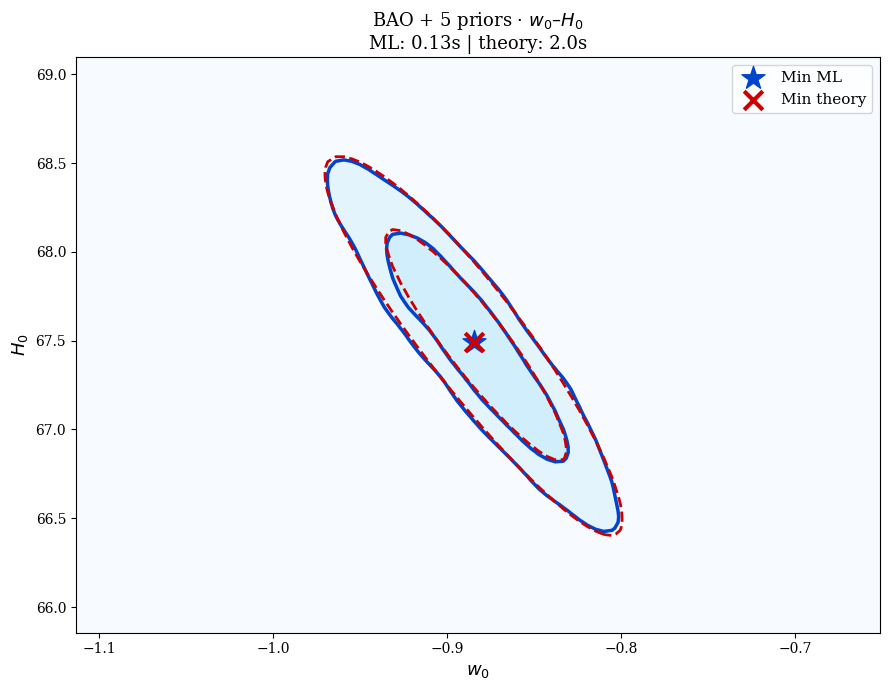

--- $r_d$ vs $w_0$  ({'Om': 0.3130922383444303, 'wa': -0.28878429977073555, 'H0': 67.47593535694638}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_w0_rd.png


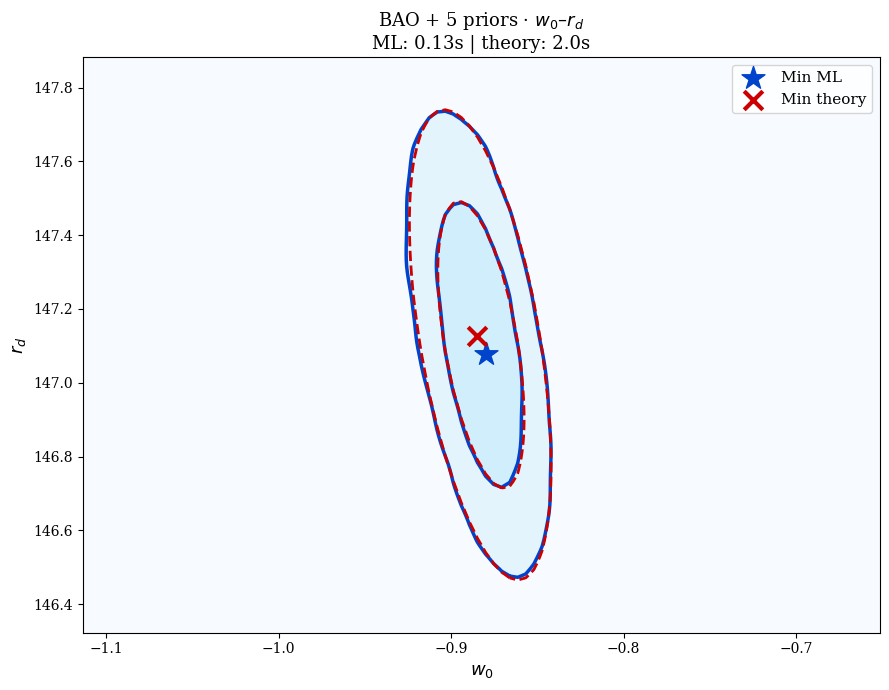

--- $H_0$ vs $w_a$  ({'Om': 0.3130922383444303, 'w0': -0.8823175279480643, 'rd': 147.10260157597767}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_wa_H0.png


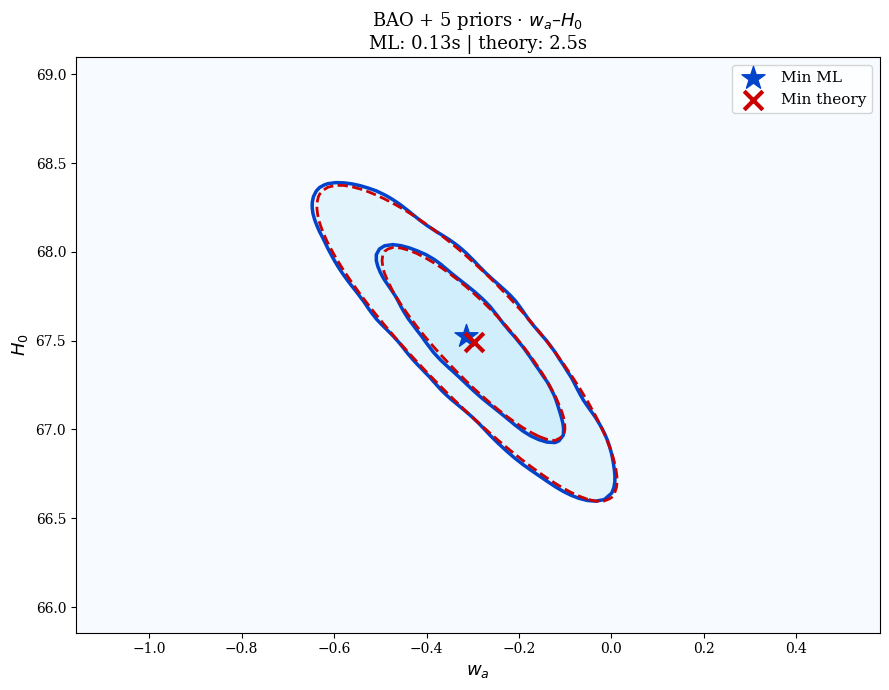

--- $r_d$ vs $w_a$  ({'Om': 0.3130922383444303, 'w0': -0.8823175279480643, 'H0': 67.47593535694638}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_wa_rd.png


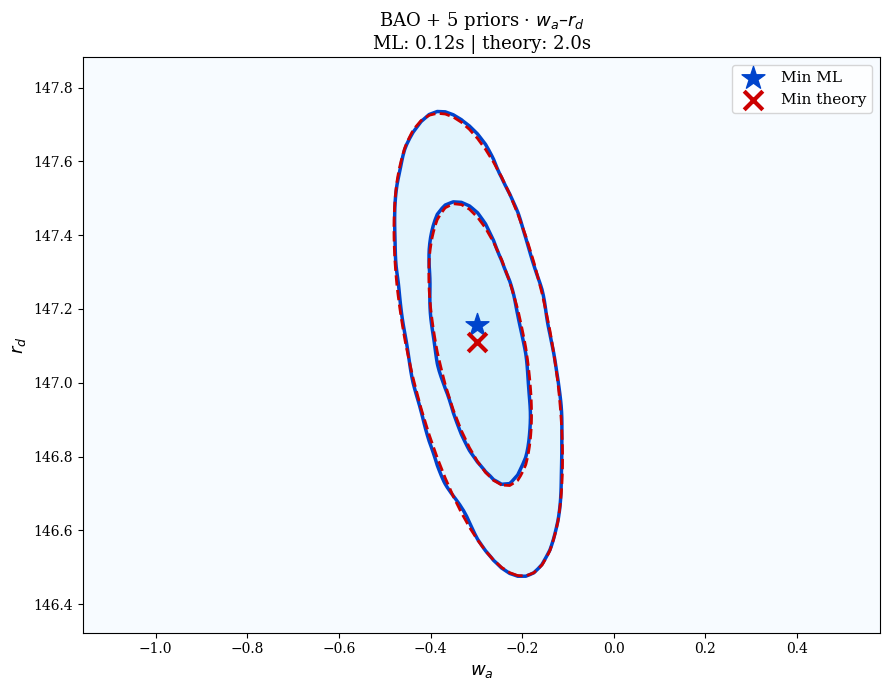

--- $r_d$ vs $H_0$  ({'Om': 0.3130922383444303, 'w0': -0.8823175279480643, 'wa': -0.28878429977073555}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_H0_rd.png


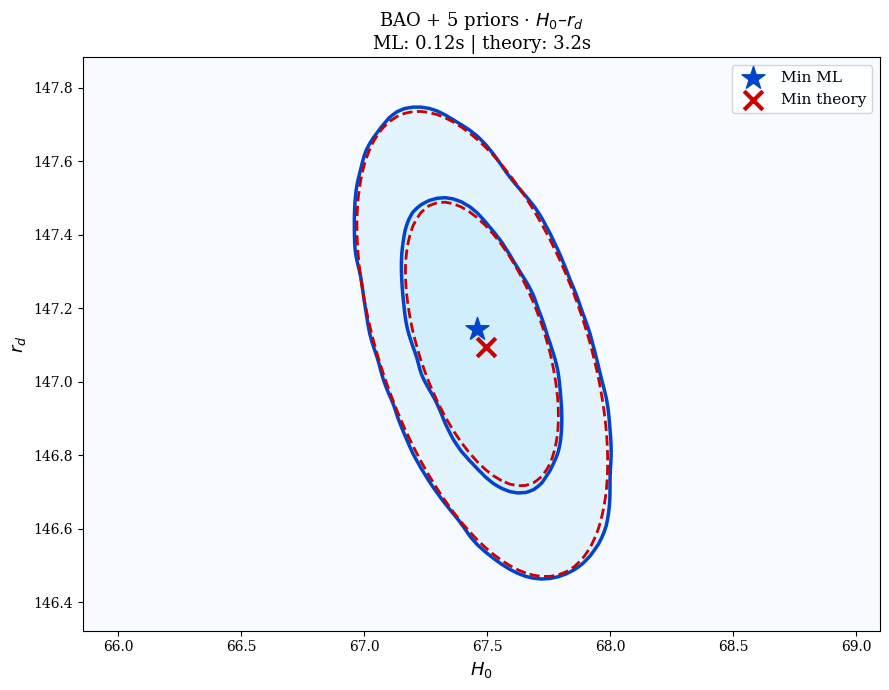

In [66]:
common = dict(res=100, sigma=2.0, theory_threshold=30)
SIGMAS = dict(Om=0.0073, w0=0.077, wa=0.29, H0=0.54, rd=0.26)
RANGES = {k: (REF[k] - 3*SIGMAS[k], REF[k] + 3*SIGMAS[k]) for k in FEATURES}
LABELS = dict(Om=r"$\Omega_m$", w0=r"$w_0$", wa=r"$w_a$", H0=r"$H_0$", rd=r"$r_d$")

for x, y in [("Om","w0"), ("Om","wa"), ("Om","H0"), ("Om","rd"),
             ("w0","wa"), ("w0","H0"), ("w0","rd"),
             ("wa","H0"), ("wa","rd"), ("H0","rd")]:
    fixed = {k: REF[k] for k in FEATURES if k not in (x, y)}
    plot_contour_2d(
        model, features=FEATURES,
        x_param=x, y_param=y,
        x_range=RANGES[x], y_range=RANGES[y],
        fixed=fixed, theory_fn=chi2_fn,
        title=fr"BAO + 5 priors · {LABELS[x]}–{LABELS[y]}",
        x_label=LABELS[x], y_label=LABELS[y],
        save_path=None,
        show=True, **common,
        global_min_chi2=res_opt.fun,
    )

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_shap_beeswarm.png


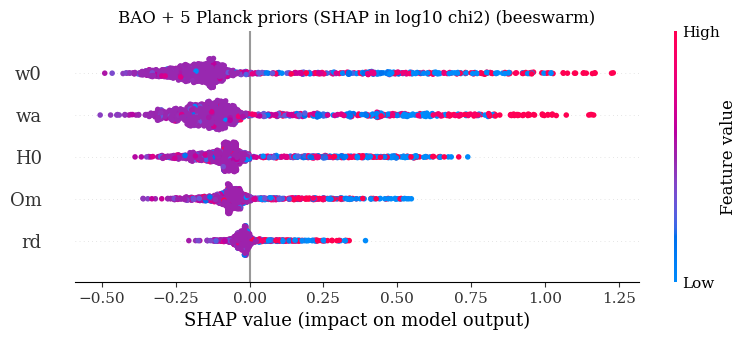

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_shap_bar.png


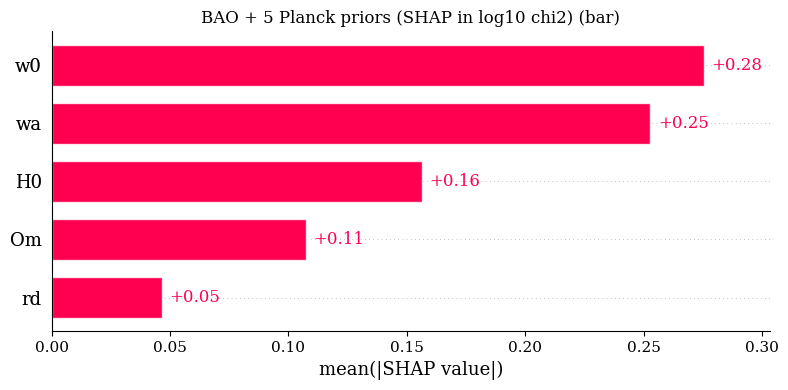

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_shap_waterfall.png


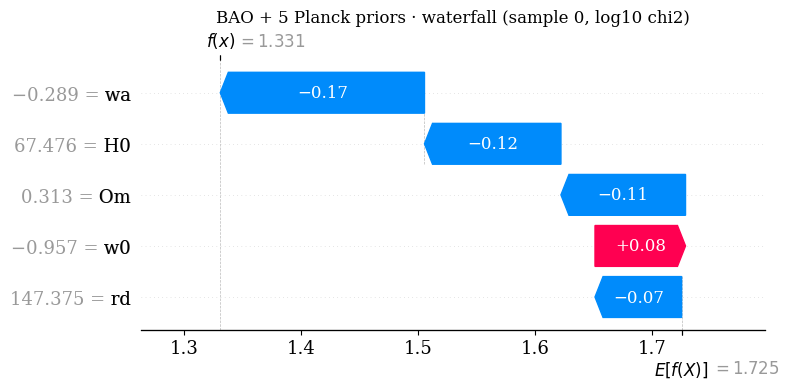

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_shap_Om.png


<Figure size 640x480 with 0 Axes>

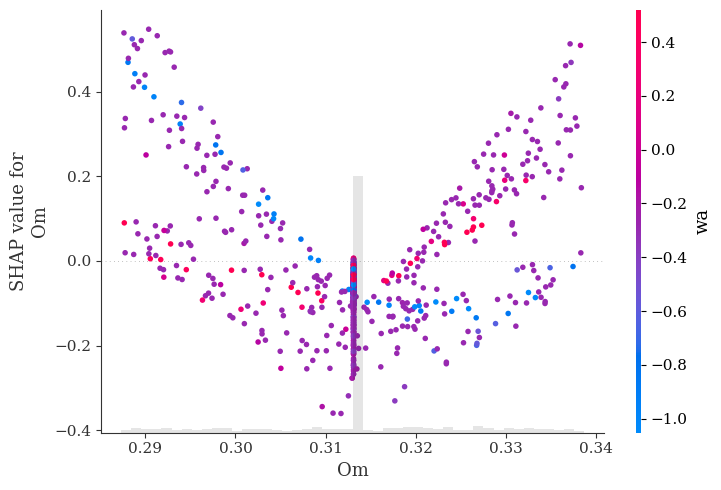

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_shap_w0.png


<Figure size 640x480 with 0 Axes>

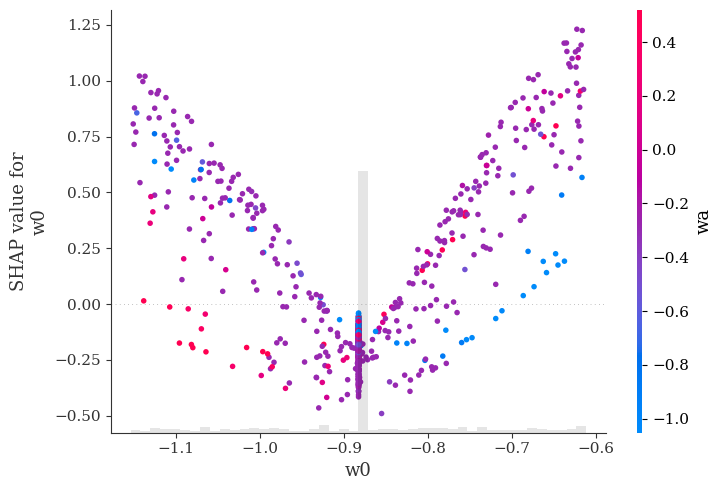

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_shap_wa.png


<Figure size 640x480 with 0 Axes>

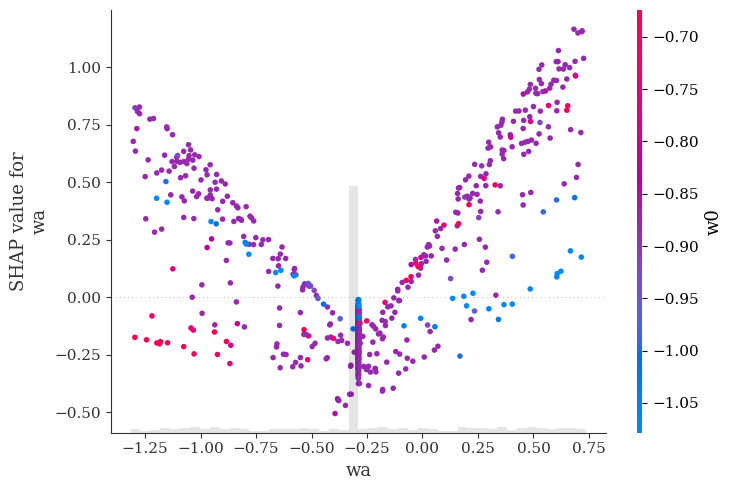

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_shap_H0.png


<Figure size 640x480 with 0 Axes>

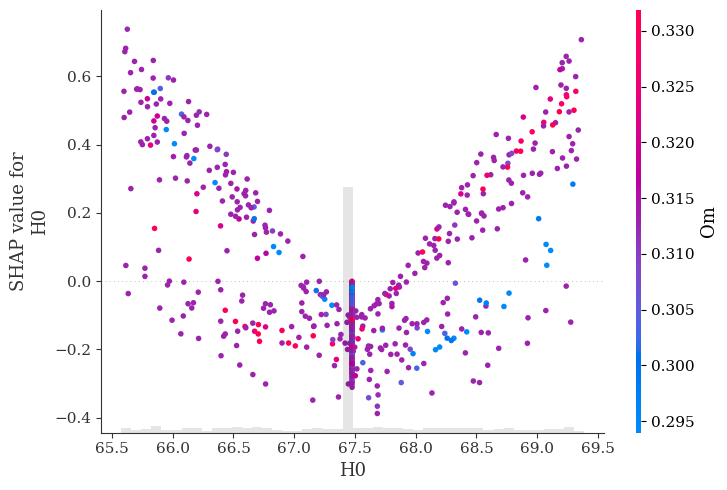

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_shap_rd.png


<Figure size 640x480 with 0 Axes>

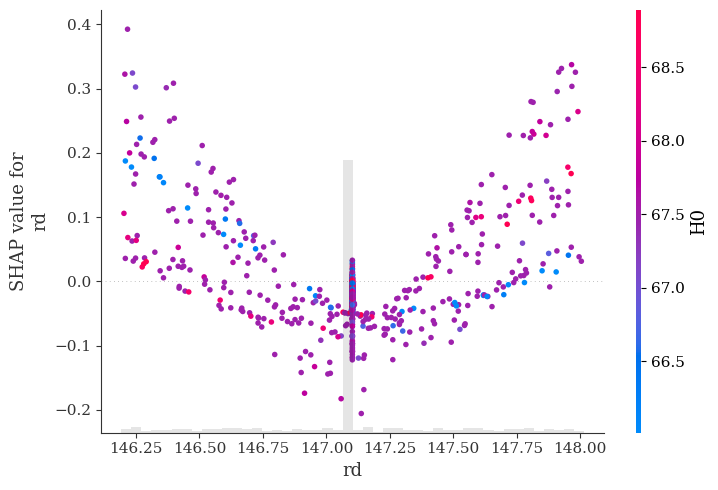

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_shap_w0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_shap_wa.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_shap_H0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_shap_rd.png')]

In [67]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=None, prefix=SECTION,
    title="BAO + 5 Planck priors (SHAP in log10 chi2)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=None,
    title="BAO + 5 Planck priors · waterfall (sample 0, log10 chi2)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=None, prefix=SECTION,
    show=True,
)

--- corner marginal: 512 chains × 5000 steps (burn-in 400, ndim=5) ---
  loading CPU booster copy...
  step   200/5000  |  61 it/s  |  ETA 79s  |  acc 0.33  |  diagonal
  step   400/5000  |  66 it/s  |  ETA 69s  |  acc 0.31  |  multivar
  step   600/5000  |  69 it/s  |  ETA ≤5s  |  acc 0.26  |  τ=55.1  ESS=1857/5000  |  multivar
  step   800/5000  |  63 it/s  |  ETA ≤9s  |  acc 0.23  |  τ=99.8  ESS=2053/5000  |  multivar
  step  1000/5000  |  51 it/s  |  ETA ≤11s  |  acc 0.21  |  τ=121.0  ESS=2539/5000  |  multivar
  step  1200/5000  |  53 it/s  |  ETA ≤18s  |  acc 0.20  |  τ=177.0  ESS=2314/5000  |  multivar
  step  1400/5000  |  55 it/s  |  ETA ≤20s  |  acc 0.20  |  τ=215.9  ESS=2372/5000  |  multivar
  step  1600/5000  |  57 it/s  |  ETA ≤24s  |  acc 0.19  |  τ=259.6  ESS=2366/5000  |  multivar
  step  1800/5000  |  57 it/s  |  ETA ≤18s  |  acc 0.18  |  τ=247.4  ESS=2898/5000  |  multivar
  step  2000/5000  |  57 it/s  |  ETA ≤25s  |  acc 0.18  |  τ=309.2  ESS=2649/5000  |  multivar

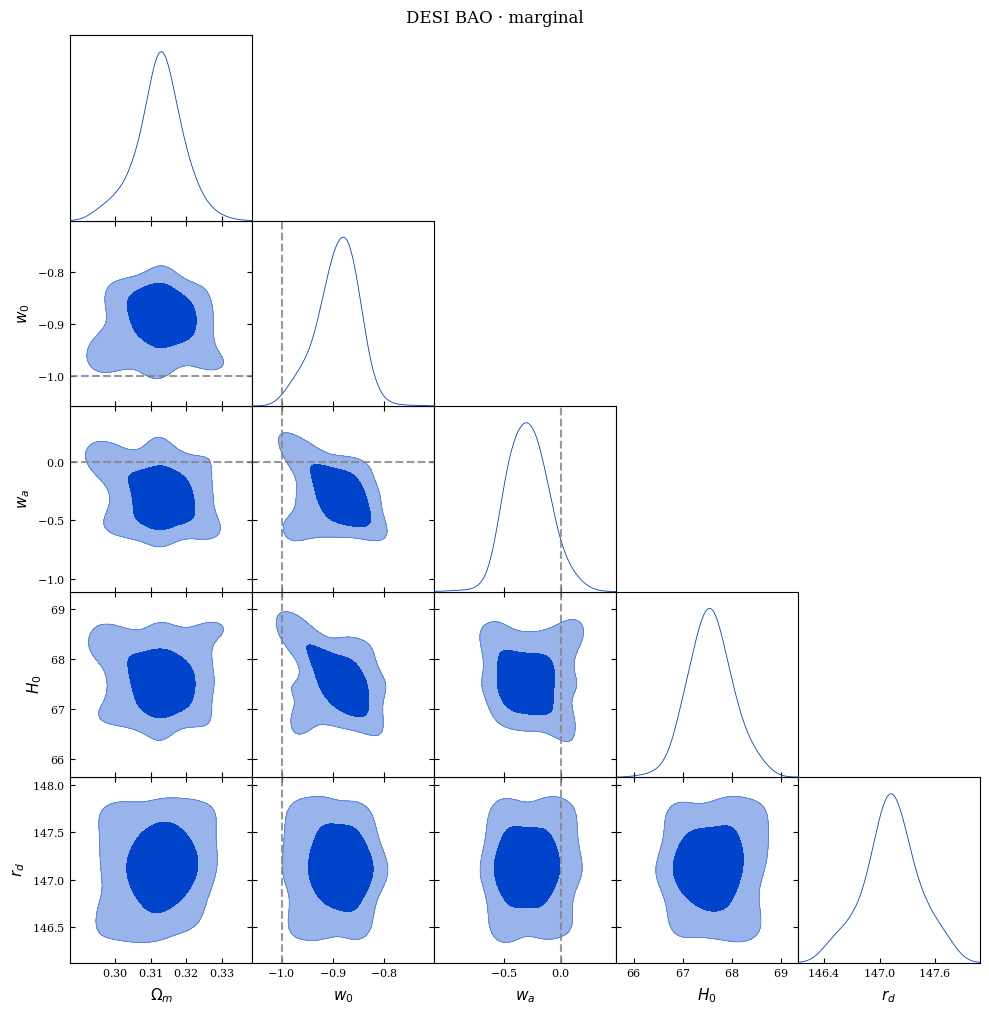

array([[  0.31027269,  -0.86610556,  -0.28486836,  67.92819214,
        147.10752869],
       [  0.30637863,  -0.86001337,  -0.14802139,  67.83666992,
        147.70732117],
       [  0.31863096,  -0.88552749,  -0.34857488,  67.5189743 ,
        147.2150116 ],
       ...,
       [  0.3132225 ,  -0.89198446,  -0.24404669,  67.46968079,
        146.87664795],
       [  0.31285977,  -0.81941146,  -0.63977289,  68.28109741,
        147.15524292],
       [  0.31322399,  -0.88142759,  -0.39153785,  67.58836365,
        146.91923523]], shape=(1434112, 5))

In [68]:
# --- Marginalised corner plot (MCMC posterior via XGBoost surrogate) ---
from cosmoml.ml import plot_corner_marginal
plot_corner_marginal(
    model, features=FEATURES, ranges=RANGES,
    labels=LABELS, ref=REF,
    markers={k: v for k, v in {'w0': -1.0, 'wa': 0.0}.items() if k in FEATURES},
    title="DESI BAO · marginal",
    save_path=None,
    show=True,
)